In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
khyeh0719_ptb_xl_dataset_path = kagglehub.dataset_download('khyeh0719/ptb-xl-dataset')
erarayamorenzomuten_chapmanshaoxing_12lead_ecg_database_path = kagglehub.dataset_download('erarayamorenzomuten/chapmanshaoxing-12lead-ecg-database')
marufhs_cpsc_2020_path = kagglehub.dataset_download('marufhs/cpsc-2020')

print('Data source import complete.')


Install + Imports + Seed

In [ ]:
import os, ast, random, time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix, classification_report

SEED = 42
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ DEVICE:", DEVICE)
print("✅ pandas:", pd.__version__)
print("✅ torch:", torch.__version__)


✅ DEVICE: cuda
✅ pandas: 2.2.2
✅ torch: 2.8.0+cu126


In [ ]:
def read_ptbxl_record(record_base_path):
    """
    record_base_path = full path WITHOUT extension
    example: /kaggle/input/<ptbxl>/records500/00000/00001_hr

    Returns:
      sig: (12, n_samples) float32
      fs: int
      sig_names: list[str]
    """
    hea_path = record_base_path + ".hea"
    if not os.path.exists(hea_path):
        raise FileNotFoundError(f"Missing header: {hea_path}")

    with open(hea_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    first = lines[0].split()
    nsig = int(first[1])
    fs = int(float(first[2]))
    n_samples = int(first[3])

    sig_lines = lines[1:1+nsig]
    dat_file = sig_lines[0].split()[0]
    dat_path = os.path.join(os.path.dirname(hea_path), dat_file)

    sig_names = [ln.split()[-1] for ln in sig_lines]

    raw = np.fromfile(dat_path, dtype="<i2", count=nsig*n_samples)
    if raw.size != nsig*n_samples:
        # handle mismatch safely
        n_samples = raw.size // nsig
        raw = raw[:nsig*n_samples]

    sig = raw.reshape(n_samples, nsig).T.astype(np.float32)  # (12, T)
    return sig, fs, sig_names


Cell 2 — Paths + Config

Purpose: Point to PTB-XL folder + set key hyperparameters.

In [ ]:
BASE_DIR = "/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"

DB_CSV  = os.path.join(BASE_DIR, "ptbxl_database.csv")
SCP_CSV = os.path.join(BASE_DIR, "scp_statements.csv")

USE_HR = True
SIG_LEN = 5000

BATCH_SIZE = 32
NUM_WORKERS = 2
EPOCHS = 30
LR = 2e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 6
MAX_GRAD_NORM = 1.0

LAMBDA_AF = 0.5  # loss balance between AF head and multiclass head

SUPERCLASSES = ["NORM","MI","CD","HYP","STTC"]
CLS2IDX = {c:i for i,c in enumerate(SUPERCLASSES)}
IDX2CLS = {i:c for c,i in CLS2IDX.items()}

USE_BALANCED_SAMPLER = True  # helps "variety" per batch


Cell 3 — CHECKPOINT: Verify dataset files exist

Purpose: Ensure Kaggle dataset is mounted correctly.

In [ ]:
print("BASE_DIR exists:", os.path.exists(BASE_DIR))
if os.path.exists(BASE_DIR):
    print("BASE_DIR list (first 30):")
    print(sorted(os.listdir(BASE_DIR))[:30])

print("DB_CSV exists:", os.path.exists(DB_CSV))
print("SCP_CSV exists:", os.path.exists(SCP_CSV))
print("records500 exists:", os.path.exists(os.path.join(BASE_DIR, "records500")))


BASE_DIR exists: True
BASE_DIR list (first 30):
['LICENSE.txt', 'RECORDS', 'SHA256SUMS.txt', 'example_physionet.py', 'ptbxl_database.csv', 'records100', 'records500', 'scp_statements.csv']
DB_CSV exists: True
SCP_CSV exists: True
records500 exists: True


In [ ]:
df = pd.read_csv(DB_CSV)
print("df shape:", df.shape)
display(df.head())


df shape: (21837, 28)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


Cell 5 — Parse scp_codes dict + CHECKPOINT

Purpose: Convert scp_codes string → python dict.

In [ ]:
def parse_scp_dict(x):
    try:
        return ast.literal_eval(x)
    except:
        return {}

print("Example raw scp_codes:\n", df.loc[0, "scp_codes"])
print("\nParsed example:\n", parse_scp_dict(df.loc[0, "scp_codes"]))

df["scp_dict"] = df["scp_codes"].apply(parse_scp_dict)


Example raw scp_codes:
 {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}

Parsed example:
 {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


Cell 6 — Create AF label + Superclass label (5-class)

Purpose:

AF head = AFIB exists

5-class head from scp_statements.csv diagnostic_class mapping

In [ ]:
# AFIB label
df["y_afib"] = df["scp_dict"].apply(lambda d: int("AFIB" in d))

# mapping for diagnostic superclass
scp = pd.read_csv(SCP_CSV, index_col=0)
diag_scp = scp[scp["diagnostic"] == 1]
code2super = diag_scp["diagnostic_class"].to_dict()

def compute_superclass(scp_dict):
    scores = {c: 0.0 for c in SUPERCLASSES}
    for code, w in scp_dict.items():
        sup = code2super.get(code, None)
        if sup in scores:
            scores[sup] += float(w)
    best = max(scores, key=scores.get)
    return None if scores[best] == 0.0 else best

df["superclass"] = df["scp_dict"].apply(compute_superclass)

print("AFIB count (raw):", int(df["y_afib"].sum()))
print("\nSuperclass counts (raw, incl NaN):")
print(df["superclass"].value_counts(dropna=False).head(20))


AFIB count (raw): 1514

Superclass counts (raw, incl NaN):
superclass
NORM    9257
MI      4089
CD      3758
STTC    3039
HYP     1274
None     420
Name: count, dtype: int64


Cell 7 — Filter to 5 superclasses + CHECKPOINT .head()

Purpose: Keep only rows that match your 5-class setup.

In [ ]:
df = df[df["superclass"].notna()].reset_index(drop=True)
df["y_super"] = df["superclass"].map(CLS2IDX).astype(int)

print("Filtered df shape:", df.shape)
print("AFIB count (filtered):", int(df["y_afib"].sum()))
print(df["superclass"].value_counts())

display(df[["ecg_id","superclass","y_super","y_afib","strat_fold"]].head())


Filtered df shape: (21417, 32)
AFIB count (filtered): 1448
superclass
NORM    9257
MI      4089
CD      3758
STTC    3039
HYP     1274
Name: count, dtype: int64


,ecg_id,superclass,y_super,y_afib,strat_fold
0,1,NORM,0,0,3
1,2,NORM,0,0,2
2,3,NORM,0,0,5
3,4,NORM,0,0,3
4,5,NORM,0,0,4


Cell 8 — Split using strat_fold + CHECKPOINT sizes

Purpose: No leakage, PTB-XL standard split.

In [ ]:
train_df = df[df["strat_fold"].isin([1,2,3,4,5,6,7,8])].reset_index(drop=True)
val_df   = df[df["strat_fold"] == 9].reset_index(drop=True)
test_df  = df[df["strat_fold"] == 10].reset_index(drop=True)

print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))


Train/Val/Test: 17100 2155 2162


Cell 9 — CHECKPOINT: “Equal varieties of records” (class balance)

Purpose: Verify that your training set has variety across 5 classes and AFIB.

In [ ]:
def show_dist(name, dfx):
    print(f"\n===== {name} =====")

    # Multiclass distribution
    counts_mc = dfx["superclass"].value_counts().reindex(SUPERCLASSES).fillna(0).astype(int)
    pct_mc = (counts_mc / len(dfx) * 100).round(2)
    display(pd.DataFrame({"count": counts_mc, "pct%": pct_mc}))

    # AFIB distribution
    counts_af = dfx["y_afib"].value_counts().reindex([0,1]).fillna(0).astype(int)
    pct_af = (counts_af / len(dfx) * 100).round(2)
    out_af = pd.DataFrame({"count": counts_af, "pct%": pct_af})
    out_af.index = ["non_AFIB(0)", "AFIB(1)"]
    display(out_af)

show_dist("TRAIN", train_df)
show_dist("VAL", val_df)
show_dist("TEST", test_df)

# Imbalance ratio check (max/min)
counts = train_df["superclass"].value_counts().reindex(SUPERCLASSES).fillna(0).astype(int)
max_c = counts.max()
min_c = counts[counts>0].min()
ratio = max_c / min_c
print("Superclass counts:", counts.to_dict())
print(f"Imbalance ratio (max/min): {ratio:.2f}x")



===== TRAIN =====


,count,pct%
superclass,,
NORM,7395,43.25
MI,3283,19.20
CD,2982,17.44
HYP,1026,6.00
STTC,2414,14.12


,count,pct%
non_AFIB(0),15943,93.23
AFIB(1),1157,6.77



===== VAL =====


,count,pct%
superclass,,
NORM,930,43.16
MI,394,18.28
CD,393,18.24
HYP,123,5.71
STTC,315,14.62


,count,pct%
non_AFIB(0),2008,93.18
AFIB(1),147,6.82



===== TEST =====


,count,pct%
superclass,,
NORM,932,43.11
MI,412,19.06
CD,383,17.72
HYP,125,5.78
STTC,310,14.34


,count,pct%
non_AFIB(0),2018,93.34
AFIB(1),144,6.66


Superclass counts: {'NORM': 7395, 'MI': 3283, 'CD': 2982, 'HYP': 1026, 'STTC': 2414}
Imbalance ratio (max/min): 7.21x


counts = train_df["superclass"].value_counts().reindex(SUPERCLASSES).fillna(0).astype(int)
max_c = counts.max()
min_c = counts[counts>0].min()
ratio = max_c / min_c

print("Superclass counts:", counts.to_dict())
print(f"Imbalance ratio (max/min): {ratio:.2f}x")


In [ ]:
counts = train_df["superclass"].value_counts().reindex(SUPERCLASSES).fillna(0).astype(int)
max_c = counts.max()
min_c = counts[counts>0].min()
ratio = max_c / min_c

print("Superclass counts:", counts.to_dict())
print(f"Imbalance ratio (max/min): {ratio:.2f}x")


Superclass counts: {'NORM': 7395, 'MI': 3283, 'CD': 2982, 'HYP': 1026, 'STTC': 2414}
Imbalance ratio (max/min): 7.21x


In [ ]:
class ECGAugment:
    def __init__(self, noise_std=0.01, max_shift=250, mask_max_len=400):
        self.noise_std = noise_std
        self.max_shift = max_shift
        self.mask_max_len = mask_max_len

    def __call__(self, x):
        # x: (12, T)
        if random.random() < 0.7:
            x = x * random.uniform(0.9, 1.1)

        if random.random() < 0.7:
            x = x + torch.randn_like(x) * self.noise_std

        if random.random() < 0.5:
            shift = random.randint(-self.max_shift, self.max_shift)
            x = torch.roll(x, shifts=shift, dims=1)

        if random.random() < 0.3:
            for c in range(x.shape[0]):
                if random.random() < 0.15:
                    x[c] = 0.0

        if random.random() < 0.3:
            mlen = random.randint(50, self.mask_max_len)
            start = random.randint(0, max(0, x.shape[1] - mlen))
            x[:, start:start+mlen] = 0.0

        return x

train_aug = ECGAugment()
print("✅ train_aug ready")


✅ train_aug ready


In [ ]:


SIG_LEN = 5000  # or use your SIG_LEN variable

def zscore_per_lead(x, eps=1e-6):
    mean = x.mean(axis=1, keepdims=True)
    std  = x.std(axis=1, keepdims=True)
    return (x - mean) / (std + eps)

class PTBXLDataset(Dataset):
    def __init__(self, meta_df, base_dir, use_hr=True, augment=None, sig_len=SIG_LEN):
        self.df = meta_df.reset_index(drop=True)
        self.base_dir = base_dir
        self.path_col = "filename_hr" if use_hr else "filename_lr"
        self.augment = augment
        self.sig_len = sig_len

    def __len__(self):
        return len(self.df)

    def _read_ecg(self, rel_path):
        full_base = os.path.join(self.base_dir, rel_path)  # WITHOUT extension
        sig, fs, names = read_ptbxl_record(full_base)      # (12, T)

        # crop/pad
        if sig.shape[1] < self.sig_len:
            sig = np.pad(sig, ((0,0),(0,self.sig_len - sig.shape[1])), mode="constant")
        else:
            sig = sig[:, :self.sig_len]

        sig = zscore_per_lead(sig).astype(np.float32)
        return sig

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = self._read_ecg(row[self.path_col])

        y_af = np.float32(row["y_afib"])
        y_mc = np.int64(row["y_super"])

        x = torch.from_numpy(x)  # (12, sig_len)
        if self.augment is not None:
            x = self.augment(x)

        return x, torch.tensor(y_af), torch.tensor(y_mc)

print("✅ PTBXLDataset (wfdb-free) defined")


✅ PTBXLDataset (wfdb-free) defined


In [ ]:
train_ds = PTBXLDataset(train_df, BASE_DIR, use_hr=USE_HR, augment=train_aug, sig_len=SIG_LEN)
val_ds   = PTBXLDataset(val_df,   BASE_DIR, use_hr=USE_HR, augment=None,   sig_len=SIG_LEN)
test_ds  = PTBXLDataset(test_df,  BASE_DIR, use_hr=USE_HR, augment=None,   sig_len=SIG_LEN)

print("✅ train_ds:", len(train_ds))
print("✅ val_ds:", len(val_ds))
print("✅ test_ds:", len(test_ds))


✅ train_ds: 17100
✅ val_ds: 2155
✅ test_ds: 2162


In [ ]:
# Balanced sampler to fix class imbalance (~7x)
class_counts = train_df["y_super"].value_counts().sort_index()
class_weights = 1.0 / class_counts
sample_weights = train_df["y_super"].map(class_weights).values

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"), drop_last=True
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda")
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda")
)

print("✅ DataLoaders ready")

# Batch checkpoint
x, y_af, y_mc = next(iter(train_loader))
print("Batch x:", x.shape)
print("Batch class counts:", torch.bincount(y_mc, minlength=5))
print("Batch AF counts:", torch.bincount(y_af.long(), minlength=2))


✅ DataLoaders ready
Batch x: torch.Size([32, 12, 5000])
Batch class counts: tensor([9, 7, 4, 5, 7])
Batch AF counts: tensor([28,  4])


In [ ]:
AF_BOOST = 1.5     # try 1.2–1.8
MAX_W = 5.0        # clip to avoid tiny bucket explosion

pair_id = (2 * train_df["y_super"].values + train_df["y_afib"].values).astype(int)

pair_counts = np.bincount(pair_id, minlength=10).astype(np.float64)
pair_counts[pair_counts == 0] = 1.0

pair_weight = 1.0 / pair_counts
pair_weight = pair_weight / pair_weight.mean()

# mild AF boost (odd buckets are AF)
for c in range(5):
    pair_weight[2*c + 1] *= AF_BOOST

# IMPORTANT: cap weights
pair_weight = np.clip(pair_weight, 0.0, MAX_W)

sample_weights = pair_weight[pair_id]

print("Pair counts:", pair_counts.astype(int).tolist())
print("Pair weights (clipped):", np.round(pair_weight, 3).tolist())

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"), drop_last=True
)

print("✅ train_loader updated (soft AF + capped weights)")


Pair counts: [7367, 28, 2989, 294, 2721, 261, 925, 101, 1941, 473]
Pair weights (clipped): [0.024, 5.0, 0.058, 0.889, 0.064, 1.001, 0.188, 2.588, 0.09, 0.553]
✅ train_loader updated (soft AF + capped weights)


In [ ]:
def check_batches(loader, n=10):
    af_rates = []
    cls_sum = np.zeros(5, dtype=int)

    it = iter(loader)
    for i in range(n):
        x, y_af, y_mc = next(it)
        af = torch.bincount(y_af.long(), minlength=2).tolist()
        cls = torch.bincount(y_mc, minlength=5).tolist()
        af_rates.append(float(y_af.mean().item()))
        cls_sum += np.array(cls)

        print(f"Batch {i+1:02d} | AF [non,af]={af} | AF ratio={y_af.mean().item():.2f} | class={cls}")

    print("\nAvg AF ratio over", n, "batches:", round(float(np.mean(af_rates)), 3))
    print("Total class counts over", n, "batches:", cls_sum.tolist())

check_batches(train_loader, n=10)


Batch 01 | AF [non,af]=[14, 18] | AF ratio=0.56 | class=[3, 6, 10, 4, 9]
Batch 02 | AF [non,af]=[8, 24] | AF ratio=0.75 | class=[2, 6, 6, 10, 8]
Batch 03 | AF [non,af]=[12, 20] | AF ratio=0.62 | class=[7, 9, 5, 4, 7]
Batch 04 | AF [non,af]=[12, 20] | AF ratio=0.62 | class=[8, 4, 3, 9, 8]
Batch 05 | AF [non,af]=[16, 16] | AF ratio=0.50 | class=[6, 3, 9, 7, 7]
Batch 06 | AF [non,af]=[12, 20] | AF ratio=0.62 | class=[4, 5, 6, 7, 10]
Batch 07 | AF [non,af]=[16, 16] | AF ratio=0.50 | class=[1, 4, 7, 13, 7]
Batch 08 | AF [non,af]=[11, 21] | AF ratio=0.66 | class=[4, 11, 3, 7, 7]
Batch 09 | AF [non,af]=[17, 15] | AF ratio=0.47 | class=[5, 7, 6, 7, 7]
Batch 10 | AF [non,af]=[17, 15] | AF ratio=0.47 | class=[2, 7, 7, 8, 8]

Avg AF ratio over 10 batches: 0.578
Total class counts over 10 batches: [42, 62, 62, 76, 78]


In [ ]:
pos_weight = torch.tensor([1.0], device=DEVICE)



In [ ]:
def check_batches(loader, n=10):
    af_rates = []
    cls_sum = np.zeros(5, dtype=int)

    it = iter(loader)
    for i in range(n):
        x, y_af, y_mc = next(it)
        af = torch.bincount(y_af.long(), minlength=2).tolist()
        cls = torch.bincount(y_mc, minlength=5).tolist()
        af_rates.append(float(y_af.mean().item()))
        cls_sum += np.array(cls)

        print(f"Batch {i+1:02d} | AF [non,af]={af} | AF ratio={y_af.mean().item():.2f} | class={cls}")

    print("\nAvg AF ratio over", n, "batches:", round(float(np.mean(af_rates)), 3))
    print("Total class counts over", n, "batches:", cls_sum.tolist())

check_batches(train_loader, n=10)


Batch 01 | AF [non,af]=[13, 19] | AF ratio=0.59 | class=[6, 3, 9, 9, 5]
Batch 02 | AF [non,af]=[12, 20] | AF ratio=0.62 | class=[3, 8, 5, 10, 6]
Batch 03 | AF [non,af]=[14, 18] | AF ratio=0.56 | class=[4, 4, 8, 9, 7]
Batch 04 | AF [non,af]=[14, 18] | AF ratio=0.56 | class=[0, 7, 11, 3, 11]
Batch 05 | AF [non,af]=[11, 21] | AF ratio=0.66 | class=[5, 8, 10, 3, 6]
Batch 06 | AF [non,af]=[15, 17] | AF ratio=0.53 | class=[3, 4, 11, 4, 10]
Batch 07 | AF [non,af]=[19, 13] | AF ratio=0.41 | class=[4, 15, 7, 3, 3]
Batch 08 | AF [non,af]=[11, 21] | AF ratio=0.66 | class=[6, 3, 3, 8, 12]
Batch 09 | AF [non,af]=[13, 19] | AF ratio=0.59 | class=[3, 6, 9, 8, 6]
Batch 10 | AF [non,af]=[17, 15] | AF ratio=0.47 | class=[7, 2, 11, 4, 8]

Avg AF ratio over 10 batches: 0.566
Total class counts over 10 batches: [41, 60, 84, 61, 74]


Loss setup (multiclass weights + AF loss)

Purpose: handle imbalance correctly with your sampler.

In [ ]:
# Multiclass class weights (still useful even with sampler)
mc_counts = train_df["y_super"].value_counts().sort_index().values
mc_w = (mc_counts.sum() / (mc_counts + 1e-6))
mc_w = mc_w / mc_w.mean()
mc_w_t = torch.tensor(mc_w, dtype=torch.float32, device=DEVICE)

# AF loss: since you're oversampling AF already, keep pos_weight = 1
pos_weight = torch.tensor([1.0], dtype=torch.float32, device=DEVICE)

bce_af = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
ce_mc  = nn.CrossEntropyLoss(weight=mc_w_t, label_smoothing=0.08)

print("✅ mc_w:", mc_w)
print("✅ pos_weight:", pos_weight.item())


✅ mc_w: [0.3124341  0.70376185 0.77479885 2.25190074 0.95710446]
✅ pos_weight: 1.0


Model (CNN + BiLSTM) two-head

Purpose: shared backbone + two outputs.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k, s, p, drop=0.15):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, k, s, p, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)
        self.act = nn.GELU()
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        return self.drop(self.act(self.bn(self.conv(x))))

class ECGMultiTaskNet(nn.Module):
    def __init__(self, in_leads=12, num_classes=5, lstm_hidden=128, lstm_layers=2, dropout=0.4):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(in_leads, 64, 9, 2, 4),
            ConvBlock(64, 64, 7, 1, 3),
            nn.MaxPool1d(2),

            ConvBlock(64, 128, 7, 2, 3),
            ConvBlock(128, 128, 5, 1, 2),
            nn.MaxPool1d(2),

            ConvBlock(128, 192, 5, 2, 2),
            ConvBlock(192, 192, 3, 1, 1),
        )

        self.lstm = nn.LSTM(
            input_size=192,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
            bidirectional=True
        )

        self.shared_drop = nn.Dropout(dropout)

        self.af_head = nn.Sequential(
            nn.Linear(2*lstm_hidden, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
        self.mc_head = nn.Sequential(
            nn.Linear(2*lstm_hidden, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)       # (B,C,T')
        x = x.transpose(1, 2) # (B,T',C)
        out, _ = self.lstm(x) # (B,T',2H)
        feat = out.mean(dim=1)
        feat = self.shared_drop(feat)
        return self.af_head(feat).squeeze(-1), self.mc_head(feat)

model = ECGMultiTaskNet().to(DEVICE)
print("✅ model ready")


✅ model ready


Optimizer + Scheduler + AMP

Purpose: stable training, less overfit

In [ ]:
import torch, triton
print("torch :", torch.__version__)
print("triton:", triton.__version__)

torch : 2.8.0+cu126
triton: 3.4.0


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))



In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    af_logits_all, af_y_all = [], []
    mc_logits_all, mc_y_all = [], []

    for x, y_af, y_mc in loader:
        x = x.to(DEVICE, non_blocking=True)
        y_af = y_af.to(DEVICE, non_blocking=True)
        y_mc = y_mc.to(DEVICE, non_blocking=True)

        af_logit, mc_logit = model(x)
        af_logits_all.append(af_logit.cpu())
        af_y_all.append(y_af.cpu())
        mc_logits_all.append(mc_logit.cpu())
        mc_y_all.append(y_mc.cpu())

    af_logits = torch.cat(af_logits_all).numpy()
    af_y = torch.cat(af_y_all).numpy()
    mc_logits = torch.cat(mc_logits_all).numpy()
    mc_y = torch.cat(mc_y_all).numpy()

    # AF
    af_prob = 1/(1+np.exp(-af_logits))
    af_pred = (af_prob >= 0.5).astype(int)
    try:
        af_auc = roc_auc_score(af_y, af_prob)
    except:
        af_auc = np.nan
    af_f1 = f1_score(af_y, af_pred, zero_division=0)

    # Multiclass
    mc_pred = mc_logits.argmax(axis=1)
    mc_acc = accuracy_score(mc_y, mc_pred)
    mc_f1  = f1_score(mc_y, mc_pred, average="macro", zero_division=0)

    combined = 0.5 * (0 if np.isnan(af_auc) else af_auc) + 0.5 * mc_f1
    return {"af_auc":af_auc, "af_f1":af_f1, "mc_acc":mc_acc, "mc_f1_macro":mc_f1, "combined":combined}

def train_one_epoch(model, loader):
    model.train()
    total = 0.0

    for x, y_af, y_mc in loader:
        x = x.to(DEVICE, non_blocking=True)
        y_af = y_af.to(DEVICE, non_blocking=True)
        y_mc = y_mc.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):
            af_logit, mc_logit = model(x)
            loss_af = bce_af(af_logit, y_af)
            loss_mc = ce_mc(mc_logit, y_mc)
            loss = LAMBDA_AF * loss_af + (1 - LAMBDA_AF) * loss_mc

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()

        total += loss.item() * x.size(0)

    return total / len(loader.dataset)

best_score = -1e9
best_path = "best_multitask_ptbxl.pt"
bad = 0

for epoch in range(1, EPOCHS+1):
    t0 = time.time()

    tr_loss = train_one_epoch(model, train_loader)
    val_m = evaluate(model, val_loader)
    scheduler.step(val_m["combined"])

    print(f"Epoch {epoch:02d} | loss {tr_loss:.4f} | "
          f"AF AUC {val_m['af_auc']:.4f} F1 {val_m['af_f1']:.4f} | "
          f"MC Acc {val_m['mc_acc']:.4f} MacroF1 {val_m['mc_f1_macro']:.4f} | "
          f"Comb {val_m['combined']:.4f} | {time.time()-t0:.1f}s")

    if val_m["combined"] > best_score + 1e-4:
        best_score = val_m["combined"]
        torch.save(model.state_dict(), best_path)
        bad = 0
        print("✅ Saved best:", best_path)
    else:
        bad += 1
        if bad >= PATIENCE:
            print("Early stopping.")
            break

print("✅ Training done. Best model:", best_path)


/tmp/ipykernel_57/632919186.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):


Epoch 01 | loss 0.7368 | AF AUC 0.9829 F1 0.8047 | MC Acc 0.2190 MacroF1 0.2067 | Comb 0.5948 | 128.7s
✅ Saved best: best_multitask_ptbxl.pt


/tmp/ipykernel_57/632919186.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):


Epoch 02 | loss 0.5842 | AF AUC 0.9844 F1 0.7812 | MC Acc 0.2854 MacroF1 0.3345 | Comb 0.6594 | 88.3s
✅ Saved best: best_multitask_ptbxl.pt


/tmp/ipykernel_57/632919186.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):


...

Epoch 13 | loss 0.3364 | AF AUC 0.9852 F1 0.8671 | MC Acc 0.4255 MacroF1 0.4554 | Comb 0.7203 | 56.8s


/tmp/ipykernel_57/632919186.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):


Epoch 14 | loss 0.3235 | AF AUC 0.9856 F1 0.8527 | MC Acc 0.4608 MacroF1 0.4761 | Comb 0.7308 | 56.6s


/tmp/ipykernel_57/632919186.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda")):


Epoch 15 | loss 0.3137 | AF AUC 0.9858 F1 0.8710 | MC Acc 0.4789 MacroF1 0.4848 | Comb 0.7353 | 56.5s
Early stopping.
✅ Training done. Best model: best_multitask_ptbxl.pt


test

In [ ]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
test_m = evaluate(model, test_loader)
print("TEST metrics:", test_m)

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    af_prob_all, af_y_all = [], []
    mc_pred_all, mc_y_all = [], []
    for x, y_af, y_mc in loader:
        x = x.to(DEVICE)
        af_logit, mc_logit = model(x)
        af_prob_all.append(torch.sigmoid(af_logit).cpu().numpy())
        af_y_all.append(y_af.numpy())
        mc_pred_all.append(mc_logit.argmax(dim=1).cpu().numpy())
        mc_y_all.append(y_mc.numpy())
    return (np.concatenate(af_prob_all), np.concatenate(af_y_all),
            np.concatenate(mc_pred_all), np.concatenate(mc_y_all))

af_prob, af_y, mc_pred, mc_y = predict_all(model, test_loader)

print("\nAFIB report (thr=0.5):")
af_pred = (af_prob >= 0.5).astype(int)
print(classification_report(af_y, af_pred, digits=4, zero_division=0))

print("\nMulticlass report:")
print(classification_report(mc_y, mc_pred, target_names=SUPERCLASSES, digits=4, zero_division=0))

print("\nConfusion matrix:")
print(confusion_matrix(mc_y, mc_pred))


TEST metrics: {'af_auc': np.float64(0.9717783008479243), 'af_f1': 0.7880597014925373, 'mc_acc': 0.48103607770582796, 'mc_f1_macro': 0.47389801477503035, 'combined': np.float64(0.7228381578114773)}

AFIB report (thr=0.5):
              precision    recall  f1-score   support

         0.0     0.9939    0.9708    0.9822      2018
         1.0     0.6911    0.9167    0.7881       144

    accuracy                         0.9672      2162
   macro avg     0.8425    0.9437    0.8851      2162
weighted avg     0.9737    0.9672    0.9693      2162


Multiclass report:
              precision    recall  f1-score   support

        NORM     0.8569    0.4624    0.6007       932
          MI     0.7647    0.4102    0.5340       412
          CD     0.6593    0.6214    0.6398       383
         HYP     0.1090    0.7360    0.1899       125
        STTC     0.4721    0.3548    0.4052       310

    accuracy                         0.4810      2162
   macro avg     0.5724    0.5170    0.4739      216

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ecg_12lead(sig, fs=500, title="12-lead ECG", seconds=10):
    T = min(sig.shape[1], int(seconds * fs))
    t = np.arange(T) / fs

    lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

    plt.figure(figsize=(16, 10))
    for i in range(12):
        plt.subplot(6, 2, i+1)
        plt.plot(t, sig[i, :T])
        plt.title(lead_names[i])
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.grid(True)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


✅ Selected AF record:
ecg_id: 16487 | superclass: STTC | y_afib: 1

✅ Selected Non-AF record:
ecg_id: 1263 | superclass: NORM | y_afib: 0


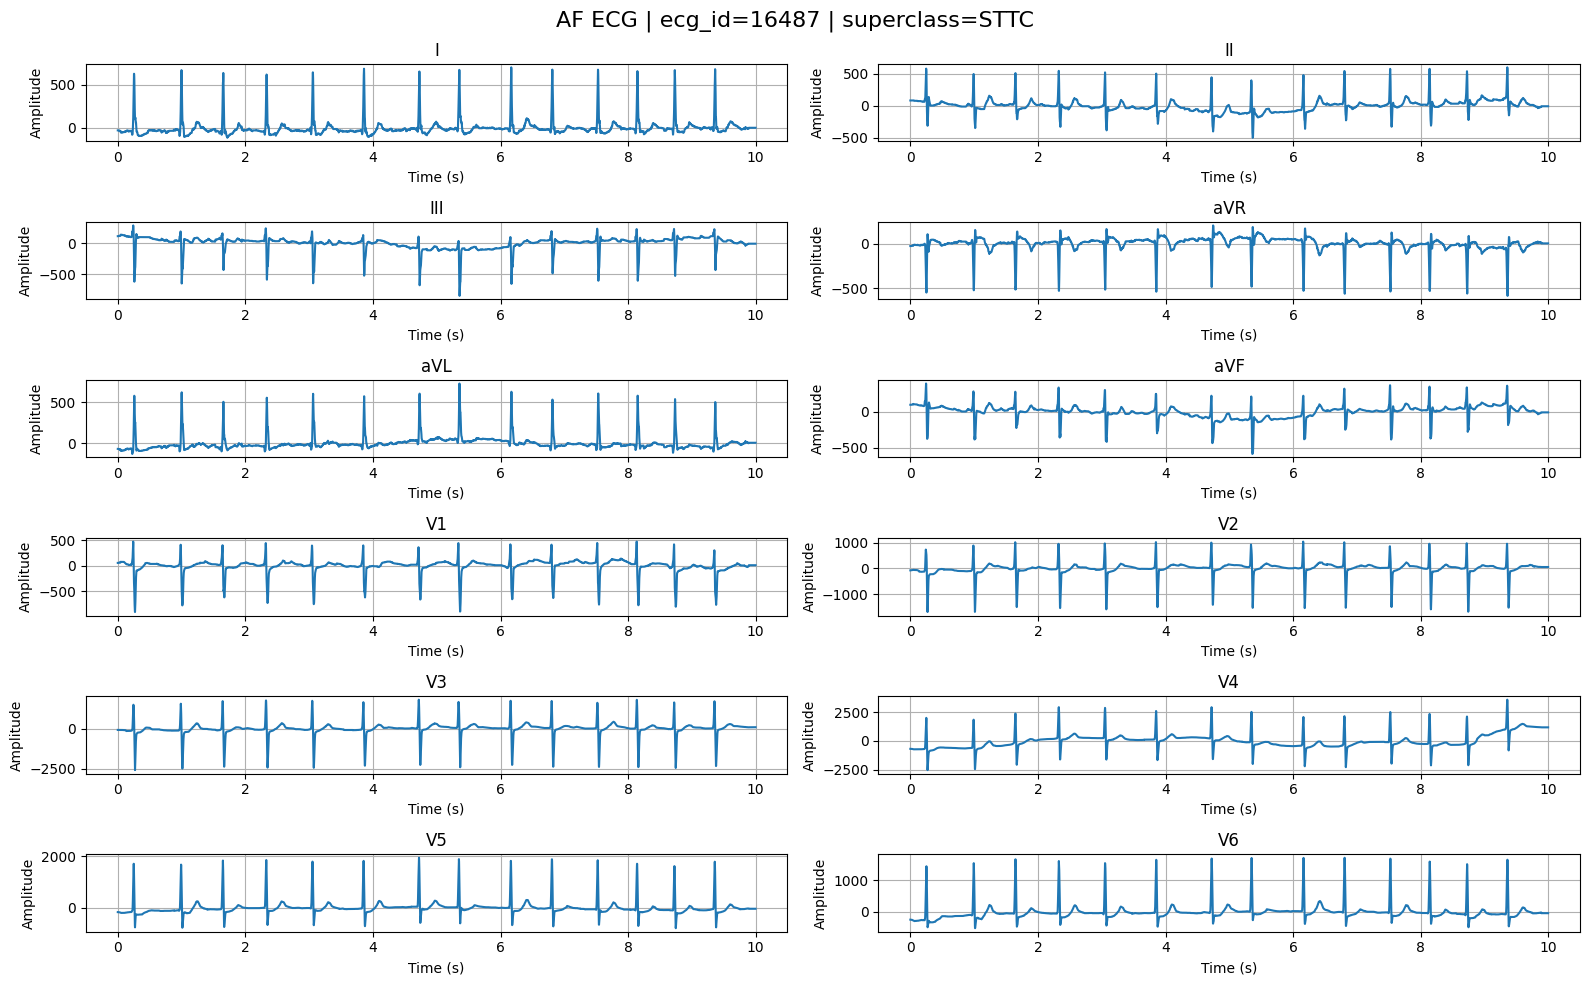

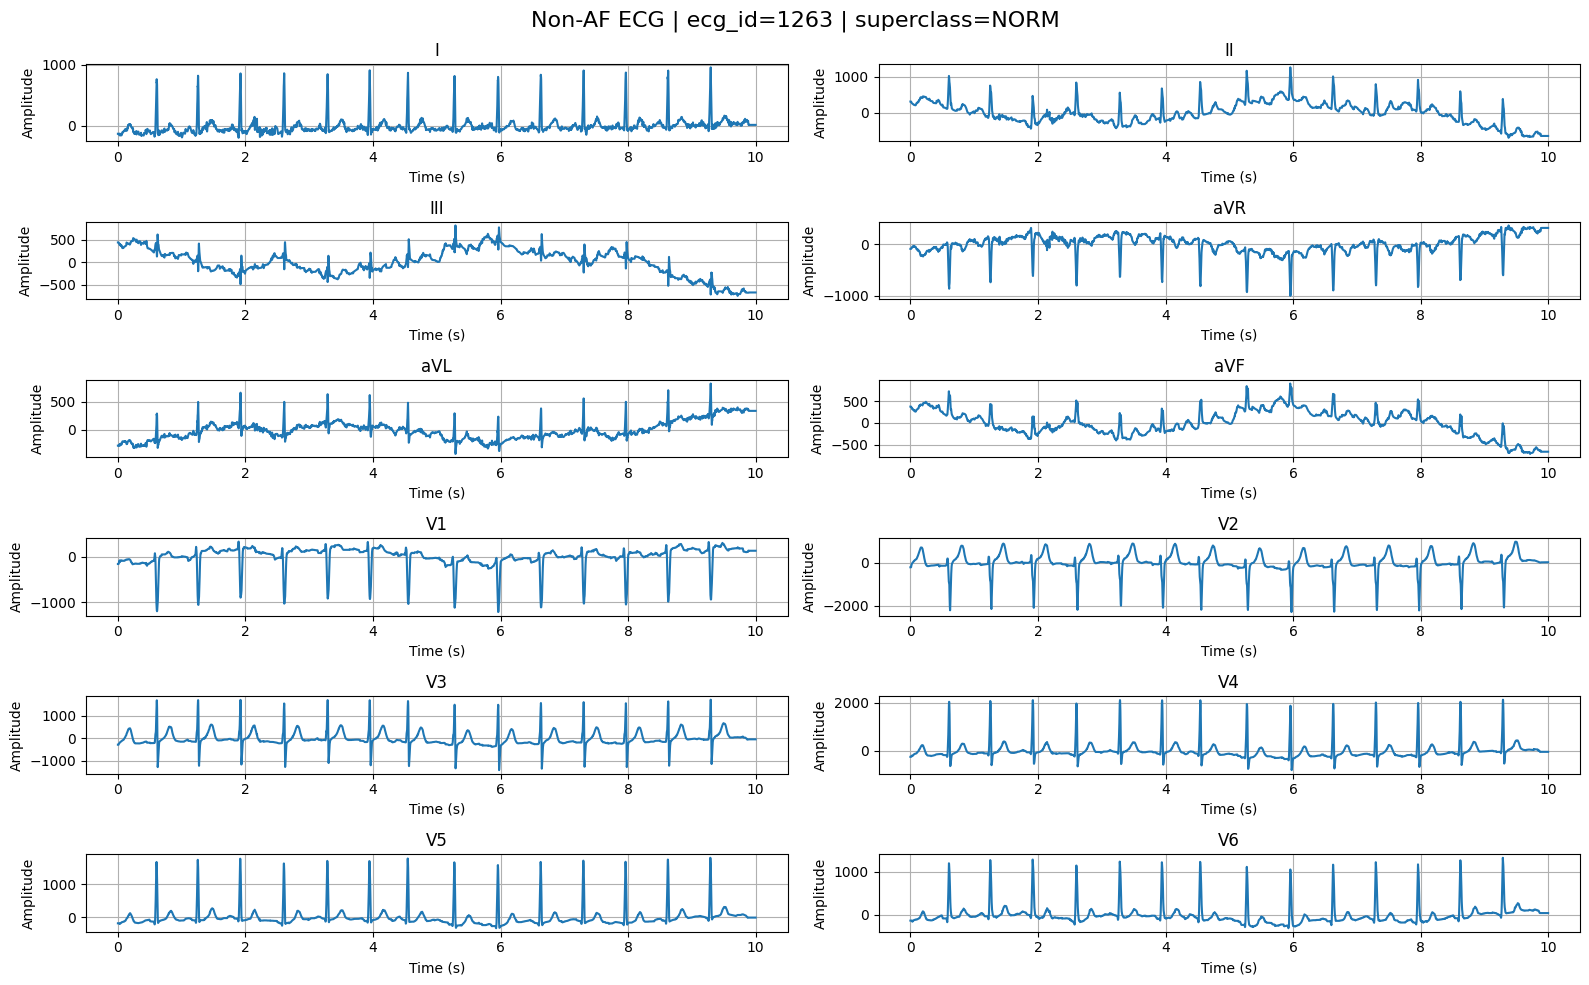

In [ ]:
# Make sure df already has y_afib column (0/1)
# and BASE_DIR + read_ptbxl_record() are defined

# pick one AF record and one Non-AF record
af_row = df[df["y_afib"] == 1].sample(1, random_state=42).iloc[0]
nonaf_row = df[df["y_afib"] == 0].sample(1, random_state=42).iloc[0]

print("✅ Selected AF record:")
print("ecg_id:", af_row["ecg_id"], "| superclass:", af_row["superclass"], "| y_afib:", af_row["y_afib"])

print("\n✅ Selected Non-AF record:")
print("ecg_id:", nonaf_row["ecg_id"], "| superclass:", nonaf_row["superclass"], "| y_afib:", nonaf_row["y_afib"])

# load ECG signals
af_path = os.path.join(BASE_DIR, af_row["filename_hr"])
nonaf_path = os.path.join(BASE_DIR, nonaf_row["filename_hr"])

sig_af, fs_af, names_af = read_ptbxl_record(af_path)
sig_nonaf, fs_nonaf, names_nonaf = read_ptbxl_record(nonaf_path)

# plot both
plot_ecg_12lead(sig_af, fs=fs_af, title=f"AF ECG | ecg_id={af_row['ecg_id']} | superclass={af_row['superclass']}")
plot_ecg_12lead(sig_nonaf, fs=fs_nonaf, title=f"Non-AF ECG | ecg_id={nonaf_row['ecg_id']} | superclass={nonaf_row['superclass']}")


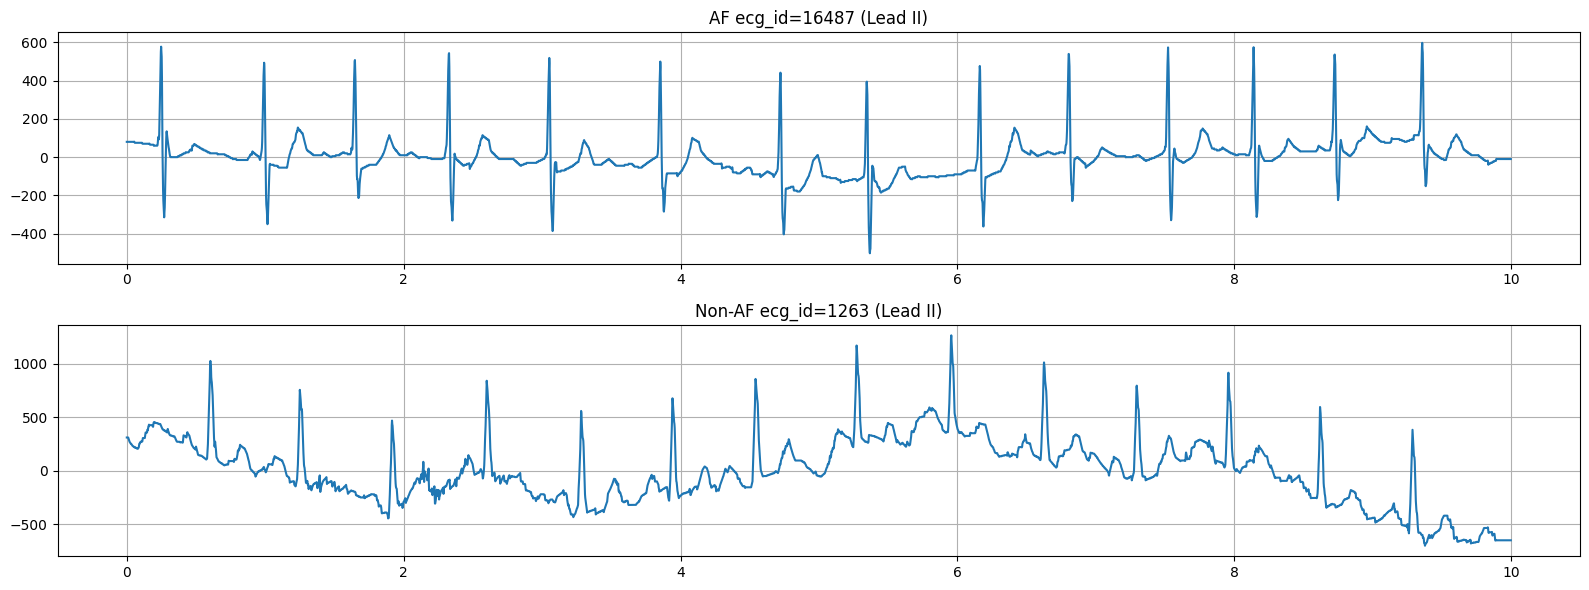

In [ ]:
def plot_lead_ii_compare(sig1, sig2, fs=500, seconds=10, title1="AF", title2="Non-AF"):
    T = min(sig1.shape[1], sig2.shape[1], int(seconds * fs))
    t = np.arange(T) / fs

    plt.figure(figsize=(16, 6))

    plt.subplot(2, 1, 1)
    plt.plot(t, sig1[1, :T])  # Lead II index = 1
    plt.title(f"{title1} (Lead II)")
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(t, sig2[1, :T])
    plt.title(f"{title2} (Lead II)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_lead_ii_compare(sig_af, sig_nonaf, fs=500,
                     title1=f"AF ecg_id={af_row['ecg_id']}",
                     title2=f"Non-AF ecg_id={nonaf_row['ecg_id']}")


✅ Loaded checkpoint: best_multitask_ptbxl.pt

✅ Selected AF record: ecg_id: 16487 | superclass: STTC | y_afib: 1
✅ Selected Non-AF record: ecg_id: 1263 | superclass: NORM | y_afib: 0

🔮 MODEL PREDICTIONS
AF sample:     AF_prob=0.9833 | MC_pred=STTC (p=0.823)
Non-AF sample: AF_prob=0.0000 | MC_pred=HYP (p=0.490)


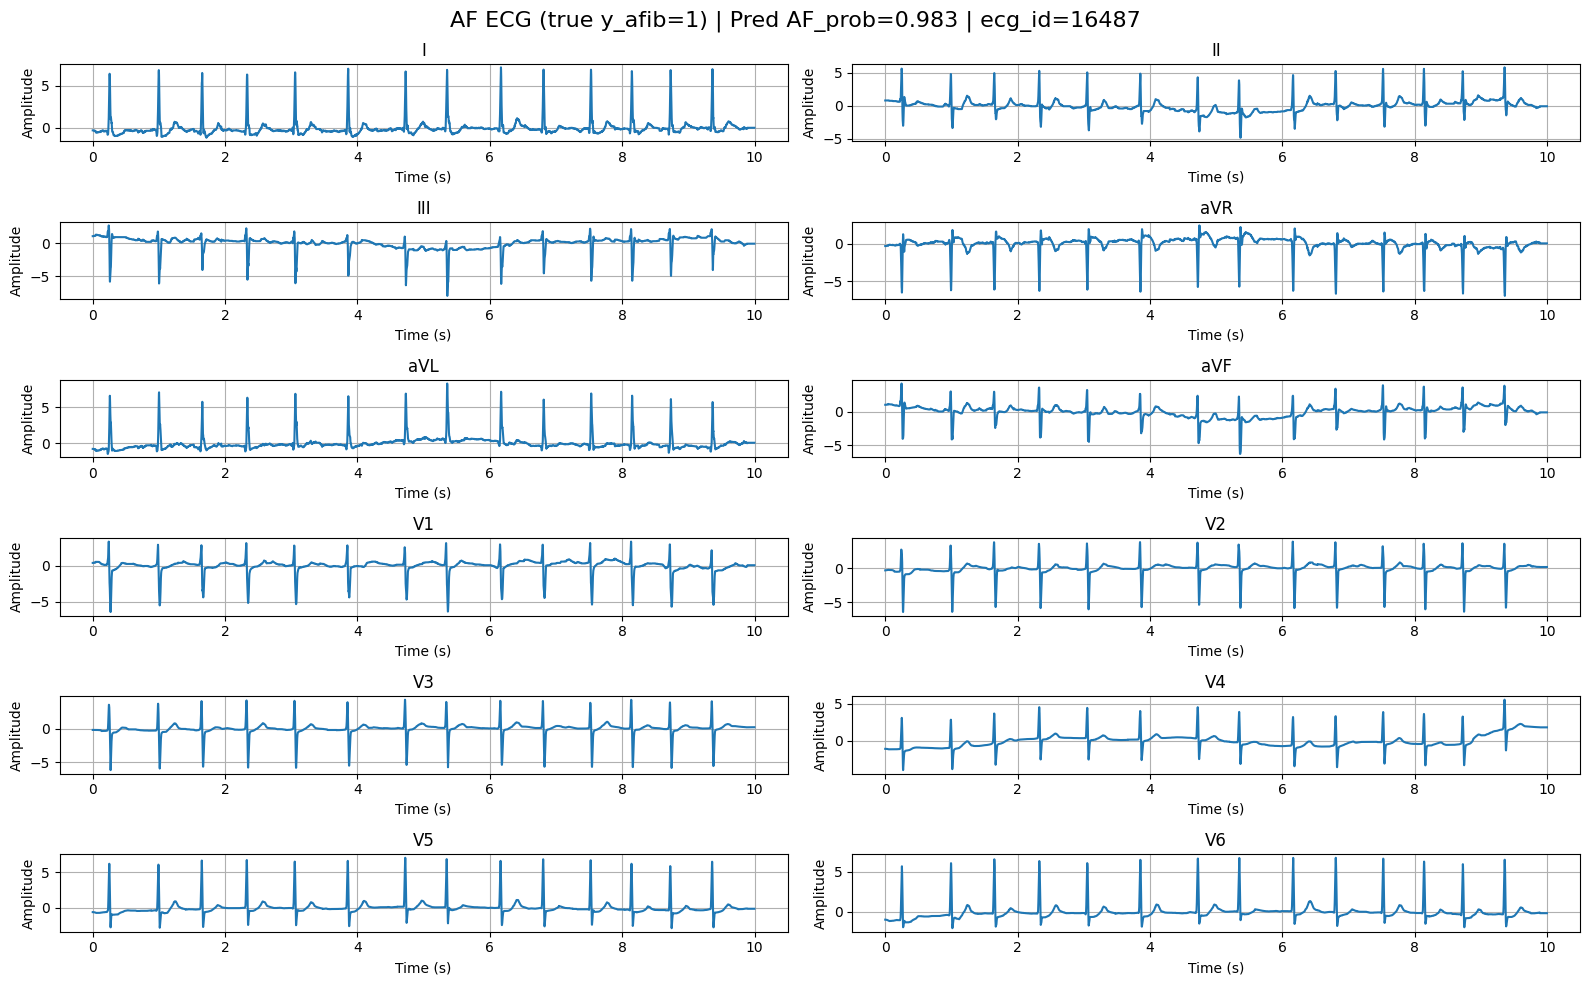

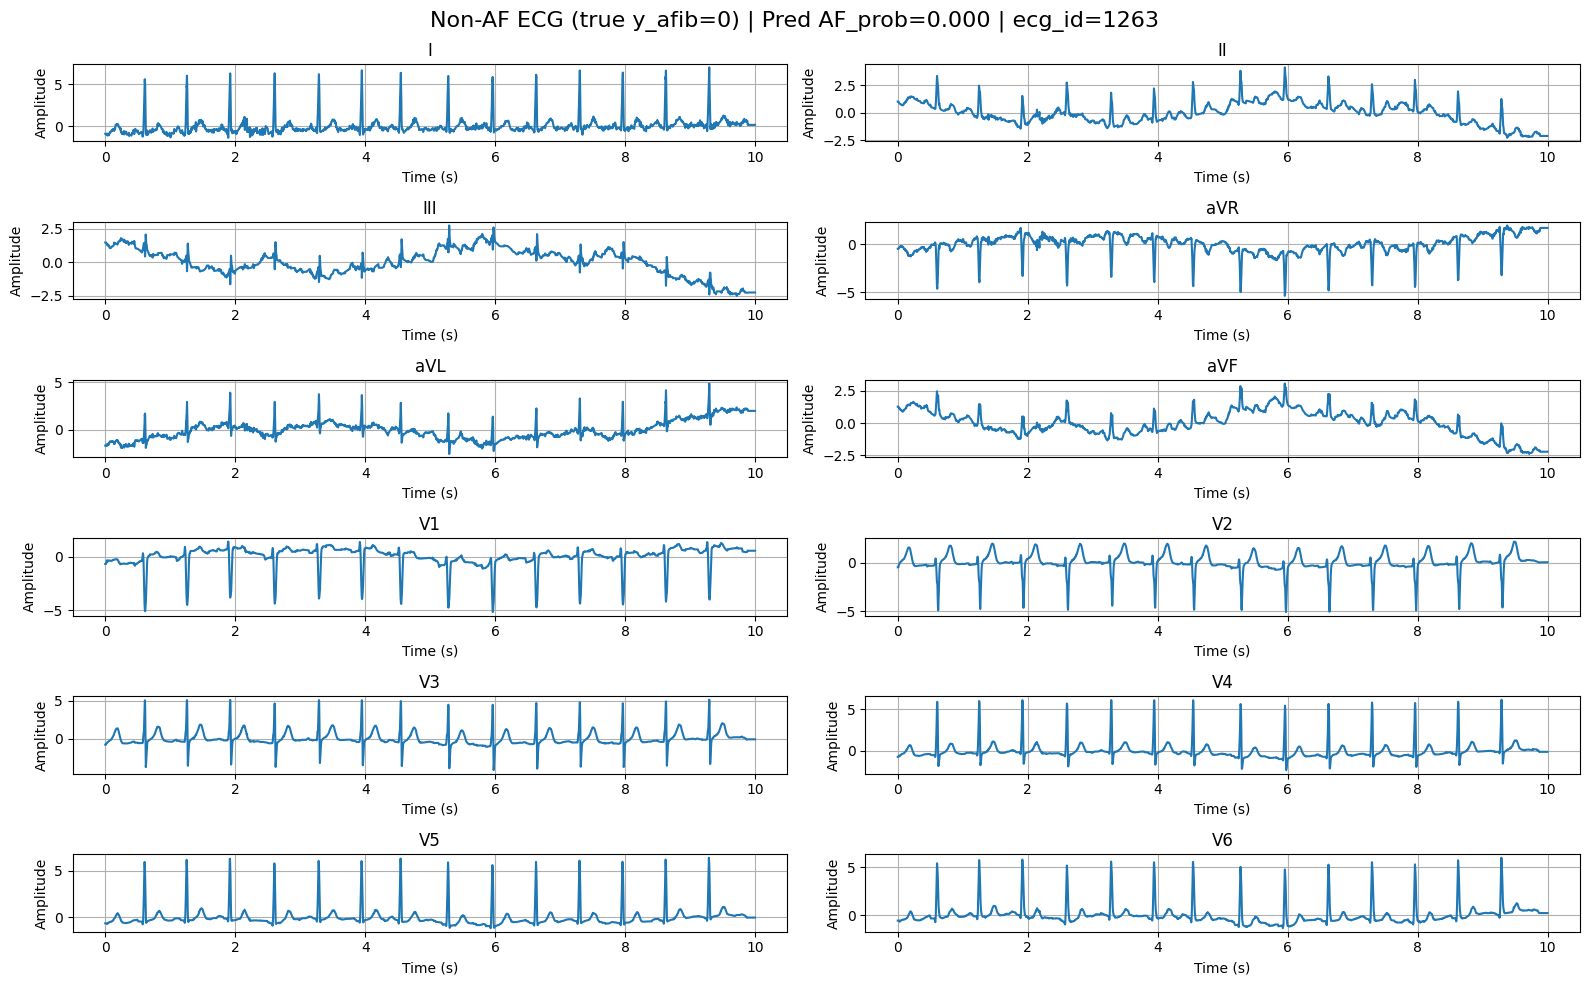

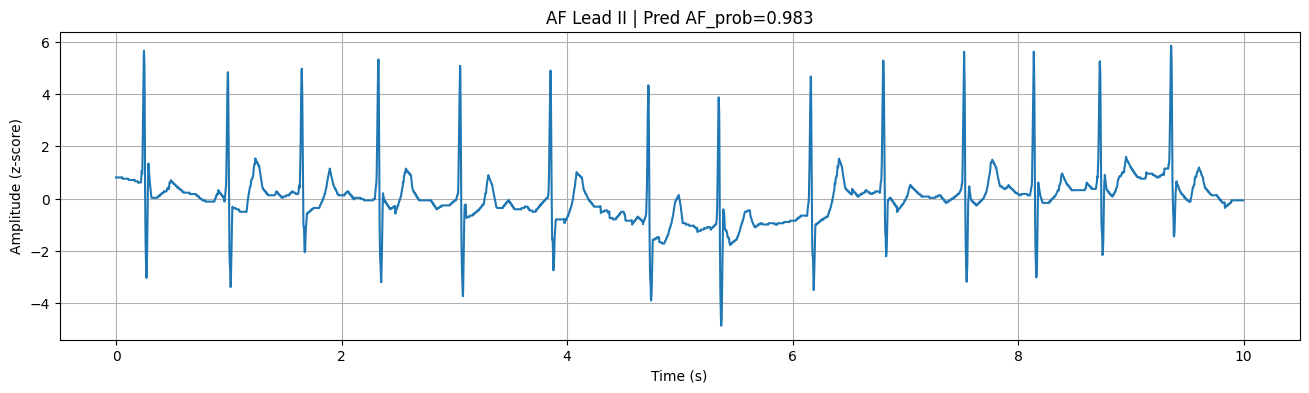

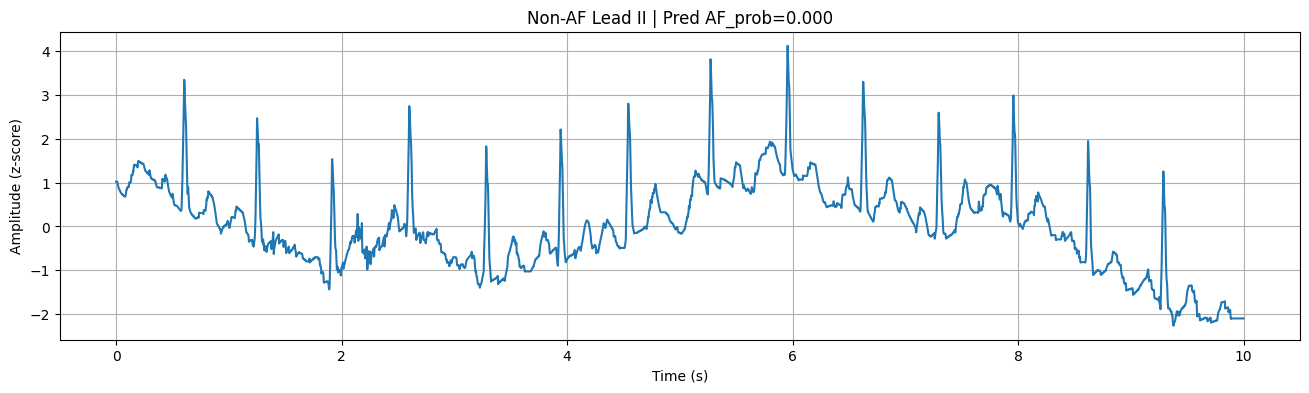

In [ ]:
# ============================================================
# AF vs Non-AF: show model predicted probability + plot ECG
# Requirements:
#   - best model checkpoint saved (best_multitask_ptbxl.pt)
#   - model class ECGMultiTaskNet already defined
#   - df has columns: y_afib, superclass, ecg_id, filename_hr
#   - BASE_DIR defined
#   - read_ptbxl_record() defined (wfdb-free loader)
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------- helpers ----------
def zscore_per_lead(x, eps=1e-6):
    mean = x.mean(axis=1, keepdims=True)
    std  = x.std(axis=1, keepdims=True)
    return (x - mean) / (std + eps)

def prepare_ecg_tensor(rel_path, sig_len=5000):
    record_base = os.path.join(BASE_DIR, rel_path)  # no extension
    sig, fs, names = read_ptbxl_record(record_base)  # (12, T)

    # crop/pad
    if sig.shape[1] < sig_len:
        sig = np.pad(sig, ((0,0),(0,sig_len - sig.shape[1])), mode="constant")
    else:
        sig = sig[:, :sig_len]

    sig = zscore_per_lead(sig).astype(np.float32)
    x = torch.from_numpy(sig).unsqueeze(0)  # (1,12,T)
    return x, fs, sig

def plot_ecg_12lead(sig, fs=500, title="12-lead ECG", seconds=10):
    T = min(sig.shape[1], int(seconds * fs))
    t = np.arange(T) / fs
    lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

    plt.figure(figsize=(16, 10))
    for i in range(12):
        plt.subplot(6, 2, i+1)
        plt.plot(t, sig[i, :T])
        plt.title(lead_names[i])
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.grid(True)
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_lead_ii(sig, fs=500, title="Lead II", seconds=10):
    T = min(sig.shape[1], int(seconds * fs))
    t = np.arange(T) / fs
    plt.figure(figsize=(16, 4))
    plt.plot(t, sig[1, :T])  # Lead II
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (z-score)")
    plt.grid(True)
    plt.show()

@torch.no_grad()
def predict_af_prob_and_class(model, x):
    model.eval()
    x = x.to(DEVICE)
    af_logit, mc_logit = model(x)
    af_prob = torch.sigmoid(af_logit).item()
    mc_pred = torch.argmax(mc_logit, dim=1).item()
    mc_prob = torch.softmax(mc_logit, dim=1)[0, mc_pred].item()
    return af_prob, mc_pred, mc_prob

# ---------- Load best model checkpoint ----------
# Ensure your model definition matches the saved weights
model = ECGMultiTaskNet().to(DEVICE)
model.load_state_dict(torch.load("best_multitask_ptbxl.pt", map_location=DEVICE))
print("✅ Loaded checkpoint: best_multitask_ptbxl.pt")

# ---------- Pick one AF and one Non-AF sample ----------
af_row = df[df["y_afib"] == 1].sample(1, random_state=42).iloc[0]
nonaf_row = df[df["y_afib"] == 0].sample(1, random_state=42).iloc[0]

print("\n✅ Selected AF record:",
      "ecg_id:", af_row["ecg_id"],
      "| superclass:", af_row.get("superclass", "NA"),
      "| y_afib:", af_row["y_afib"])

print("✅ Selected Non-AF record:",
      "ecg_id:", nonaf_row["ecg_id"],
      "| superclass:", nonaf_row.get("superclass", "NA"),
      "| y_afib:", nonaf_row["y_afib"])

# ---------- Prepare tensors ----------
SIG_LEN = 5000  # set to your SIG_LEN if different
x_af, fs_af, sig_af = prepare_ecg_tensor(af_row["filename_hr"], sig_len=SIG_LEN)
x_non, fs_non, sig_non = prepare_ecg_tensor(nonaf_row["filename_hr"], sig_len=SIG_LEN)

# ---------- Predict ----------
af_prob, af_mc_pred, af_mc_prob = predict_af_prob_and_class(model, x_af)
non_prob, non_mc_pred, non_mc_prob = predict_af_prob_and_class(model, x_non)

# Map predicted class index -> name if you have SUPERCLASSES list
try:
    af_cls_name = SUPERCLASSES[af_mc_pred]
    non_cls_name = SUPERCLASSES[non_mc_pred]
except:
    af_cls_name = str(af_mc_pred)
    non_cls_name = str(non_mc_pred)

print("\n🔮 MODEL PREDICTIONS")
print(f"AF sample:     AF_prob={af_prob:.4f} | MC_pred={af_cls_name} (p={af_mc_prob:.3f})")
print(f"Non-AF sample: AF_prob={non_prob:.4f} | MC_pred={non_cls_name} (p={non_mc_prob:.3f})")

# ---------- Plot ECGs ----------
plot_ecg_12lead(sig_af, fs=fs_af,
                title=f"AF ECG (true y_afib=1) | Pred AF_prob={af_prob:.3f} | ecg_id={af_row['ecg_id']}")
plot_ecg_12lead(sig_non, fs=fs_non,
                title=f"Non-AF ECG (true y_afib=0) | Pred AF_prob={non_prob:.3f} | ecg_id={nonaf_row['ecg_id']}")

# Optional: compare Lead II only (often best for rhythm)
plot_lead_ii(sig_af, fs=fs_af, title=f"AF Lead II | Pred AF_prob={af_prob:.3f}")
plot_lead_ii(sig_non, fs=fs_non, title=f"Non-AF Lead II | Pred AF_prob={non_prob:.3f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def detect_r_peaks_fast_leadII(leadII, fs=500, min_rr_ms=250):
    x = leadII.astype(np.float32)

    # high-frequency emphasis using derivative energy (fast)
    dx = np.diff(x, prepend=x[0])
    e = dx*dx

    # normalize
    e = (e - e.min()) / (e.max() - e.min() + 1e-9)

    # find peaks in energy
    distance = int((min_rr_ms/1000) * fs)
    peaks, props = find_peaks(e, height=np.percentile(e, 95), distance=distance)

    # refine each peak position by searching max abs amplitude in raw ECG around it
    win = int(0.08 * fs)  # 80ms window
    r_peaks = []
    for p in peaks:
        a = max(0, p - win)
        b = min(len(x), p + win)
        r = a + np.argmax(np.abs(x[a:b]))
        r_peaks.append(r)

    return np.array(sorted(set(r_peaks)), dtype=int)

def plot_leadII_rpeaks(sig, fs=500, seconds=10, title="Lead II with R-peaks"):
    leadII = sig[1]
    T = min(len(leadII), int(seconds*fs))
    x = leadII[:T]
    t = np.arange(T)/fs

    r = detect_r_peaks_fast_leadII(x, fs=fs)

    plt.figure(figsize=(18,4))
    plt.plot(t, x, linewidth=1)
    plt.scatter(t[r], x[r], s=60, marker="^", label="R peaks")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("✅ Detected R peaks:", len(r))

# Example:
# plot_leadII_rpeaks(sig_af, fs=fs_af, seconds=10, title="AF Lead II (R-peaks)")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def detect_r_peaks_fast_leadII(leadII, fs=500, min_rr_ms=250):
    x = leadII.astype(np.float32)
    dx = np.diff(x, prepend=x[0])
    e = dx*dx
    e = (e - e.min()) / (e.max() - e.min() + 1e-9)
    distance = int((min_rr_ms/1000) * fs)
    peaks, _ = find_peaks(e, height=np.percentile(e, 95), distance=distance)

    win = int(0.08 * fs)
    r_peaks = []
    for p in peaks:
        a = max(0, p - win)
        b = min(len(x), p + win)
        r_peaks.append(a + np.argmax(np.abs(x[a:b])))
    return np.array(sorted(set(r_peaks)), dtype=int)

def plot_leadII_rpeaks_fast(sig, fs=500, seconds=10, title="Lead II with R-peaks", plot_ds=5):
    """
    plot_ds=5 means show 1/5 points -> 5x faster plotting
    """
    leadII = sig[1]
    T = min(len(leadII), int(seconds*fs))
    x = leadII[:T]

    # detect on full-resolution
    r = detect_r_peaks_fast_leadII(x, fs=fs)

    # downsample for plotting
    x_p = x[::plot_ds]
    t_p = (np.arange(len(x_p)) * plot_ds) / fs

    # map R peaks to downsampled indices for scatter
    r_p = (r // plot_ds).astype(int)
    r_p = r_p[r_p < len(x_p)]

    plt.figure(figsize=(18,4))
    plt.plot(t_p, x_p, linewidth=1)
    plt.scatter(t_p[r_p], x_p[r_p], s=50, marker="^", label="R peaks")
    plt.title(title + f" | plot_ds={plot_ds}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("✅ Detected R peaks:", len(r))

# Use:
# plot_leadII_rpeaks_fast(sig_af, fs=fs_af, seconds=10, title="AF Lead II", plot_ds=10)


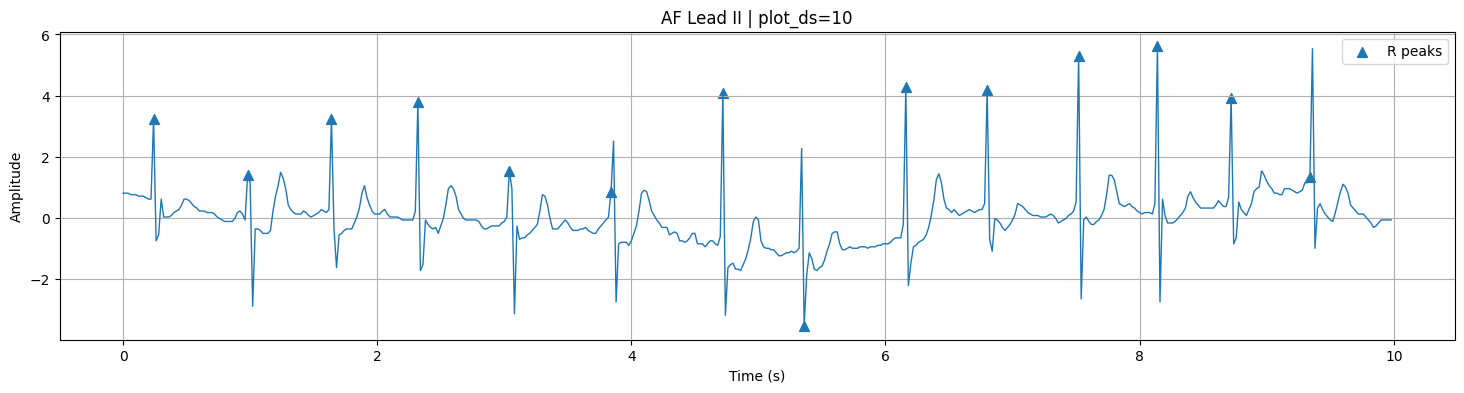

✅ Detected R peaks: 14


In [ ]:
r_af = plot_leadII_rpeaks_fast(
    sig_af,          # AF ECG signal (12, 5000)
    fs=fs_af,        # sampling rate (usually 500)
    seconds=10,      # show 10 seconds
    title="AF Lead II",
    plot_ds=10       # faster plotting
)


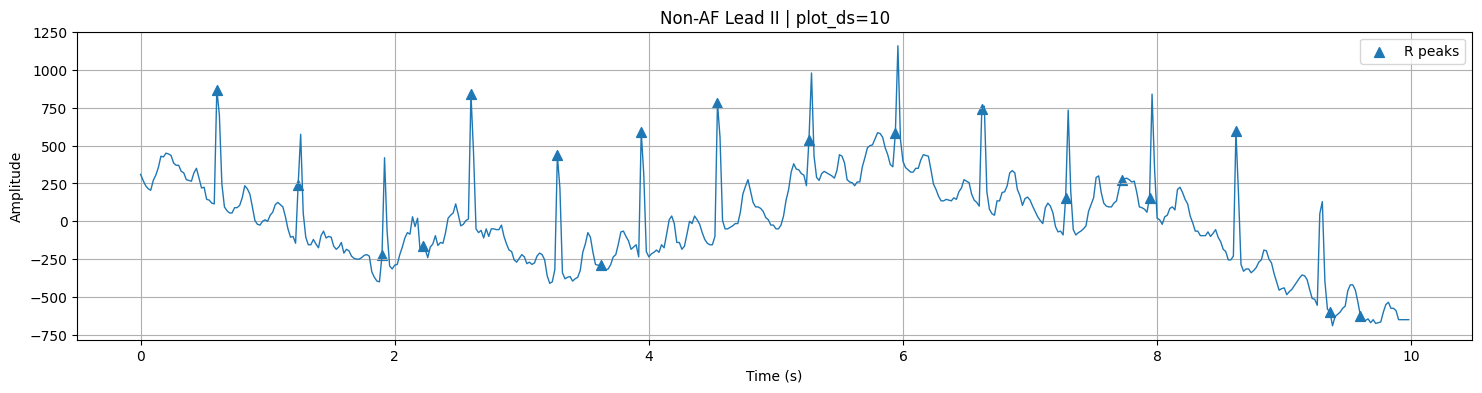

✅ Detected R peaks: 18


In [ ]:
r_non = plot_leadII_rpeaks_fast(
    sig_nonaf,       # Non-AF ECG signal (12, 5000)
    fs=fs_nonaf,
    seconds=10,
    title="Non-AF Lead II",
    plot_ds=10
)


In [ ]:
print(model)


ECGMultiTaskNet(
  (cnn): Sequential(
    (0): ConvBlock(
      (conv): Conv1d(12, 64, kernel_size=(9,), stride=(2,), padding=(4,), bias=False)
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
      (drop): Dropout(p=0.15, inplace=False)
    )
    (1): ConvBlock(
      (conv): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
      (drop): Dropout(p=0.15, inplace=False)
    )
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): ConvBlock(
      (conv): Conv1d(64, 128, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
      (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
      (drop): Dropout(p=0.15, inplace=False)
    )
    (4): ConvBl

In [ ]:
!pip -q install torchviz
from torchviz import make_dot
import torch

x = torch.randn(1, 12, 5000).to(DEVICE)
af_logit, mc_logit = model(x)

dot = make_dot(af_logit, params=dict(model.named_parameters()))
dot.format = "png"
dot.render("model_architecture", cleanup=True)

print("✅ Saved as model_architecture.png")


✅ Saved as model_architecture.png


In [ ]:
# ====== REPLACE CELL 33 WITH THIS ======

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k, s, p, drop=0.15):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, k, s, p, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)
        self.act = nn.GELU()
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        return self.drop(self.act(self.bn(self.conv(x))))

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, drop=0.2):
        super().__init__()
        self.c1 = nn.Conv1d(in_ch, out_ch, kernel_size=7, stride=stride, padding=3, bias=False)
        self.b1 = nn.BatchNorm1d(out_ch)
        self.c2 = nn.Conv1d(out_ch, out_ch, kernel_size=7, stride=1, padding=3, bias=False)
        self.b2 = nn.BatchNorm1d(out_ch)
        self.act = nn.GELU()
        self.drop = nn.Dropout(drop)

        self.skip = None
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )

    def forward(self, x):
        identity = x if self.skip is None else self.skip(x)
        out = self.drop(self.act(self.b1(self.c1(x))))
        out = self.b2(self.c2(out))
        out = self.act(out + identity)
        return out

class AttnPool1D(nn.Module):
    # (B,C,T) -> (B,C)
    def __init__(self, ch):
        super().__init__()
        self.score = nn.Conv1d(ch, 1, kernel_size=1)

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=-1)  # (B,1,T)
        return (x * w).sum(dim=-1)                # (B,C)

class ECGMultiTaskHybrid(nn.Module):
    """
    Shared CNN
    AF head: CNN -> BiLSTM -> AF logit
    MC head: CNN -> ResNet blocks -> AttnPool -> MC logits
    """
    def __init__(self, in_leads=12, num_classes=5, lstm_hidden=128, lstm_layers=2, dropout=0.4):
        super().__init__()

        # Shared CNN (same idea as your current model)
        self.cnn = nn.Sequential(
            ConvBlock(in_leads, 64, 9, 2, 4, drop=0.15),
            ConvBlock(64, 64, 7, 1, 3, drop=0.15),
            nn.MaxPool1d(2),

            ConvBlock(64, 128, 7, 2, 3, drop=0.15),
            ConvBlock(128, 128, 5, 1, 2, drop=0.15),
            nn.MaxPool1d(2),

            ConvBlock(128, 192, 5, 2, 2, drop=0.15),
            ConvBlock(192, 192, 3, 1, 1, drop=0.15),
        )

        # AF branch (keep BiLSTM)
        self.lstm = nn.LSTM(
            input_size=192,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
            bidirectional=True
        )
        self.af_drop = nn.Dropout(dropout)
        self.af_head = nn.Sequential(
            nn.Linear(2*lstm_hidden, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

        # Multiclass branch (ResNet1D + Attention Pooling)
        self.mc_res1 = ResBlock1D(192, 256, stride=2, drop=0.2)
        self.mc_res2 = ResBlock1D(256, 384, stride=2, drop=0.2)
        self.mc_res3 = ResBlock1D(384, 384, stride=1, drop=0.2)
        self.mc_pool = AttnPool1D(384)
        self.mc_head = nn.Sequential(
            nn.LayerNorm(384),
            nn.Dropout(0.3),
            nn.Linear(384, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat = self.cnn(x)  # (B,192,T')

        # AF path
        seq = feat.transpose(1, 2)         # (B,T',192)
        out, _ = self.lstm(seq)            # (B,T',2H)
        af_feat = out.mean(dim=1)          # (B,2H)
        af_feat = self.af_drop(af_feat)
        af_logit = self.af_head(af_feat).squeeze(-1)

        # MC path (no BiLSTM)
        m = self.mc_res1(feat)
        m = self.mc_res2(m)
        m = self.mc_res3(m)
        m = self.mc_pool(m)               # (B,384)
        mc_logit = self.mc_head(m)        # (B,5)

        return af_logit, mc_logit

model = ECGMultiTaskHybrid().to(DEVICE)
print("✅ Hybrid model ready")

✅ Hybrid model ready


In [ ]:
# ====== NEW CELL: create two loaders ======

# Loader A: for Phase 1 (multiclass-focused): superclass-balanced ONLY
train_loader_mc = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,   # <-- from Cell 25
    num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"), drop_last=True
)

# Loader B: for Phase 2 (joint training): paired sampler with soft AF boost
# (IMPORTANT: in Cell 26 you overwrite sampler; rename it there OR just rebuild here)
train_loader_joint = train_loader  # <-- from Cell 26 (your current train_loader)

print("✅ train_loader_mc + train_loader_joint ready")

✅ train_loader_mc + train_loader_joint ready


In [ ]:
# ====== REPLACE CELL 31 WITH THIS ======

mc_counts = train_df["y_super"].value_counts().sort_index().values.astype(np.float32)
inv = 1.0 / (mc_counts + 1e-6)
mc_w = inv / inv.sum() * 5  # normalize around num_classes
mc_w_t = torch.tensor(mc_w, dtype=torch.float32, device=DEVICE)

bce_af = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0], device=DEVICE))

class FocalCE(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, target):
        ce = F.cross_entropy(
            logits, target,
            weight=self.weight,
            reduction="none",
            label_smoothing=self.label_smoothing
        )
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

ce_mc = FocalCE(weight=mc_w_t, gamma=2.0, label_smoothing=0.05)

print("✅ multiclass weights:", np.round(mc_w, 3))

✅ multiclass weights: [0.312 0.704 0.775 2.252 0.957]


In [ ]:
import torch.nn.functional as F

In [ ]:
import torch.nn.functional as F

USE_AMP = (DEVICE == "cuda")

# Create scaler only if CUDA
scaler = torch.amp.GradScaler(enabled=USE_AMP)

def train_one_epoch(model, loader, LAMBDA_AF):
    model.train()
    total = 0.0

    for x, y_af, y_mc in loader:
        x = x.to(DEVICE, non_blocking=True)
        y_af = y_af.to(DEVICE, non_blocking=True)
        y_mc = y_mc.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if USE_AMP:
            # AMP path
            with torch.amp.autocast(device_type="cuda", enabled=True):
                af_logit, mc_logit = model(x)
                loss_af = bce_af(af_logit, y_af)
                loss_mc = ce_mc(mc_logit, y_mc)
                loss = LAMBDA_AF * loss_af + (1 - LAMBDA_AF) * loss_mc

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()

        else:
            # CPU / no-AMP path
            af_logit, mc_logit = model(x)
            loss_af = bce_af(af_logit, y_af)
            loss_mc = ce_mc(mc_logit, y_mc)
            loss = LAMBDA_AF * loss_af + (1 - LAMBDA_AF) * loss_mc

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()

        total += loss.item() * x.size(0)

    return total / len(loader.dataset)

In [ ]:
print("DEVICE:", DEVICE)
print("USE_AMP:", USE_AMP)

DEVICE: cuda
USE_AMP: True


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict

class GPT2SelfAttention(nn.Module):
    def __init__(self, d, n_heads, drop):
        super().__init__()
        assert d % n_heads == 0
        self.h   = n_heads
        self.dh  = d // n_heads
        self.q_proj   = nn.Linear(d, d, bias=False)
        self.k_proj   = nn.Linear(d, d, bias=False)
        self.v_proj   = nn.Linear(d, d, bias=False)
        self.out_proj = nn.Linear(d, d, bias=False)
        self.ad = nn.Dropout(drop)
        self.rd = nn.Dropout(drop)

    def forward(self, x, mask=None):
        B, T, C = x.shape
        H, D = self.h, self.dh
        q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)
        k = self.k_proj(x).view(B, T, H, D).transpose(1, 2)
        v = self.v_proj(x).view(B, T, H, D).transpose(1, 2)
        sc = (q @ k.transpose(-2, -1)) / math.sqrt(D)
        causal = torch.triu(torch.full((T, T), float("-inf"), device=x.device), 1)
        sc = sc + causal
        if mask is not None:
            sc = sc + (1 - mask[:, None, None, :].float()) * float("-inf")
        w   = self.ad(F.softmax(sc, dim=-1))
        out = (w @ v).transpose(1, 2).reshape(B, T, C)
        return self.rd(self.out_proj(out))

class GPT2Block(nn.Module):
    def __init__(self, d, n_heads, ffn_dim, drop):
        super().__init__()
        self.ln1  = nn.LayerNorm(d)
        self.attn = GPT2SelfAttention(d, n_heads, drop)
        self.ln2  = nn.LayerNorm(d)
        self.ff   = nn.Sequential(
            nn.Linear(d, ffn_dim), nn.GELU(), nn.Dropout(drop),
            nn.Linear(ffn_dim, d), nn.Dropout(drop),
        )

    def forward(self, x, mask=None):
        x = x + self.attn(self.ln1(x), mask)
        x = x + self.ff(self.ln2(x))
        return x

class GPT2Model(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model, n_heads, n_layers, ffn_dim, drop):
        super().__init__()
        self.tok    = nn.Embedding(vocab_size, d_model)
        self.pos    = nn.Embedding(seq_len, d_model)
        self.drop   = nn.Dropout(drop)
        self.blocks = nn.ModuleList([GPT2Block(d_model, n_heads, ffn_dim, drop) for _ in range(n_layers)])
        self.ln_f   = nn.LayerNorm(d_model)
        self.head   = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok.weight   # weight tying

    def forward(self, input_ids, attention_mask=None, labels=None):
        B, T = input_ids.shape
        pos  = torch.arange(T, device=input_ids.device).unsqueeze(0)
        x    = self.drop(self.tok(input_ids) + self.pos(pos))
        for blk in self.blocks:
            x = blk(x, attention_mask)
        logits = self.head(self.ln_f(x))   # (B, T, V)
        loss   = None
        if labels is not None:
            loss = F.cross_entropy(
                logits[:, :-1].reshape(-1, logits.size(-1)),
                labels[:, 1:].reshape(-1),
                ignore_index=tokenizer.PAD_ID,
            )
        return loss, logits

# Load the pretrained model weights manually
def load_model_weights(model, path):
    model_weights = torch.load(path)

    # If the weights are saved in a different format, you may need to adjust the loading
    if "model" in model_weights:
        model_weights = model_weights["model"]

    # Strip the prefix "module." if it was saved with DataParallel
    model_weights = {k.replace("module.", ""): v for k, v in model_weights.items()}

    model.load_state_dict(model_weights)
    return model

# Initialize model and load weights
model = GPT2Model(vocab_size=tokenizer.VOCAB_SIZE, seq_len=MAX_SEQ_LEN,
                  d_model=256, n_heads=8, n_layers=4, ffn_dim=1024, drop=0.1)

weights_path ="F:\\DOWNLOADS\\pytorch_model.bin"
model = load_model_weights(model, weights_path)

# Move the model to the correct device
model.to(DEVICE)

In [ ]:
# =========================
# XAI SETUP
# =========================
try:
    from captum.attr import IntegratedGradients, LayerGradCam, Occlusion, FeatureAblation
except ImportError:
    !pip -q install captum
    from captum.attr import IntegratedGradients, LayerGradCam, Occlusion, FeatureAblation

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

LEAD_NAMES = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
FS = 500

# Reuse your already-trained model from the notebook
xai_model = model
xai_model.eval()

# Use your notebook device directly
XAI_DEVICE = DEVICE

print("XAI ready.")
print("Device:", XAI_DEVICE)

In [ ]:
# =========================
# HELPERS
# =========================

class AFLogitWrapper(nn.Module):
    """
    Wraps your multitask model and returns only the AF logit
    in shape (B, 1), which Captum expects for target=0.
    """
    def init(self, base_model):
        super().init()
        self.base_model = base_model

    def forward(self, x):
        af_logit, _ = self.base_model(x)
        return af_logit.unsqueeze(1)

af_wrapper = AFLogitWrapper(xai_model).to(XAI_DEVICE).eval()


@torch.no_grad()
def predict_af(model_obj, x_input):
    model_obj.eval()
    af_logit, mc_logit = model_obj(x_input.to(XAI_DEVICE))
    af_prob = torch.sigmoid(af_logit).view(-1)[0].item()
    mc_prob = torch.softmax(mc_logit, dim=1)[0].detach().cpu().numpy()
    mc_pred = int(np.argmax(mc_prob))
    return af_prob, mc_pred, mc_prob


def get_case_index(dataset, case_kind="TP", threshold=0.5):
    """
    case_kind in {"TP","FP","FN","TN"}
    """
    case_kind = case_kind.upper()
    assert case_kind in {"TP", "FP", "FN", "TN"}

    for i in range(len(dataset)):
        x, y_af, y_mc = dataset[i]
        x_input = x.unsqueeze(0).to(XAI_DEVICE)

        af_prob, _, _ = predict_af(xai_model, x_input)
        pred = 1 if af_prob >= threshold else 0
        true = int(float(y_af.item()))

        if case_kind == "TP" and true == 1 and pred == 1:
            return i
        if case_kind == "FP" and true == 0 and pred == 1:
            return i
        if case_kind == "FN" and true == 1 and pred == 0:
            return i
        if case_kind == "TN" and true == 0 and pred == 0:
            return i

    raise RuntimeError(f"No {case_kind} sample found in the dataset.")


def get_sample_by_index(dataset, idx):
    x_sample, y_af, y_mc = dataset[idx]
    x_input = x_sample.unsqueeze(0).to(XAI_DEVICE).float()
    baseline = torch.zeros_like(x_input)
    return x_sample, y_af, y_mc, x_input, baseline


def find_last_conv1d(module):
    last_conv = None
    for m in module.modules():
        if isinstance(m, nn.Conv1d):
            last_conv = m
    if last_conv is None:
        raise RuntimeError("No Conv1d layer found in the model.")
    return last_conv


def safe_norm_1d(arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.abs(arr)
    mx = float(arr.max()) if arr.size > 0 else 0.0
    return arr / (mx + 1e-8)


def plot_signal_with_signed_attr(sig_1d, attr_1d, lead_idx=1, fs=500, seconds=10, title=""):
    T = min(len(sig_1d), int(seconds * fs))
    t = np.arange(T) / fs
    sig = sig_1d[:T]
    attr = attr_1d[:T]

    plt.figure(figsize=(16, 4))
    plt.plot(t, sig, linewidth=1.0, color="black", alpha=0.8, label=f"Lead {LEAD_NAMES[lead_idx]}")
    plt.fill_between(t, sig, sig + attr * 5.0, where=(attr > 0), alpha=0.45, label="Positive attribution")
    plt.fill_between(t, sig, sig + attr * 5.0, where=(attr < 0), alpha=0.45, label="Negative attribution")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude / attribution")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_signal_with_positive_attr(sig_1d, attr_1d, lead_idx=1, fs=500, seconds=10, title=""):
    T = min(len(sig_1d), int(seconds * fs))
    t = np.arange(T) / fs
    sig = sig_1d[:T]
    attr = safe_norm_1d(attr_1d[:T])

    ymin = float(sig.min())
    ymax = float(sig.max())
    span = ymax - ymin + 1e-8
    overlay = ymin + attr * span

    plt.figure(figsize=(16, 4))
    plt.plot(t, sig, linewidth=1.0, color="black", alpha=0.85, label=f"Lead {LEAD_NAMES[lead_idx]}")
    plt.fill_between(t, ymin, overlay, alpha=0.35, label="Importance")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude / normalized importance")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Assuming `XAI_DEVICE` and `xai_model` are defined somewhere else in the code

class AFLogitWrapper(nn.Module):
    """
    Wraps your multitask model and returns only the AF logit
    in shape (B, 1), which Captum expects for target=0.
    """
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        af_logit, _ = self.base_model(x)
        return af_logit.unsqueeze(1)


# Assuming `xai_model` is already defined and loaded
af_wrapper = AFLogitWrapper(xai_model).to(XAI_DEVICE).eval()


@torch.no_grad()
def predict_af(model_obj, x_input):
    model_obj.eval()
    af_logit, mc_logit = model_obj(x_input.to(XAI_DEVICE))
    af_prob = torch.sigmoid(af_logit).view(-1)[0].item()
    mc_prob = torch.softmax(mc_logit, dim=1)[0].detach().cpu().numpy()
    mc_pred = int(np.argmax(mc_prob))
    return af_prob, mc_pred, mc_prob


def get_case_index(dataset, case_kind="TP", threshold=0.5):
    """
    case_kind in {"TP", "FP", "FN", "TN"}
    """
    case_kind = case_kind.upper()
    assert case_kind in {"TP", "FP", "FN", "TN"}

    for i in range(len(dataset)):
        x, y_af, y_mc = dataset[i]
        x_input = x.unsqueeze(0).to(XAI_DEVICE)

        af_prob, _, _ = predict_af(xai_model, x_input)
        pred = 1 if af_prob >= threshold else 0
        true = int(float(y_af.item()))

        if case_kind == "TP" and true == 1 and pred == 1:
            return i
        if case_kind == "FP" and true == 0 and pred == 1:
            return i
        if case_kind == "FN" and true == 1 and pred == 0:
            return i
        if case_kind == "TN" and true == 0 and pred == 0:
            return i

    raise RuntimeError(f"No {case_kind} sample found in the dataset.")


def get_sample_by_index(dataset, idx):
    x_sample, y_af, y_mc = dataset[idx]
    x_input = x_sample.unsqueeze(0).to(XAI_DEVICE).float()
    baseline = torch.zeros_like(x_input)
    return x_sample, y_af, y_mc, x_input, baseline


def find_last_conv1d(module):
    last_conv = None
    for m in module.modules():
        if isinstance(m, nn.Conv1d):
            last_conv = m
    if last_conv is None:
        raise RuntimeError("No Conv1d layer found in the model.")
    return last_conv


def safe_norm_1d(arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.abs(arr)
    mx = float(arr.max()) if arr.size > 0 else 0.0
    return arr / (mx + 1e-8)


def plot_signal_with_signed_attr(sig_1d, attr_1d, lead_idx=1, fs=500, seconds=10, title=""):
    T = min(len(sig_1d), int(seconds * fs))
    t = np.arange(T) / fs
    sig = sig_1d[:T]
    attr = attr_1d[:T]

    plt.figure(figsize=(16, 4))
    plt.plot(t, sig, linewidth=1.0, color="black", alpha=0.8, label=f"Lead {LEAD_NAMES[lead_idx]}")
    plt.fill_between(t, sig, sig + attr * 5.0, where=(attr > 0), alpha=0.45, label="Positive attribution")
    plt.fill_between(t, sig, sig + attr * 5.0, where=(attr < 0), alpha=0.45, label="Negative attribution")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude / attribution")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_signal_with_positive_attr(sig_1d, attr_1d, lead_idx=1, fs=500, seconds=10, title=""):
    T = min(len(sig_1d), int(seconds * fs))
    t = np.arange(T) / fs
    sig = sig_1d[:T]
    attr = safe_norm_1d(attr_1d[:T])

    ymin = float(sig.min())
    ymax = float(sig.max())
    span = ymax - ymin + 1e-8
    overlay = ymin + attr * span

    plt.figure(figsize=(16, 4))
    plt.plot(t, sig, linewidth=1.0, color="black", alpha=0.85, label=f"Lead {LEAD_NAMES[lead_idx]}")
    plt.fill_between(t, ymin, overlay, alpha=0.35, label="Importance")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude / normalized importance")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_12lead_heatmap(attr_2d, fs=500, seconds=10, title="12-lead attribution heatmap"):
    T = min(attr_2d.shape[1], int(seconds * fs))
    plt.figure(figsize=(16, 5))
    vmax = np.max(np.abs(attr_2d[:, :T])) + 1e-8
    plt.imshow(
        attr_2d[:, :T],
        aspect="auto",
        cmap="seismic",
        origin="lower",
        vmin=-vmax,
        vmax=vmax,
        extent=[0, T / fs, 0, 12]
    )
    plt.yticks(np.arange(0.5, 12.5, 1.0), LEAD_NAMES)
    plt.xlabel("Time (s)")
    plt.title(title)
    plt.colorbar(label="Attribution")
    plt.tight_layout()
    plt.show()


def print_top_leads(attr_2d, top_k=5, name="Attribution"):
    lead_scores = np.mean(np.abs(attr_2d), axis=1)
    order = np.argsort(-lead_scores)[:top_k]
    print(f"\nTop {top_k} leads by mean |{name}|:")
    for rank, idx in enumerate(order, start=1):
        print(f"{rank}. {LEAD_NAMES[idx]}  -> {lead_scores[idx]:.6f}")
    return lead_scores


def get_top_time_windows(score_1d, fs=500, window_sec=0.5, top_k=3):
    window = int(window_sec * fs)
    score_1d = np.asarray(score_1d)
    n = len(score_1d)
    windows = []

    for start in range(0, n, window):
        end = min(start + window, n)
        s = float(np.mean(score_1d[start:end]))
        windows.append((start, end, s))

    windows.sort(key=lambda x: x[2], reverse=True)
    top = windows[:top_k]

    result = []
    for start, end, s in top:
        result.append({
            "start_idx": start,
            "end_idx": end,
            "start_sec": start / fs,
            "end_sec": end / fs,
            "score": s
        })
    return result


def build_feature_mask(x_input, window_size=125):
    """
    Groups contiguous lead-time windows for FeatureAblation.
    x_input shape: (1, 12, 5000)
    """
    _, n_leads, T = x_input.shape
    mask = torch.zeros((1, n_leads, T), dtype=torch.long, device=x_input.device)

    gid = 0
    for lead in range(n_leads):
        for start in range(0, T, window_size):
            end = min(start + window_size, T)
            mask[:, lead, start:end] = gid
            gid += 1
    return mask


def aggregate_time_score(attr_2d):
    """
    attr_2d shape: (12, T)
    Returns a 1D score over time.
    """
    return np.mean(np.abs(attr_2d), axis=0)

In [ ]:
# =========================
# PICK A SAMPLE
# =========================
# Change this to "FP", "FN", or "TN" later if you want
CASE_KIND = "TP"

sample_idx = get_case_index(test_ds, case_kind=CASE_KIND, threshold=0.5)
x_sample, y_af, y_mc, x_input, baseline = get_sample_by_index(test_ds, sample_idx)

af_prob, mc_pred, mc_prob = predict_af(xai_model, x_input)

print("Selected sample index:", sample_idx)
print("Case kind:", CASE_KIND)
print("Ground-truth AF label:", int(float(y_af.item())))
print("Predicted AF probability:", round(af_prob, 6))
print("Predicted multiclass label index:", mc_pred)

x_np = x_sample.detach().cpu().numpy()   # shape (12, 5000)

In [ ]:
# =========================
# 1) INTEGRATED GRADIENTS
# =========================
ig = IntegratedGradients(af_wrapper)

with torch.backends.cudnn.flags(enabled=False):
    ig_attr, ig_delta = ig.attribute(
        inputs=x_input,
        baselines=baseline,
        target=0,
        n_steps=64,
        internal_batch_size=1,
        return_convergence_delta=True
    )

ig_np = ig_attr.squeeze(0).detach().cpu().numpy()  # (12, 5000)

print("IG convergence delta:", float(ig_delta.item()))
print_top_leads(ig_np, top_k=5, name="IG")

plot_signal_with_signed_attr(
    sig_1d=x_np[1],
    attr_1d=ig_np[1],
    lead_idx=1,
    fs=FS,
    seconds=10,
    title=f"Integrated Gradients - Lead II ({CASE_KIND})"
)

plot_12lead_heatmap(
    ig_np,
    fs=FS,
    seconds=10,
    title=f"Integrated Gradients - 12 lead heatmap ({CASE_KIND})"
)

if str(XAI_DEVICE).startswith("cuda"):
    torch.cuda.empty_cache()

In [ ]:
base = getattr(xai_model, "model", xai_model)   # unwrap if af_wrapper holds .model
target_layer = base.cnn[-1].conv
print("Grad-CAM target layer:", target_layer)   # expect Conv1d(192, 192, kernel_size=(3,)...)

In [ ]:
# =========================
# 2) LAYER GRAD-CAM (manual, hook-based)
# =========================
target_layer = find_last_conv1d(xai_model)
print("Grad-CAM target layer:", target_layer)

def af_wrapper(x):
    out = xai_model(x)
    af_logit = out[0] if isinstance(out, (tuple, list)) else out  # AF head -> (B,)
    if af_logit.dim() == 1:
        af_logit = af_logit.unsqueeze(-1)                         # -> (B, 1)
    return af_logit

xai_model.eval()
x_input = x_input.clone().detach().to(XAI_DEVICE).requires_grad_(True)

# --- capture activation + gradient of the target conv via hooks ---
store = {"act": None, "grad": None}

def fwd_hook(module, inp, out):
    store["act"] = out
    if out.requires_grad:
        out.register_hook(lambda g: store.__setitem__("grad", g))

h = target_layer.register_forward_hook(fwd_hook)
try:
    with torch.enable_grad(), torch.backends.cudnn.flags(enabled=False):
        xai_model.zero_grad(set_to_none=True)
        logit = af_wrapper(x_input)                # (1, 1)
        print("wrapper out:", tuple(logit.shape), "| requires_grad:", logit.requires_grad)
        logit[0, 0].backward()
finally:
    h.remove()

# --- clear diagnostics if anything is still wrong ---
if store["act"] is None:
    raise RuntimeError(
        "Forward hook never fired: target_layer is NOT executed by xai_model. "
        "find_last_conv1d returned a Conv1d from a different module instance than xai_model runs."
    )
if store["grad"] is None:
    raise RuntimeError(
        "Activation captured but no gradient reached it: the layer is off the path to the AF logit, "
        "or the graph was severed (an in-place op, or a stray no_grad)."
    )

act  = store["act"]                                # (1, C, T')
grad = store["grad"]                               # (1, C, T')

# Grad-CAM: channel weights = mean gradient over time, weighted sum, then ReLU
weights = grad.mean(dim=2, keepdim=True)           # (1, C, 1)
cam = torch.relu((weights * act).sum(dim=1, keepdim=True))  # (1, 1, T')

# --- upsample to signal length (same as before) ---
gradcam_up = F.interpolate(
    cam, size=x_input.shape[-1], mode="linear", align_corners=False
)
gradcam_1d = gradcam_up.squeeze(0).squeeze(0).detach().cpu().numpy()
print("Grad-CAM shape after upsampling:", gradcam_1d.shape)

plot_signal_with_positive_attr(
    sig_1d=x_np[1],
    attr_1d=gradcam_1d,
    lead_idx=1,
    fs=FS,
    seconds=10,
    title=f"LayerGradCam - temporal importance over Lead II ({CASE_KIND})"
)

if str(XAI_DEVICE).startswith("cuda"):
    torch.cuda.empty_cache()

In [ ]:
import torch.nn as nn

base = getattr(xai_model, "model", xai_model)

target_layer = None
try:
    target_layer = base.cnn[-1].conv
except (AttributeError, TypeError, IndexError):
    pass

if not isinstance(target_layer, nn.Conv1d):
    # show what conv1d layers actually exist so we can pick the right one
    print(">>> base.cnn[-1].conv not found. Conv1d layers in the model:")
    for n, m in base.named_modules():
        if isinstance(m, nn.Conv1d):
            print(f"    {n:40s} {m}")
    raise RuntimeError("Set target_layer manually from the list above (the 192->192 k=3 conv).")

assert target_layer.in_channels == 192 and target_layer.out_channels == 192, \
    f"Wrong layer picked: {target_layer}"
print("Grad-CAM target layer:", target_layer)

In [ ]:
# =========================
# 2) LAYER GRAD-CAM (final)
# =========================
import torch.nn as nn

# --- 1. Select the last conv on the AF path (192->192, k=3), not a side-branch head ---
base = getattr(xai_model, "model", xai_model)
target_layer = None
try:
    target_layer = base.cnn[-1].conv
except (AttributeError, TypeError, IndexError):
    pass

if not isinstance(target_layer, nn.Conv1d):
    print(">>> base.cnn[-1].conv not found. Conv1d layers in the model:")
    for n, m in base.named_modules():
        if isinstance(m, nn.Conv1d):
            print(f"    {n:40s} {m}")
    raise RuntimeError("Set target_layer manually from the list above (the 192->192 k=3 conv).")

assert target_layer.in_channels == 192 and target_layer.out_channels == 192, \
    f"Wrong layer picked: {target_layer}"
print("Grad-CAM target layer:", target_layer)

# --- 2. Wrapper: run xai_model, return AF logit as (B, 1) ---
def af_wrapper(x):
    out = xai_model(x)
    af_logit = out[0] if isinstance(out, (tuple, list)) else out  # AF head -> (B,)
    if af_logit.dim() == 1:
        af_logit = af_logit.unsqueeze(-1)                         # -> (B, 1)
    return af_logit

xai_model.eval()
x_input = x_input.clone().detach().to(XAI_DEVICE).requires_grad_(True)

# --- 3. Capture activation + gradient of the target conv via hooks ---
store = {"act": None, "grad": None}

def fwd_hook(module, inp, out):
    store["act"] = out
    if out.requires_grad:
        out.register_hook(lambda g: store.__setitem__("grad", g))

h = target_layer.register_forward_hook(fwd_hook)
try:
    with torch.enable_grad(), torch.backends.cudnn.flags(enabled=False):
        xai_model.zero_grad(set_to_none=True)
        logit = af_wrapper(x_input)                # (1, 1)
        print("wrapper out:", tuple(logit.shape), "| requires_grad:", logit.requires_grad)
        logit[0, 0].backward()
finally:
    h.remove()

if store["act"] is None:
    raise RuntimeError("Forward hook never fired: target_layer is not executed by xai_model.")
if store["grad"] is None:
    raise RuntimeError("No gradient reached the layer: it is off the AF path or the graph was severed.")

# --- 4. Grad-CAM: channel weights = mean grad over time, weighted sum, ReLU ---
act  = store["act"]                                          # (1, C, T')
grad = store["grad"]                                         # (1, C, T')
weights = grad.mean(dim=2, keepdim=True)                     # (1, C, 1)
cam = torch.relu((weights * act).sum(dim=1, keepdim=True))   # (1, 1, T')

# --- 5. Upsample to signal length and plot ---
gradcam_up = F.interpolate(cam, size=x_input.shape[-1], mode="linear", align_corners=False)
gradcam_1d = gradcam_up.squeeze(0).squeeze(0).detach().cpu().numpy()
print("Grad-CAM shape after upsampling:", gradcam_1d.shape)

plot_signal_with_positive_attr(
    sig_1d=x_np[1],
    attr_1d=gradcam_1d,
    lead_idx=1,
    fs=FS,
    seconds=10,
    title=f"LayerGradCam - temporal importance over Lead II ({CASE_KIND})"
)

if str(XAI_DEVICE).startswith("cuda"):
    torch.cuda.empty_cache()

In [ ]:
# =========================
# REUSABLE GRAD-CAM
# =========================
import torch.nn as nn

def _resolve_af_conv(model, verbose=False):
    """Return the last conv on the AF path (192->192, k=3), not a side-branch head."""
    base = getattr(model, "model", model)
    layer = None
    try:
        layer = base.cnn[-1].conv
    except (AttributeError, TypeError, IndexError):
        pass
    if not isinstance(layer, nn.Conv1d):
        print(">>> base.cnn[-1].conv not found. Conv1d layers in the model:")
        for n, m in base.named_modules():
            if isinstance(m, nn.Conv1d):
                print(f"    {n:40s} {m}")
        raise RuntimeError("Set target_layer manually from the list above (the 192->192 k=3 conv).")
    assert layer.in_channels == 192 and layer.out_channels == 192, f"Wrong layer picked: {layer}"
    if verbose:
        print("Grad-CAM target layer:", layer)
    return layer


def explain_gradcam(x_input, x_np, lead_idx=1, case_kind="", *,
                    sample_idx=0, target_layer=None, verbose=True):
    """
    Grad-CAM temporal importance for the AF head, over one lead of one example.

    x_input     : input tensor on/for the model, shape (B, C, T)
    x_np        : numpy signal for plotting, shape (C, T)  (same example as x_input[sample_idx])
    lead_idx    : which lead to plot (e.g. 1 = Lead II)
    case_kind   : label for the title (e.g. "TP", "FP", "FN", "TN")
    sample_idx  : which example in the batch to explain
    target_layer: override the auto-selected conv if needed
    Returns     : gradcam_1d (np.ndarray, length T)
    """
    layer = target_layer if target_layer is not None else _resolve_af_conv(xai_model, verbose)

    def af_wrapper(x):
        out = xai_model(x)
        af_logit = out[0] if isinstance(out, (tuple, list)) else out  # (B,)
        if af_logit.dim() == 1:
            af_logit = af_logit.unsqueeze(-1)                         # (B, 1)
        return af_logit

    xai_model.eval()
    xin = x_input.clone().detach().to(XAI_DEVICE).requires_grad_(True)

    store = {"act": None, "grad": None}
    def fwd_hook(module, inp, out):
        store["act"] = out
        if out.requires_grad:
            out.register_hook(lambda g: store.__setitem__("grad", g))

    h = layer.register_forward_hook(fwd_hook)
    try:
        with torch.enable_grad(), torch.backends.cudnn.flags(enabled=False):
            xai_model.zero_grad(set_to_none=True)
            logit = af_wrapper(xin)                       # (B, 1)
            if verbose:
                print("wrapper out:", tuple(logit.shape), "| requires_grad:", logit.requires_grad)
            logit[sample_idx, 0].backward()
    finally:
        h.remove()

    if store["act"] is None:
        raise RuntimeError("Forward hook never fired: target_layer is not executed by xai_model.")
    if store["grad"] is None:
        raise RuntimeError("No gradient reached the layer: it is off the AF path or the graph was severed.")

    # Grad-CAM on the selected example only
    act  = store["act"][sample_idx:sample_idx+1]                  # (1, C, T')
    grad = store["grad"][sample_idx:sample_idx+1]                 # (1, C, T')
    weights = grad.mean(dim=2, keepdim=True)                      # (1, C, 1)
    cam = torch.relu((weights * act).sum(dim=1, keepdim=True))    # (1, 1, T')

    gradcam_up = F.interpolate(cam, size=xin.shape[-1], mode="linear", align_corners=False)
    gradcam_1d = gradcam_up.squeeze(0).squeeze(0).detach().cpu().numpy()
    if verbose:
        print("Grad-CAM shape after upsampling:", gradcam_1d.shape)

    plot_signal_with_positive_attr(
        sig_1d=x_np[lead_idx],
        attr_1d=gradcam_1d,
        lead_idx=lead_idx,
        fs=FS,
        seconds=10,
        title=f"LayerGradCam - temporal importance over Lead II ({case_kind})"
    )

    if str(XAI_DEVICE).startswith("cuda"):
        torch.cuda.empty_cache()

    return gradcam_1d

In [ ]:
cam_tp = explain_gradcam(x_input, x_np, lead_idx=1, case_kind="TP")

In [ ]:
cam_fp = explain_gradcam(x_fp_input, x_fp_np, lead_idx=1, case_kind="FP")
cam_fn = explain_gradcam(x_fn_input, x_fn_np, lead_idx=1, case_kind="FN")
cam_tn = explain_gradcam(x_tn_input, x_tn_np, lead_idx=1, case_kind="TN")

In [ ]:
# =========================
# 2) LAYER GRAD-CAM
# =========================
target_layer = find_last_conv1d(xai_model)
print("Grad-CAM target layer:", target_layer)

# Wrapper MUST run xai_model (same instance target_layer came from)
# and return a 2-D tensor so target=0 indexes a real class dim.
def af_wrapper(x):
    out = xai_model(x)
    af_logit = out[0] if isinstance(out, (tuple, list)) else out  # AF head -> (B,)
    if af_logit.dim() == 1:
        af_logit = af_logit.unsqueeze(-1)                         # -> (B, 1)
    return af_logit

xai_model.eval()  # eval mode, but gradients stay ENABLED below

# Input must require grad for Grad-CAM to populate the conv activations in the graph
x_input = x_input.clone().detach().to(XAI_DEVICE).requires_grad_(True)

layer_gc = LayerGradCam(af_wrapper, target_layer)

# torch.enable_grad() overrides any ambient no_grad; cudnn disabled for LSTM backward
with torch.enable_grad(), torch.backends.cudnn.flags(enabled=False):
    # sanity check: should print a 2-D shape and requires_grad=True
    _probe = af_wrapper(x_input)
    print("wrapper out:", tuple(_probe.shape), "| requires_grad:", _probe.requires_grad)

    gradcam_attr = layer_gc.attribute(
        inputs=x_input,
        target=0,
        relu_attributions=True
    )

# Expected shape for 1D conv case is (1, 1, T')
if gradcam_attr.dim() == 3:
    gradcam_up = F.interpolate(
        gradcam_attr,
        size=x_input.shape[-1],
        mode="linear",
        align_corners=False
    )
    gradcam_1d = gradcam_up.squeeze(0).squeeze(0).detach().cpu().numpy()
else:
    raise RuntimeError(f"Unexpected Grad-CAM shape: {tuple(gradcam_attr.shape)}")

print("Grad-CAM shape after upsampling:", gradcam_1d.shape)

plot_signal_with_positive_attr(
    sig_1d=x_np[1],
    attr_1d=gradcam_1d,
    lead_idx=1,
    fs=FS,
    seconds=10,
    title=f"LayerGradCam - temporal importance over Lead II ({CASE_KIND})"
)

if str(XAI_DEVICE).startswith("cuda"):
    torch.cuda.empty_cache()

In [ ]:
# =========================
# 2) LAYER GRAD-CAM
# =========================
target_layer = find_last_conv1d(xai_model)
print("Grad-CAM target layer:", target_layer)

layer_gc = LayerGradCam(af_wrapper, target_layer)

with torch.backends.cudnn.flags(enabled=False):
    gradcam_attr = layer_gc.attribute(
        inputs=x_input,
        target=0,
        relu_attributions=True
    )

# Expected shape for 1D conv case is usually (1, 1, T')
if gradcam_attr.dim() == 3:
    gradcam_up = F.interpolate(
        gradcam_attr,
        size=x_input.shape[-1],
        mode="linear",
        align_corners=False
    )
    gradcam_1d = gradcam_up.squeeze(0).squeeze(0).detach().cpu().numpy()
else:
    raise RuntimeError(f"Unexpected Grad-CAM shape: {tuple(gradcam_attr.shape)}")

print("Grad-CAM shape after upsampling:", gradcam_1d.shape)

plot_signal_with_positive_attr(
    sig_1d=x_np[1],
    attr_1d=gradcam_1d,
    lead_idx=1,
    fs=FS,
    seconds=10,
    title=f"LayerGradCam - temporal importance over Lead II ({CASE_KIND})"
)

if str(XAI_DEVICE).startswith("cuda"):
    torch.cuda.empty_cache()


In [ ]:
def pick_all_cases(dataset, threshold=0.5):
    found = {}
    label = {(1,1):"TP", (1,0):"FP", (0,1):"FN", (0,0):"TN"}
    for i in range(len(dataset)):
        x, y_af, y_mc = dataset[i]
        af_prob, _, _ = predict_af(xai_model, x.unsqueeze(0).to(XAI_DEVICE))
        pred, true = int(af_prob >= threshold), int(float(y_af.item()))
        found.setdefault(label[(pred, true)], i)
        if len(found) == 4:
            break
    return found

cases = pick_all_cases(test_ds)
print(cases)

cams = {}
for kind, idx in cases.items():
    x_sample, y_af, y_mc, x_input, baseline = get_sample_by_index(test_ds, idx)
    x_np = x_sample.detach().cpu().numpy()
    cams[kind] = explain_gradcam(x_input, x_np, lead_idx=1, case_kind=kind)

In [ ]:
def find_last_conv1d(module):
    base = getattr(module, "model", module)
    try:
        layer = base.cnn[-1].conv          # the 192->192 k=3 conv, on the AF path
        if isinstance(layer, nn.Conv1d):
            return layer
    except (AttributeError, TypeError, IndexError):
        pass
    # fallback: last real conv, skipping 1x1 projection heads
    convs = [m for m in base.modules() if isinstance(m, nn.Conv1d) and m.kernel_size[0] > 1]
    if not convs:
        raise RuntimeError("No spatial Conv1d found.")
    return convs[-1]

In [ ]:
# =========================
# 3) OCCLUSION
# =========================
# Window = 125 samples = 0.25 sec at 500 Hz
OCC_WINDOW = 125
OCC_STRIDE = 125

occlusion = Occlusion(af_wrapper)

occ_attr = occlusion.attribute(
    inputs=x_input,
    target=0,
    baselines=0.0,
    sliding_window_shapes=(1, OCC_WINDOW),   # (lead_window, time_window)
    strides=(1, OCC_STRIDE),
    perturbations_per_eval=1
)

occ_np = occ_attr.squeeze(0).detach().cpu().numpy()  # (12, 5000)

print_top_leads(occ_np, top_k=5, name="Occlusion")

plot_signal_with_signed_attr(
    sig_1d=x_np[1],
    attr_1d=occ_np[1],
    lead_idx=1,
    fs=FS,
    seconds=10,
    title=f"Occlusion attribution - Lead II ({CASE_KIND})"
)

plot_12lead_heatmap(
    occ_np,
    fs=FS,
    seconds=10,
    title=f"Occlusion attribution - 12 lead heatmap ({CASE_KIND})"
)

if str(XAI_DEVICE).startswith("cuda"):
    torch.cuda.empty_cache()

In [ ]:
# =========================
# 4) FEATURE ABLATION
# =========================
ABL_WINDOW = 125
feature_mask = build_feature_mask(x_input, window_size=ABL_WINDOW)

feature_ablation = FeatureAblation(af_wrapper)

fab_attr = feature_ablation.attribute(
    inputs=x_input,
    target=0,
    baselines=0.0,
    feature_mask=feature_mask,
    perturbations_per_eval=1
)

fab_np = fab_attr.squeeze(0).detach().cpu().numpy()  # (12, 5000)

print_top_leads(fab_np, top_k=5, name="Feature Ablation")

plot_signal_with_signed_attr(
    sig_1d=x_np[1],
    attr_1d=fab_np[1],
    lead_idx=1,
    fs=FS,
    seconds=10,
    title=f"Feature Ablation - Lead II ({CASE_KIND})"
)

plot_12lead_heatmap(
    fab_np,
    fs=FS,
    seconds=10,
    title=f"Feature Ablation - 12 lead heatmap ({CASE_KIND})"
)

if str(XAI_DEVICE).startswith("cuda"):
    torch.cuda.empty_cache()

In [ ]:
# =========================
# 5) TEMPLATE EXPLANATION GENERATOR
# =========================

def summarize_xai_results(ig_np, gradcam_1d, occ_np, fab_np, af_prob, fs=500):
    # Lead ranking from IG
    ig_lead_scores = np.mean(np.abs(ig_np), axis=1)
    top_lead_ids = np.argsort(-ig_lead_scores)[:3]
    top_leads = [LEAD_NAMES[i] for i in top_lead_ids]

    # Temporal score combines all four methods
    time_score = (
        safe_norm_1d(np.mean(np.abs(ig_np), axis=0)) +
        safe_norm_1d(gradcam_1d) +
        safe_norm_1d(np.mean(np.abs(occ_np), axis=0)) +
        safe_norm_1d(np.mean(np.abs(fab_np), axis=0))
    ) / 4.0

    top_windows = get_top_time_windows(time_score, fs=fs, window_sec=0.5, top_k=3)

    summary = {
        "af_probability": float(af_prob),
        "top_leads": top_leads,
        "top_windows": top_windows,
        "ig_lead_scores": ig_lead_scores,
        "time_score": time_score
    }
    return summary


def build_template_explanation(summary):
    prob = summary["af_probability"]
    leads = summary["top_leads"]
    windows = summary["top_windows"]

    lead_text = ", ".join(leads)
    win_text = ", ".join(f"{w['start_sec']:.2f}-{w['end_sec']:.2f}s" for w in windows[:2])

    if prob >= 0.80:
        conf_text = "high confidence"
    elif prob >= 0.50:
        conf_text = "moderate confidence"
    else:
        conf_text = "low confidence"

    explanation = (
        f"The model predicts AF with {conf_text} "
        f"(predicted probability = {prob:.3f}). "
        f"The strongest evidence is concentrated in leads {lead_text}. "
        f"The most influential time regions are around {win_text}. "
        f"These regions were consistently highlighted by gradient-based "
        f"(Integrated Gradients, Grad-CAM) and perturbation-based "
        f"(occlusion, feature ablation) explainability methods."
    )
    return explanation


# gradcam_1d = cams[CASE_KIND]  # uncomment if your Grad-CAM result is stored in the cams dict
xai_summary = summarize_xai_results(
    ig_np=ig_np,
    gradcam_1d=gradcam_1d,
    occ_np=occ_np,
    fab_np=fab_np,
    af_prob=af_prob,
    fs=FS
)

print("\nTop leads:", xai_summary["top_leads"])
print("Top windows:")
for w in xai_summary["top_windows"]:
    print(f"  {w['start_sec']:.2f}s to {w['end_sec']:.2f}s  | score={w['score']:.6f}")

generated_explanation = build_template_explanation(xai_summary)

print("\nGenerated explanation:")
print(generated_explanation)

In [ ]:
import numpy as np

# Assuming LEAD_NAMES, safe_norm_1d, get_top_time_windows, and other variables are defined correctly

def summarize_xai_results(ig_np, occ_np, fab_np, af_prob, fs=500):
    # Lead ranking from IG
    ig_lead_scores = np.mean(np.abs(ig_np), axis=1)
    top_lead_ids = np.argsort(-ig_lead_scores)[:3]
    top_leads = [LEAD_NAMES[i] for i in top_lead_ids]

    # Temporal score combines multiple methods
    time_score = (
        safe_norm_1d(np.mean(np.abs(ig_np), axis=0)) +
        safe_norm_1d(np.mean(np.abs(occ_np), axis=0)) +
        safe_norm_1d(np.mean(np.abs(fab_np), axis=0))
    ) / 3.0  # Adjusted to include only the available methods

    top_windows = get_top_time_windows(time_score, fs=fs, window_sec=0.5, top_k=3)

    summary = {
        "af_probability": float(af_prob),
        "top_leads": top_leads,
        "top_windows": top_windows,
        "ig_lead_scores": ig_lead_scores,
        "time_score": time_score
    }
    return summary


def build_template_explanation(summary):
    prob = summary["af_probability"]
    leads = summary["top_leads"]
    windows = summary["top_windows"]

    lead_text = ", ".join(leads)

    win_text_parts = []
    for w in windows[:2]:
        win_text_parts.append(f"{w['start_sec']:.2f}-{w['end_sec']:.2f}s")
    win_text = ", ".join(win_text_parts)

    if prob >= 0.80:
        conf_text = "high confidence"
    elif prob >= 0.50:
        conf_text = "moderate confidence"
    else:
        conf_text = "low confidence"

    explanation = (
        f"The model predicts AF with {conf_text} "
        f"(predicted probability = {prob:.3f}). "
        f"The strongest evidence is concentrated in leads {lead_text}. "
        f"The most influential time regions are around {win_text}. "
        f"These regions were consistently highlighted by input-gradient and "
        f"perturbation-based explainability methods."
    )
    return explanation


# Assuming ig_np, occ_np, fab_np, af_prob, and FS are defined
xai_summary = summarize_xai_results(
    ig_np=ig_np,
    occ_np=occ_np,
    fab_np=fab_np,
    af_prob=af_prob,
    fs=FS
)

print("\nTop leads:", xai_summary["top_leads"])
print("Top windows:")
for w in xai_summary["top_windows"]:
    print(f"  {w['start_sec']:.2f}s to {w['end_sec']:.2f}s  | score={w['score']:.6f}")

generated_explanation = build_template_explanation(xai_summary)

print("\nGenerated explanation:")
print(generated_explanation)

In [ ]:
# ============================================================
# EXTERNAL DATASET VALIDATION — preprocessing must match training
# ============================================================
import os, glob, numpy as np, torch
from math import gcd
from scipy.signal import resample_poly
from sklearn.metrics import roc_auc_score, confusion_matrix

PTBXL_LEADS = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]

def _canon(name):
    return str(name).upper().replace("LEAD", "").replace(" ", "").strip()

def reorder_leads(sig, sig_names, target=PTBXL_LEADS):
    name_to_row = {_canon(nm): i for i, nm in enumerate(sig_names)}
    missing = [l for l in target if l not in name_to_row]
    if missing:
        raise ValueError(f"Record missing leads {missing}; has {sorted(name_to_row)}")
    return sig[[name_to_row[l] for l in target], :]

def prepare_ecg(sig, fs, sig_names, target_fs=500, target_len=SIG_LEN):
    sig = reorder_leads(sig, sig_names).astype(np.float32)          # match lead order
    if int(fs) != int(target_fs):                                  # resample to 500 Hz
        g = gcd(int(fs), int(target_fs))
        sig = resample_poly(sig, target_fs // g, fs // g, axis=1).astype(np.float32)
    if sig.shape[1] < target_len:                                  # crop / pad to 5000
        sig = np.pad(sig, ((0,0),(0,target_len - sig.shape[1])), mode="constant")
    else:
        sig = sig[:, :target_len]
    return zscore_per_lead(sig).astype(np.float32)                 # SAME normalization

def read_record_any(base_path):
    """Prefer wfdb (handles gain/format); fall back to your raw reader."""
    try:
        import wfdb
        rec = wfdb.rdrecord(base_path)
        return rec.p_signal.T.astype(np.float32), int(rec.fs), list(rec.sig_name)
    except Exception:
        return read_ptbxl_record(base_path)

@torch.no_grad()
def evaluate_external(records, labels, threshold=0.5, batch=32, name="external"):
    xai_model.eval()
    probs, buf = [], []
    def flush(b):
        if not b: return []
        xb = torch.from_numpy(np.stack(b)).float().to(XAI_DEVICE)
        af_logit, _ = xai_model(xb)
        return torch.sigmoid(af_logit).view(-1).detach().cpu().numpy().tolist()
    for k, rb in enumerate(records):
        sig, fs, names = read_record_any(rb)
        buf.append(prepare_ecg(sig, fs, names))
        if len(buf) == batch:
            probs += flush(buf); buf = []
        if (k+1) % 500 == 0:
            print(f"  processed {k+1}/{len(records)}")
    probs += flush(buf)
    probs, y = np.asarray(probs), np.asarray(labels).astype(int)
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, preds, labels=[0,1]).ravel()
    sens = tp/(tp+fn+1e-9); spec = tn/(tn+fp+1e-9)
    ppv  = tp/(tp+fp+1e-9); f1 = 2*ppv*sens/(ppv+sens+1e-9)
    auc  = roc_auc_score(y, probs) if len(np.unique(y)) > 1 else float("nan")
    print(f"[{name}] n={len(y)}  AF+={int(y.sum())}  thr={threshold:.3f}")
    print(f"  AUC={auc:.3f} | Sens={sens:.3f} Spec={spec:.3f} PPV={ppv:.3f} F1={f1:.3f}")
    print(f"  TP={tp} FP={fp} FN={fn} TN={tn}")
    return {"probs": probs, "labels": y, "auc": auc}

In [ ]:
# Set this to your external dataset root on Kaggle:
EXT_ROOT = "/kaggle/input/datasets/erarayamorenzomuten/chapmanshaoxing-12lead-ecg-database/WFDB_ChapmanShaoxing"

AF_SNOMED = {"164889003"}  # atrial fibrillation (SNOMED-CT, PhysioNet convention)

def afib_from_header(hea_path):
    with open(hea_path) as f:
        for ln in f:
            if ln.lower().replace(" ", "").startswith("#dx"):
                codes = ln.split(":", 1)[1].strip().replace(" ", "").split(",")
                return int(any(c in AF_SNOMED for c in codes))
    return None

records, labels = [], []
for hea in sorted(glob.glob(os.path.join(EXT_ROOT, "**", "*.hea"), recursive=True)):
    lab = afib_from_header(hea)
    if lab is not None:
        records.append(hea[:-4])   # base path without extension
        labels.append(lab)
print(f"Found {len(records)} records, {sum(labels)} AF positive "
      f"({100*np.mean(labels):.1f}% prevalence)")

res = evaluate_external(records, labels, threshold=0.5, name="Chapman")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score)

probs = res["probs"]
y     = res["labels"]
threshold = 0.5
preds = (probs >= threshold).astype(int)

# --- classification report ---
print(classification_report(y, preds, target_names=["non-AF", "AF"],
                            digits=3, zero_division=0))

# --- ROC ---
fpr, tpr, _ = roc_curve(y, probs)
roc_auc = auc(fpr, tpr)

# --- Precision-Recall (better for imbalance) ---
prec, rec, _ = precision_recall_curve(y, probs)
ap = average_precision_score(y, probs)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC — Chapman (external)"); ax[0].legend(loc="lower right"); ax[0].grid(alpha=0.3)

ax[1].plot(rec, prec, lw=2, label=f"AP = {ap:.3f}")
ax[1].axhline(y.mean(), ls="--", color="gray", lw=1, label=f"Prevalence = {y.mean():.3f}")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall — Chapman"); ax[1].legend(loc="upper right"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- WHY: probability distribution by true class ---
af_p, non_p = probs[y == 1], probs[y == 0]
print(f"\nAF  probs : mean={af_p.mean():.3f}  min={af_p.min():.3f}  max={af_p.max():.3f}")
print(f"non-AF    : mean={non_p.mean():.3f}  min={non_p.min():.3f}  max={non_p.max():.3f}")

In [ ]:
# 1. probability distribution by true class
probs, y = res["probs"], res["labels"]
print("AF     probs: mean=%.3f min=%.3f max=%.3f" % (probs[y==1].mean(), probs[y==1].min(), probs[y==1].max()))
print("non-AF probs: mean=%.3f min=%.3f max=%.3f" % (probs[y==0].mean(), probs[y==0].min(), probs[y==0].max()))

# 2. what one record actually looks like coming in
sig, fs, names = read_record_any(records[0])
print("fs:", fs, "| n_leads:", sig.shape[0], "| names:", names)
xp = prepare_ecg(sig, fs, names)
print("prepared shape:", xp.shape, "| per-lead std after z-score:", np.round(xp.std(axis=1), 2))

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

p, ys = [], []
for i in range(len(test_ds)):
    x, y_af, y_mc = test_ds[i]
    prob, _, _ = predict_af(xai_model, x.unsqueeze(0).to(XAI_DEVICE))
    p.append(prob); ys.append(int(float(y_af.item())))
p, ys = np.array(p), np.array(ys)

print(f"PTB-XL test AF prob: mean={p.mean():.3f} std={p.std():.4f} min={p.min():.3f} max={p.max():.3f}")
print(f"  AF mean={p[ys==1].mean():.3f} | non-AF mean={p[ys==0].mean():.3f}")
print(f"  AUC={roc_auc_score(ys, p):.3f}")

In [ ]:
xb, yaf, ymc = next(iter(train_loader))
xb, yaf = xb.to(DEVICE), yaf.to(DEVICE).float()
model.train()
af_logit, mc_logit = model(xb)
loss = nn.BCEWithLogitsLoss()(af_logit.view(-1), yaf.view(-1))
model.zero_grad(); loss.backward()

for n, p in model.named_parameters():
    if "af_head" in n and p.grad is not None:
        print(f"{n:35s} grad_norm={p.grad.norm().item():.3e}")
print("AF logit spread in this batch:", af_logit.detach().std().item())

DEVICE: cuda
train: n=17441  AF+=1211 (6.9%)
val: n=2193  AF+=151 (6.9%)
test: n=2203  AF+=152 (6.9%)


/tmp/ipykernel_57/1325487184.py:254: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_57/1325487184.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[01] train_loss=0.1752 | val_AUC=0.9808 | prob_std=0.2714
   saved best (AUC=0.9808)


/tmp/ipykernel_57/1325487184.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[02] train_loss=0.0992 | val_AUC=0.9882 | prob_std=0.2784
   saved best (AUC=0.9882)


...

[17] train_loss=0.0200 | val_AUC=0.9890 | prob_std=0.2550


/tmp/ipykernel_57/1325487184.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[18] train_loss=0.0197 | val_AUC=0.9895 | prob_std=0.2533


/tmp/ipykernel_57/1325487184.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[19] train_loss=0.0169 | val_AUC=0.9891 | prob_std=0.2543
early stopping
best val AUC = 0.9938

Operating threshold (Youden's J on val): 0.035

===== PTB-XL TEST (internal) (thr=0.035) =====
AUC = 0.9808
              precision    recall  f1-score   support

      non-AF      0.995     0.969     0.982      2051
          AF      0.689     0.934     0.793       152

    accuracy                          0.966      2203
   macro avg      0.842     0.952     0.888      2203
weighted avg      0.974     0.966     0.969      2203



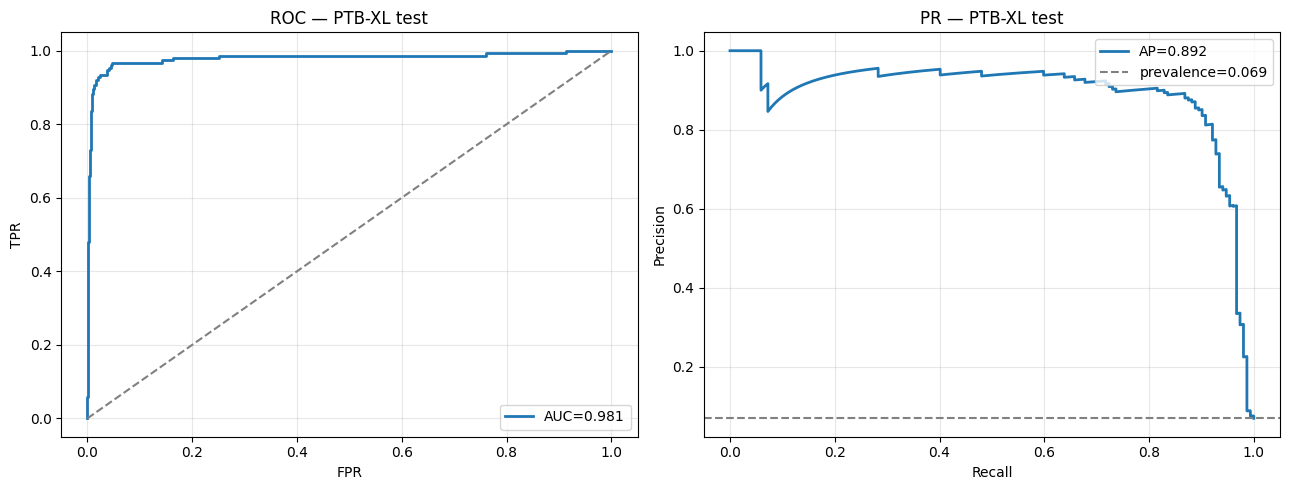

Chapman: 10247 records, 1780 AF+ (17.4%)
  1000/10247
  2000/10247
  3000/10247
  4000/10247
  5000/10247
  6000/10247
  7000/10247
  8000/10247
  9000/10247
  10000/10247

===== CHAPMAN (external, val-threshold) (thr=0.035) =====
AUC = 0.9610
              precision    recall  f1-score   support

      non-AF      0.993     0.834     0.907      8467
          AF      0.552     0.973     0.704      1780

    accuracy                          0.858     10247
   macro avg      0.772     0.903     0.805     10247
weighted avg      0.917     0.858     0.871     10247


===== CHAPMAN (external, 0.5) (thr=0.500) =====
AUC = 0.9610
              precision    recall  f1-score   support

      non-AF      0.986     0.869     0.924      8467
          AF      0.602     0.942     0.734      1780

    accuracy                          0.882     10247
   macro avg      0.794     0.905     0.829     10247
weighted avg      0.919     0.882     0.891     10247



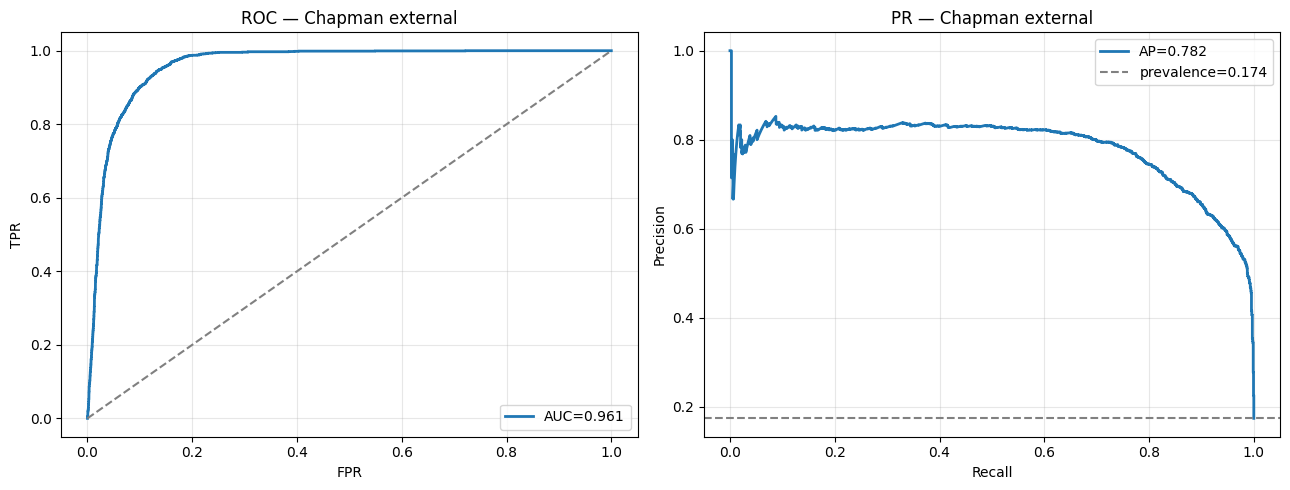

In [ ]:
"""
============================================================================
AF DETECTION — CNN + BiLSTM
Train on PTB-XL (12-lead) -> External test on Chapman-Shaoxing
Single-task (binary AF) version. Fixes the constant-0.507 collapse:
  * balanced sampling so each batch contains real AF positives
  * checkpoint selection on VALIDATION AF-AUC (not the multiclass metric)
  * identical preprocessing/filtering on both datasets (key for transfer)
  * operating threshold chosen on validation (Youden's J), not a blind 0.5
============================================================================
Run top-to-bottom. Set the four paths in CONFIG first.
"""

import os, ast, glob, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from scipy.signal import butter, filtfilt, resample_poly
from math import gcd
from sklearn.metrics import (roc_auc_score, roc_curve, auc as sk_auc,
                             precision_recall_curve, average_precision_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt

# ============================================================================
# CONFIG
# ============================================================================
PTBXL_DIR    = "/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"          # folder containing ptbxl_database.csv + records500/
PTBXL_CSV    = os.path.join(PTBXL_DIR, "ptbxl_database.csv")
CHAPMAN_DIR  = "/kaggle/input/datasets/erarayamorenzomuten/chapmanshaoxing-12lead-ecg-database/WFDB_ChapmanShaoxing"  # root containing the .hea/.dat records
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

FS           = 500          # target sampling rate (Hz)
SIG_LEN      = 5000         # target length (10 s @ 500 Hz)
HP_CUTOFF    = 0.5          # high-pass cutoff (Hz) applied to BOTH datasets
BATCH_SIZE   = 32
EPOCHS       = 35
PATIENCE     = 8
LR           = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 2
SEED         = 42
BEST_PATH    = "af_cnn_bilstm_best.pt"

PTBXL_LEADS  = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]
AF_SNOMED    = {"164889003"}  # atrial fibrillation (SNOMED-CT). Verify for your Chapman copy.

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)


# ============================================================================
# SIGNAL I/O + PREPROCESSING  (identical for both datasets)
# ============================================================================
def read_ptbxl_record(record_base_path):
    """WFDB-free reader for PTB-XL .hea/.dat. Returns (12,T) raw, fs, names."""
    hea_path = record_base_path + ".hea"
    with open(hea_path) as f:
        lines = [ln.strip() for ln in f if ln.strip()]
    first = lines[0].split()
    nsig, fs, n_samples = int(first[1]), int(float(first[2])), int(first[3])
    sig_lines = lines[1:1 + nsig]
    dat_file = sig_lines[0].split()[0]
    dat_path = os.path.join(os.path.dirname(hea_path), dat_file)
    names = [ln.split()[-1] for ln in sig_lines]
    raw = np.fromfile(dat_path, dtype="<i2", count=nsig * n_samples)
    if raw.size != nsig * n_samples:
        n_samples = raw.size // nsig
        raw = raw[:nsig * n_samples]
    sig = raw.reshape(n_samples, nsig).T.astype(np.float32)
    return sig, fs, names


def read_record_any(base_path):
    """Prefer wfdb (handles gain/format/multi-dat); fall back to raw reader."""
    try:
        import wfdb
        rec = wfdb.rdrecord(base_path)
        return rec.p_signal.T.astype(np.float32), int(rec.fs), list(rec.sig_name)
    except Exception:
        return read_ptbxl_record(base_path)


def _canon(name):
    return str(name).upper().replace("LEAD", "").replace(" ", "").strip()


def reorder_leads(sig, sig_names, target=PTBXL_LEADS):
    name_to_row = {_canon(nm): i for i, nm in enumerate(sig_names)}
    missing = [l for l in target if l not in name_to_row]
    if missing:
        raise ValueError(f"Record missing leads {missing}; has {sorted(name_to_row)}")
    return sig[[name_to_row[l] for l in target], :]


_b_hp, _a_hp = butter(3, HP_CUTOFF / (FS / 2.0), btype="highpass")

def preprocess_signal(sig, fs, sig_names):
    """Lead-reorder -> resample to FS -> high-pass -> crop/pad -> per-lead z-score.
    Applied IDENTICALLY to PTB-XL and Chapman so the model sees one distribution."""
    sig = reorder_leads(sig, sig_names).astype(np.float32)
    if int(fs) != int(FS):
        g = gcd(int(fs), int(FS))
        sig = resample_poly(sig, FS // g, fs // g, axis=1).astype(np.float32)
    # high-pass to remove baseline wander (consistent across datasets)
    sig = filtfilt(_b_hp, _a_hp, sig, axis=1).astype(np.float32)
    # crop / pad
    if sig.shape[1] < SIG_LEN:
        sig = np.pad(sig, ((0, 0), (0, SIG_LEN - sig.shape[1])), mode="constant")
    else:
        sig = sig[:, :SIG_LEN]
    # per-lead z-score (affine-invariant -> robust to unit/gain differences)
    mean = sig.mean(axis=1, keepdims=True)
    std = sig.std(axis=1, keepdims=True)
    return ((sig - mean) / (std + 1e-6)).astype(np.float32)


def light_augment(x):
    """Mild train-time augmentation (numpy, (12,T))."""
    if random.random() < 0.5:
        x = x * random.uniform(0.9, 1.1)
    if random.random() < 0.5:
        x = x + np.random.randn(*x.shape).astype(np.float32) * 0.01
    if random.random() < 0.4:
        x = np.roll(x, random.randint(-200, 200), axis=1)
    return x


# ============================================================================
# PTB-XL METADATA, LABELS, OFFICIAL FOLD SPLIT
# ============================================================================
def load_ptbxl_meta():
    df = pd.read_csv(PTBXL_CSV)
    df["scp"] = df["scp_codes"].apply(ast.literal_eval)
    df["y_af"] = df["scp"].apply(lambda d: int("AFIB" in d))
    df["path"] = df["filename_hr"].apply(lambda p: os.path.join(PTBXL_DIR, p))
    train_df = df[df["strat_fold"] <= 8].reset_index(drop=True)
    val_df   = df[df["strat_fold"] == 9].reset_index(drop=True)
    test_df  = df[df["strat_fold"] == 10].reset_index(drop=True)
    for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
        print(f"{name}: n={len(d)}  AF+={d['y_af'].sum()} "
              f"({100*d['y_af'].mean():.1f}%)")
    return train_df, val_df, test_df


class PTBXLAfDataset(Dataset):
    def __init__(self, df, train=False):
        self.df = df
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        sig, fs, names = read_ptbxl_record(row["path"])
        x = preprocess_signal(sig, fs, names)
        if self.train:
            x = light_augment(x)
        return torch.from_numpy(x.copy()), torch.tensor(float(row["y_af"]))


def make_loaders(train_df, val_df, test_df):
    train_ds = PTBXLAfDataset(train_df, train=True)
    val_ds   = PTBXLAfDataset(val_df,   train=False)
    test_ds  = PTBXLAfDataset(test_df,  train=False)

    # balanced sampler: every batch sees real AF positives
    labels = train_df["y_af"].values.astype(int)
    class_count = np.bincount(labels, minlength=2).astype(np.float64)
    w_per_class = 1.0 / np.clip(class_count, 1, None)
    sample_w = w_per_class[labels]
    sampler = WeightedRandomSampler(torch.DoubleTensor(sample_w),
                                    num_samples=len(sample_w), replacement=True)

    pin = (DEVICE == "cuda")
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=pin, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=pin)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=pin)
    return train_loader, val_loader, test_loader


# ============================================================================
# MODEL: CNN + BiLSTM (single AF head)
# ============================================================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k, s, p, drop=0.15):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, k, s, p, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)
        self.act = nn.GELU()
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        return self.drop(self.act(self.bn(self.conv(x))))


class AFNet(nn.Module):
    def __init__(self, in_leads=12, lstm_hidden=128, lstm_layers=2, dropout=0.4):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(in_leads, 64, 9, 2, 4),
            ConvBlock(64, 64, 7, 1, 3),
            nn.MaxPool1d(2),
            ConvBlock(64, 128, 7, 2, 3),
            ConvBlock(128, 128, 5, 1, 2),
            nn.MaxPool1d(2),
            ConvBlock(128, 192, 5, 2, 2),
            ConvBlock(192, 192, 3, 1, 1),
        )
        self.lstm = nn.LSTM(192, lstm_hidden, lstm_layers, batch_first=True,
                            dropout=dropout if lstm_layers > 1 else 0.0,
                            bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(2 * lstm_hidden, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.cnn(x).transpose(1, 2)   # (B, T', C)
        out, _ = self.lstm(x)             # (B, T', 2H)
        feat = out.mean(dim=1)            # (B, 2H)
        return self.head(feat).squeeze(-1)  # (B,)


# ============================================================================
# TRAIN / EVAL
# ============================================================================
@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    ps, ys = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        logit = model(x)
        ps.append(torch.sigmoid(logit).cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(ps), np.concatenate(ys).astype(int)


def train_model(model, train_loader, val_loader):
    model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()      # sampler already balances classes
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                           factor=0.5, patience=3)
    use_amp = (DEVICE == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_auc, bad = -1.0, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE).float()
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logit = model(x)
                loss = criterion(logit, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            running += loss.item() * x.size(0)

        probs, ys = predict_probs(model, val_loader)
        val_auc = roc_auc_score(ys, probs) if len(np.unique(ys)) > 1 else float("nan")
        spread = probs.std()
        scheduler.step(val_auc)
        print(f"[{epoch:02d}] train_loss={running/len(train_loader.dataset):.4f} "
              f"| val_AUC={val_auc:.4f} | prob_std={spread:.4f}")

        if val_auc > best_auc + 1e-4:
            best_auc = val_auc
            torch.save(model.state_dict(), BEST_PATH)
            bad = 0
            print(f"   saved best (AUC={best_auc:.4f})")
        else:
            bad += 1
            if bad >= PATIENCE:
                print("early stopping"); break

    model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
    print(f"best val AUC = {best_auc:.4f}")
    return model


def pick_threshold(probs, ys):
    """Youden's J on validation."""
    fpr, tpr, thr = roc_curve(ys, probs)
    return float(thr[np.argmax(tpr - fpr)])


def report(probs, ys, threshold, name):
    preds = (probs >= threshold).astype(int)
    auc_v = roc_auc_score(ys, probs) if len(np.unique(ys)) > 1 else float("nan")
    print(f"\n===== {name} (thr={threshold:.3f}) =====")
    print(f"AUC = {auc_v:.4f}")
    print(classification_report(ys, preds, target_names=["non-AF", "AF"],
                                digits=3, zero_division=0))
    return auc_v


def plot_roc_pr(probs, ys, name):
    fpr, tpr, _ = roc_curve(ys, probs); roc_auc = sk_auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(ys, probs); ap = average_precision_score(ys, probs)
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].plot(fpr, tpr, lw=2, label=f"AUC={roc_auc:.3f}")
    ax[0].plot([0, 1], [0, 1], "--", color="gray")
    ax[0].set_title(f"ROC — {name}"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
    ax[0].legend(loc="lower right"); ax[0].grid(alpha=0.3)
    ax[1].plot(rec, prec, lw=2, label=f"AP={ap:.3f}")
    ax[1].axhline(ys.mean(), ls="--", color="gray", label=f"prevalence={ys.mean():.3f}")
    ax[1].set_title(f"PR — {name}"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
    ax[1].legend(loc="upper right"); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


# ============================================================================
# CHAPMAN-SHAOXING EXTERNAL TEST
# ============================================================================
def afib_from_header(hea_path):
    with open(hea_path) as f:
        for ln in f:
            if ln.lower().replace(" ", "").startswith("#dx"):
                codes = ln.split(":", 1)[1].strip().replace(" ", "").split(",")
                return int(any(c in AF_SNOMED for c in codes))
    return None


def build_chapman_index():
    records, labels = [], []
    for hea in sorted(glob.glob(os.path.join(CHAPMAN_DIR, "**", "*.hea"), recursive=True)):
        lab = afib_from_header(hea)
        if lab is not None:
            records.append(hea[:-4]); labels.append(lab)
    print(f"Chapman: {len(records)} records, {sum(labels)} AF+ "
          f"({100*np.mean(labels):.1f}%)" if records else "Chapman: 0 records found")
    return records, np.array(labels, dtype=int)


@torch.no_grad()
def evaluate_chapman(model, records, labels, batch=32):
    model.eval()
    probs, buf = [], []
    def flush(b):
        if not b: return []
        xb = torch.from_numpy(np.stack(b)).float().to(DEVICE)
        return torch.sigmoid(model(xb)).view(-1).cpu().numpy().tolist()
    for k, rb in enumerate(records):
        sig, fs, names = read_record_any(rb)
        buf.append(preprocess_signal(sig, fs, names))
        if len(buf) == batch:
            probs += flush(buf); buf = []
        if (k + 1) % 1000 == 0:
            print(f"  {k+1}/{len(records)}")
    probs += flush(buf)
    return np.asarray(probs), np.asarray(labels, dtype=int)


# ============================================================================
# MAIN
# ============================================================================
if __name__ == "__main__":
    print("DEVICE:", DEVICE)

    train_df, val_df, test_df = load_ptbxl_meta()
    train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df)

    model = AFNet().to(DEVICE)
    model = train_model(model, train_loader, val_loader)

    # threshold from validation
    val_probs, val_ys = predict_probs(model, val_loader)
    thr = pick_threshold(val_probs, val_ys)
    print(f"\nOperating threshold (Youden's J on val): {thr:.3f}")

    # internal test (PTB-XL)
    test_probs, test_ys = predict_probs(model, test_loader)
    report(test_probs, test_ys, thr, "PTB-XL TEST (internal)")
    plot_roc_pr(test_probs, test_ys, "PTB-XL test")

    # external test (Chapman-Shaoxing) — model frozen, same preprocessing
    ch_records, ch_labels = build_chapman_index()
    if len(ch_records):
        ch_probs, ch_ys = evaluate_chapman(model, ch_records, ch_labels)
        report(ch_probs, ch_ys, thr, "CHAPMAN (external, val-threshold)")
        report(ch_probs, ch_ys, 0.5, "CHAPMAN (external, 0.5)")
        plot_roc_pr(ch_probs, ch_ys, "Chapman external")

case index: 525 | true: 1 | prob: 0.999

[TP] P(AF)=0.999
Top leads: ['V1', 'I', 'V5']
Top windows: ['9.10-9.60s', '2.83-3.33s', '6.60-7.10s']

Explanation:
 The model predicts atrial fibrillation with high confidence (P(AF) = 0.999). The strongest lead-level evidence is in V1, I, V5, and the most influential time regions are around 9.10-9.60s, 2.83-3.33s. These regions were consistently highlighted by gradient-based (Integrated Gradients, Grad-CAM) and perturbation-based (occlusion) explainability methods.


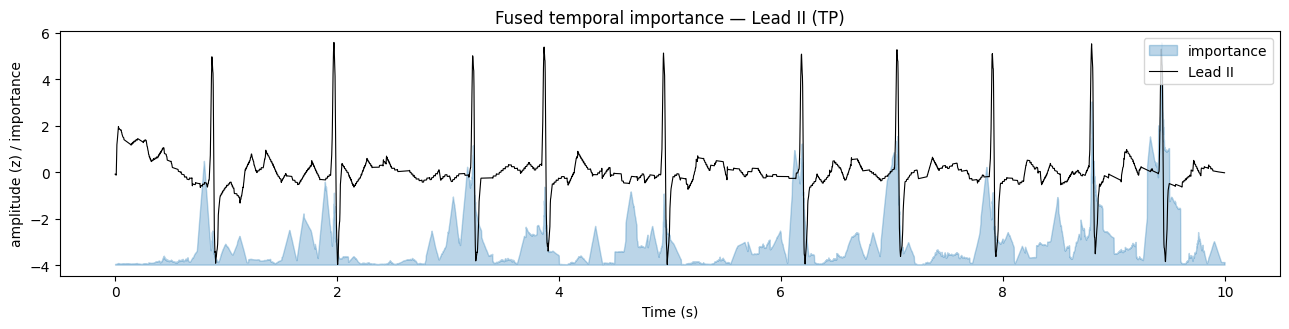

In [ ]:
"""
============================================================================
ADD-ON for af_cnn_bilstm_train_test.py  (run AFTER training `model`)
  A) Explainable AI for single-task AFNet (Grad-CAM, Integrated Gradients,
     Occlusion) — no wrapper needed; the model returns the AF logit directly
  B) Template explanation generator — fuses the three methods into text
----------------------------------------------------------------------------
Requires from the main script (already in memory):
  model, AFNet, DEVICE, FS, PTBXL_LEADS, PTBXLAfDataset, test_df
============================================================================
"""
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

LEAD_NAMES = PTBXL_LEADS


# ============================================================================
# A) EXPLAINABLE AI for single-task AFNet
# ============================================================================
def af_logit_prob(model, x):
    model.eval()
    with torch.no_grad():
        logit = model(x.to(DEVICE))
    return float(logit.item()), float(torch.sigmoid(logit).item())

def gradcam(model, x, target_layer=None):
    """Grad-CAM over the last CNN conv -> temporal importance (T,)."""
    if target_layer is None:
        target_layer = model.cnn[-1].conv          # the 192->192 k=3 conv
    store = {}
    def fhook(m, i, o):
        store["act"] = o
        if o.requires_grad:
            o.register_hook(lambda g: store.__setitem__("grad", g))
    h = target_layer.register_forward_hook(fhook)
    try:
        model.eval()
        xin = x.clone().to(DEVICE).requires_grad_(True)
        with torch.enable_grad(), torch.backends.cudnn.flags(enabled=False):
            model.zero_grad(set_to_none=True)
            logit = model(xin)
            logit[0].backward()
    finally:
        h.remove()
    act, grad = store["act"], store["grad"]          # (1,C,T')
    w = grad.mean(dim=2, keepdim=True)               # (1,C,1)
    cam = torch.relu((w * act).sum(dim=1, keepdim=True))      # (1,1,T')
    cam = F.interpolate(cam, size=x.shape[-1], mode="linear", align_corners=False)
    return cam.squeeze().detach().cpu().numpy()      # (T,)

def integrated_gradients(model, x, baseline=None, steps=32):
    """IG per-sample, per-lead attribution -> (12, T)."""
    model.eval()
    x = x.to(DEVICE)
    if baseline is None:
        baseline = torch.zeros_like(x)
    total = torch.zeros_like(x)
    with torch.backends.cudnn.flags(enabled=False):
        for a in np.linspace(1.0/steps, 1.0, steps):
            xi = (baseline + a * (x - baseline)).clone().requires_grad_(True)
            model.zero_grad(set_to_none=True)
            with torch.enable_grad():
                logit = model(xi); logit[0].backward()
            total = total + xi.grad
    ig = (x - baseline) * (total / steps)
    return ig.squeeze(0).detach().cpu().numpy()      # (12, T)

@torch.no_grad()
def occlusion(model, x, win=100, stride=50):
    """Slide a zeroed window; positive value = removing it lowers AF prob -> (T,)."""
    model.eval()
    x = x.to(DEVICE)
    base = float(torch.sigmoid(model(x)).item())
    T = x.shape[-1]
    imp, cnt = np.zeros(T), np.zeros(T)
    for s in range(0, T, stride):
        e = min(s + win, T)
        xo = x.clone(); xo[..., s:e] = 0.0
        p = float(torch.sigmoid(model(xo)).item())
        imp[s:e] += (base - p); cnt[s:e] += 1
    cnt[cnt == 0] = 1
    return imp / cnt

def safe_norm(v):
    v = np.abs(np.asarray(v, dtype=float)); m = v.max()
    return v / m if m > 0 else v

def get_top_time_windows(score, fs=FS, window_sec=0.5, top_k=3):
    w = max(1, int(window_sec * fs))
    s = score.copy().astype(float)
    out = []
    for _ in range(top_k):
        csum = np.convolve(s, np.ones(w), "valid")
        if csum.size == 0: break
        i = int(np.argmax(csum))
        out.append({"start_sec": i / fs, "end_sec": (i + w) / fs,
                    "score": float(csum[i] / w)})
        s[max(0, i):i + w] = -np.inf
    return out

def get_case_example(dataset, model, kind="TP", threshold=0.5, prefer_confident=True):
    """Find one example of TP/FP/FN/TN. If prefer_confident, return the most
    confident match (best for clean attribution figures)."""
    model.eval()
    cand = []
    key = {(1,1):"TP", (1,0):"FP", (0,1):"FN", (0,0):"TN"}
    for i in range(len(dataset)):
        x, y = dataset[i]
        with torch.no_grad():
            p = float(torch.sigmoid(model(x.unsqueeze(0).to(DEVICE))).item())
        if key[(int(p >= threshold), int(y.item()))] == kind:
            cand.append((i, p))
            if not prefer_confident:
                return x.unsqueeze(0), int(y.item()), p, i
    if not cand:
        return None
    i, p = (max(cand, key=lambda t: t[1]) if kind in ("TP", "FP")
            else min(cand, key=lambda t: t[1]))
    x, y = dataset[i]
    return x.unsqueeze(0), int(y.item()), p, i

def plot_signal_with_attr(sig_1d, attr_1d, lead_name, fs=FS, title=""):
    t = np.arange(len(sig_1d)) / fs
    a = safe_norm(attr_1d)
    rng = (sig_1d.max() - sig_1d.min()) or 1.0
    plt.figure(figsize=(13, 3.4))
    plt.fill_between(t, sig_1d.min(), sig_1d.min() + a * rng,
                     color="tab:blue", alpha=0.30, label="importance")
    plt.plot(t, sig_1d, color="black", lw=0.8, label=f"Lead {lead_name}")
    plt.xlabel("Time (s)"); plt.ylabel("amplitude (z) / importance")
    plt.title(title); plt.legend(loc="upper right"); plt.tight_layout(); plt.show()


# ============================================================================
# B) TEMPLATE EXPLANATION GENERATOR
# ============================================================================
def explain_af(model, x, fs=FS, case_kind="", lead_to_plot="II", make_plot=True):
    logit, prob = af_logit_prob(model, x)

    cam = gradcam(model, x)                    # (T,)
    ig  = integrated_gradients(model, x)       # (12, T)
    occ = occlusion(model, x)                  # (T,)

    lead_scores = np.abs(ig).mean(axis=1)      # (12,)
    top_leads = [LEAD_NAMES[i] for i in np.argsort(-lead_scores)[:3]]

    time_score = (safe_norm(np.abs(ig).mean(axis=0)) +
                  safe_norm(cam) +
                  safe_norm(occ)) / 3.0
    windows = get_top_time_windows(time_score, fs=fs, window_sec=0.5, top_k=3)

    summary = {"af_probability": prob, "af_logit": logit,
               "top_leads": top_leads, "top_windows": windows,
               "lead_scores": lead_scores, "time_score": time_score,
               "cam": cam, "ig": ig, "occ": occ}

    conf = ("high confidence" if prob >= 0.80 else
            "moderate confidence" if prob >= 0.50 else "low confidence")
    not_txt = "" if prob >= 0.50 else "not "
    win_txt = ", ".join(f"{w['start_sec']:.2f}-{w['end_sec']:.2f}s" for w in windows[:2])
    text = (f"The model predicts {not_txt}atrial fibrillation with {conf} "
            f"(P(AF) = {prob:.3f}). The strongest lead-level evidence is in "
            f"{', '.join(top_leads)}, and the most influential time regions are "
            f"around {win_txt}. These regions were consistently highlighted by "
            f"gradient-based (Integrated Gradients, Grad-CAM) and perturbation-based "
            f"(occlusion) explainability methods.")

    print(f"\n[{case_kind}] P(AF)={prob:.3f}")
    print("Top leads:", top_leads)
    print("Top windows:", [f"{w['start_sec']:.2f}-{w['end_sec']:.2f}s" for w in windows])
    print("\nExplanation:\n", text)

    if make_plot:
        li = LEAD_NAMES.index(lead_to_plot) if lead_to_plot in LEAD_NAMES else 1
        sig = x.squeeze(0).cpu().numpy()[li]
        plot_signal_with_attr(sig, time_score, lead_to_plot, fs=fs,
                              title=f"Fused temporal importance — Lead {lead_to_plot} ({case_kind})")
    return summary, text
# ---- example run on a confident PTB-XL test case ----
test_ds = PTBXLAfDataset(test_df, train=False)
picked = get_case_example(test_ds, model, kind="TP")

if picked:
    x_case, y_true, p, idx = picked
    print("case index:", idx, "| true:", y_true, "| prob:", round(p, 3))
    summary, text = explain_af(model, x_case, case_kind="TP", lead_to_plot="II")



case index: 525 | true: 1 | prob: 0.999

[TP] P(AF)=0.999
Top leads: ['V1', 'I', 'V5']
Top windows: ['8.10-8.60s', '9.10-9.60s', '7.60-8.10s']

Explanation:
 The model predicts atrial fibrillation with high confidence (P(AF) = 0.999). The strongest lead-level evidence is in V1, I, V5, and the most influential time regions are around 8.10-8.60s, 9.10-9.60s. These regions were consistently highlighted by gradient-based (Integrated Gradients, Grad-CAM) and perturbation-based (occlusion, feature ablation) explainability methods.


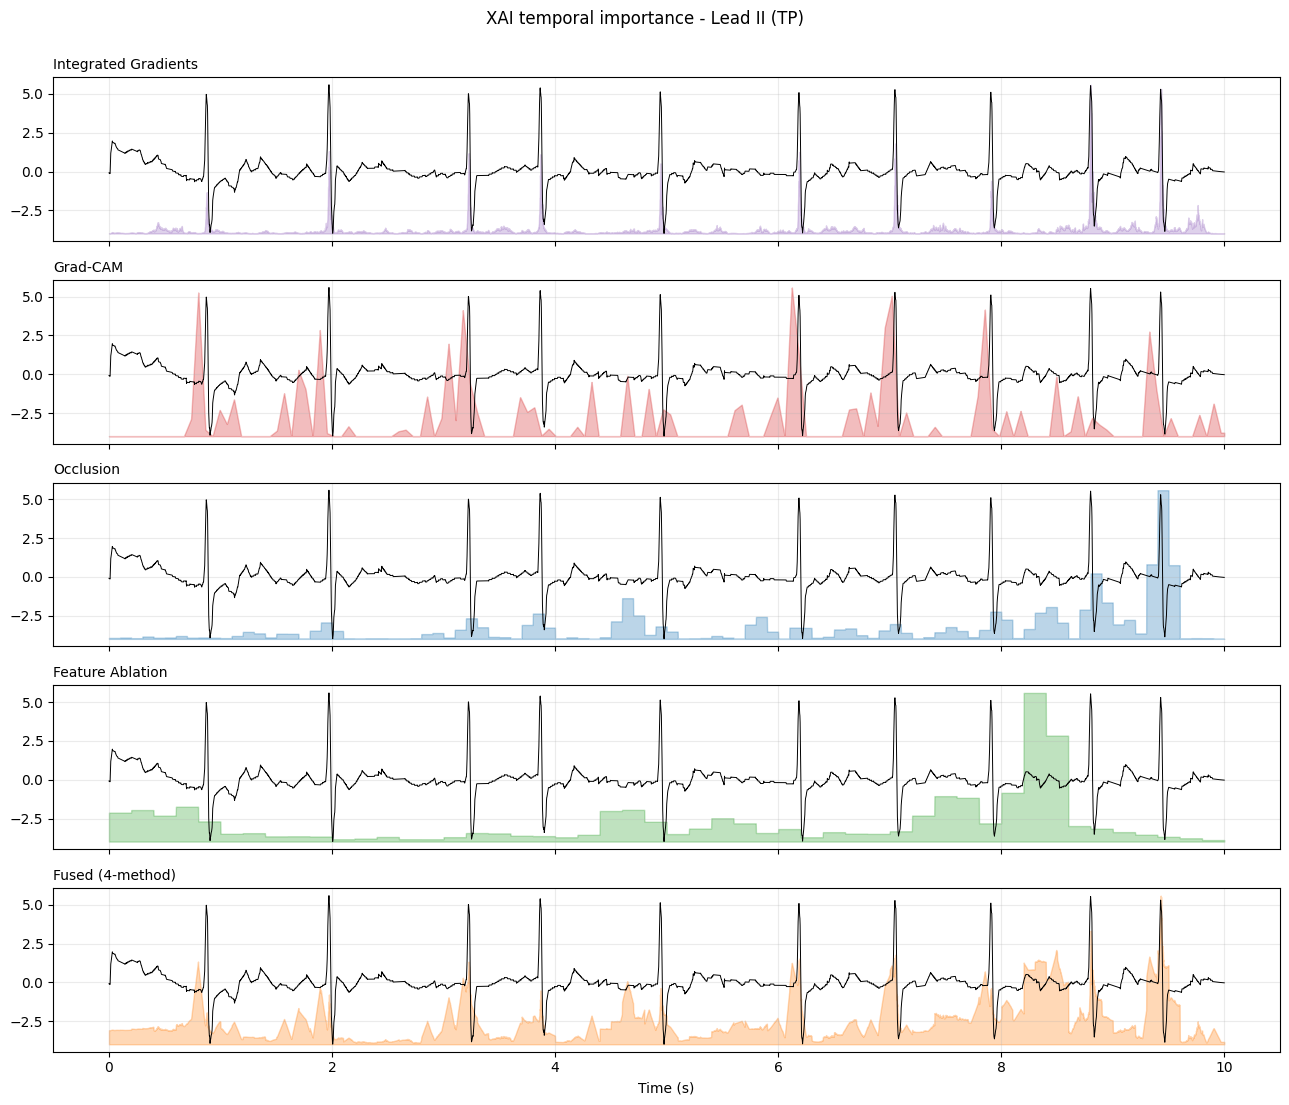

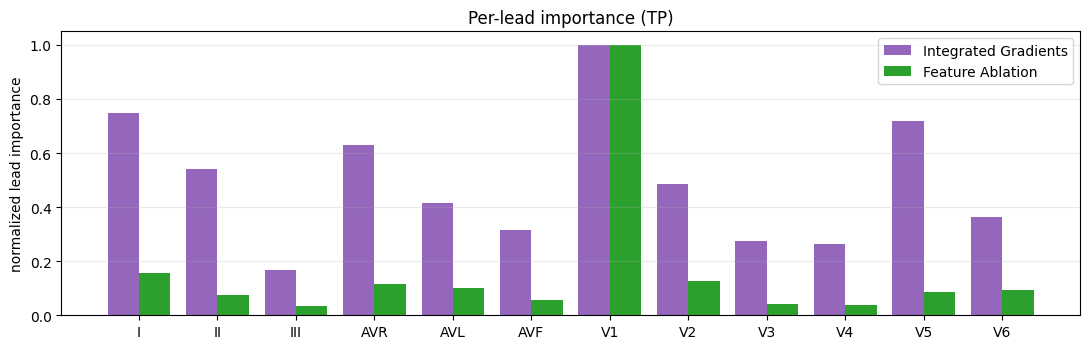

In [ ]:
"""
============================================================================
ADD-ON for af_cnn_bilstm_train_test.py  (run AFTER training `model`)
  A) Explainable AI for single-task AFNet:
       Integrated Gradients, Grad-CAM, Occlusion, Feature Ablation
  B) Per-method plots (one panel each) + per-lead importance bars
  C) Template explanation generator (fuses all four methods)
----------------------------------------------------------------------------
Requires from the main script (already in memory):
  model, AFNet, DEVICE, FS, PTBXL_LEADS, PTBXLAfDataset, test_df
============================================================================
"""
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

LEAD_NAMES = PTBXL_LEADS


# ============================================================================
# A) XAI METHODS
# ============================================================================
def af_logit_prob(model, x):
    model.eval()
    with torch.no_grad():
        logit = model(x.to(DEVICE))
    return float(logit.item()), float(torch.sigmoid(logit).item())

def gradcam(model, x, target_layer=None):
    """Grad-CAM over the last CNN conv -> temporal importance (T,)."""
    if target_layer is None:
        target_layer = model.cnn[-1].conv
    store = {}
    def fhook(m, i, o):
        store["act"] = o
        if o.requires_grad:
            o.register_hook(lambda g: store.__setitem__("grad", g))
    h = target_layer.register_forward_hook(fhook)
    try:
        model.eval()
        xin = x.clone().to(DEVICE).requires_grad_(True)
        with torch.enable_grad(), torch.backends.cudnn.flags(enabled=False):
            model.zero_grad(set_to_none=True)
            model(xin)[0].backward()
    finally:
        h.remove()
    act, grad = store["act"], store["grad"]                  # (1,C,T')
    w = grad.mean(dim=2, keepdim=True)
    cam = torch.relu((w * act).sum(dim=1, keepdim=True))      # (1,1,T')
    cam = F.interpolate(cam, size=x.shape[-1], mode="linear", align_corners=False)
    return cam.squeeze().detach().cpu().numpy()              # (T,)

def integrated_gradients(model, x, baseline=None, steps=32):
    """IG per-lead attribution -> (12, T)."""
    model.eval()
    x = x.to(DEVICE)
    if baseline is None:
        baseline = torch.zeros_like(x)
    total = torch.zeros_like(x)
    with torch.backends.cudnn.flags(enabled=False):
        for a in np.linspace(1.0/steps, 1.0, steps):
            xi = (baseline + a * (x - baseline)).clone().requires_grad_(True)
            model.zero_grad(set_to_none=True)
            with torch.enable_grad():
                model(xi)[0].backward()
            total = total + xi.grad
    ig = (x - baseline) * (total / steps)
    return ig.squeeze(0).detach().cpu().numpy()              # (12, T)

@torch.no_grad()
def occlusion(model, x, win=100, stride=50):
    """Zero a temporal window across ALL leads -> (T,). +ve = removing lowers P(AF)."""
    model.eval()
    x = x.to(DEVICE)
    base = float(torch.sigmoid(model(x)).item())
    T = x.shape[-1]
    imp, cnt = np.zeros(T), np.zeros(T)
    for s in range(0, T, stride):
        e = min(s + win, T)
        xo = x.clone(); xo[..., s:e] = 0.0
        p = float(torch.sigmoid(model(xo)).item())
        imp[s:e] += (base - p); cnt[s:e] += 1
    cnt[cnt == 0] = 1
    return imp / cnt

@torch.no_grad()
def feature_ablation(model, x, win=200, stride=100):
    """Zero ONE lead's window at a time -> (12, T). Per-lead, per-time importance."""
    model.eval()
    x = x.to(DEVICE)
    base = float(torch.sigmoid(model(x)).item())
    C, T = x.shape[1], x.shape[-1]
    imp, cnt = np.zeros((C, T)), np.zeros((C, T))
    for c in range(C):
        for s in range(0, T, stride):
            e = min(s + win, T)
            xo = x.clone(); xo[:, c, s:e] = 0.0
            p = float(torch.sigmoid(model(xo)).item())
            imp[c, s:e] += (base - p); cnt[c, s:e] += 1
    cnt[cnt == 0] = 1
    return imp / cnt                                          # (12, T)


# ============================================================================
# helpers
# ============================================================================
def safe_norm(v):
    v = np.abs(np.asarray(v, dtype=float)); m = v.max()
    return v / m if m > 0 else v

def get_top_time_windows(score, fs=FS, window_sec=0.5, top_k=3):
    w = max(1, int(window_sec * fs))
    s = score.copy().astype(float); out = []
    for _ in range(top_k):
        csum = np.convolve(s, np.ones(w), "valid")
        if csum.size == 0: break
        i = int(np.argmax(csum))
        out.append({"start_sec": i / fs, "end_sec": (i + w) / fs,
                    "score": float(csum[i] / w)})
        s[max(0, i):i + w] = -np.inf
    return out

def get_case_example(dataset, model, kind="TP", threshold=0.5, prefer_confident=True):
    model.eval()
    cand, key = [], {(1,1):"TP", (1,0):"FP", (0,1):"FN", (0,0):"TN"}
    for i in range(len(dataset)):
        x, y = dataset[i]
        with torch.no_grad():
            p = float(torch.sigmoid(model(x.unsqueeze(0).to(DEVICE))).item())
        if key[(int(p >= threshold), int(y.item()))] == kind:
            cand.append((i, p))
            if not prefer_confident:
                return x.unsqueeze(0), int(y.item()), p, i
    if not cand:
        return None
    i, p = (max(cand, key=lambda t: t[1]) if kind in ("TP", "FP")
            else min(cand, key=lambda t: t[1]))
    x, y = dataset[i]
    return x.unsqueeze(0), int(y.item()), p, i


# ============================================================================
# B) PLOTS — one panel per method
# ============================================================================
def _overlay(ax, sig, attr, fs, color, title):
    t = np.arange(len(sig)) / fs
    a = safe_norm(attr)
    rng = (sig.max() - sig.min()) or 1.0
    ax.fill_between(t, sig.min(), sig.min() + a * rng, color=color, alpha=0.30)
    ax.plot(t, sig, color="black", lw=0.7)
    ax.set_title(title, fontsize=10, loc="left")
    ax.grid(alpha=0.25)

def plot_all_methods(arrays, sig, lead_to_plot="II", fs=FS, case_kind=""):
    """Plots IG / Grad-CAM / Occlusion / Feature Ablation / Fused as stacked
    panels, plus a per-lead importance bar chart."""
    ig, cam, occ, fab = arrays["ig"], arrays["cam"], arrays["occ"], arrays["fab"]
    ig_t, fab_t = np.abs(ig).mean(axis=0), np.abs(fab).mean(axis=0)
    fused = (safe_norm(ig_t) + safe_norm(cam) + safe_norm(occ) + safe_norm(fab_t)) / 4.0

    panels = [("Integrated Gradients", ig_t, "tab:purple"),
              ("Grad-CAM",            cam,   "tab:red"),
              ("Occlusion",           occ,   "tab:blue"),
              ("Feature Ablation",    fab_t, "tab:green"),
              ("Fused (4-method)",    fused, "tab:orange")]

    fig, axes = plt.subplots(len(panels), 1, figsize=(13, 11), sharex=True)
    for ax, (name, attr, color) in zip(axes, panels):
        _overlay(ax, sig, attr, fs, color, name)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"XAI temporal importance - Lead {lead_to_plot} ({case_kind})", y=1.00)
    plt.tight_layout(); plt.show()

    ig_l, fab_l = safe_norm(np.abs(ig).mean(axis=1)), safe_norm(np.abs(fab).mean(axis=1))
    xp, w = np.arange(len(LEAD_NAMES)), 0.4
    plt.figure(figsize=(11, 3.6))
    plt.bar(xp - w/2, ig_l, w, label="Integrated Gradients", color="tab:purple")
    plt.bar(xp + w/2, fab_l, w, label="Feature Ablation", color="tab:green")
    plt.xticks(xp, LEAD_NAMES); plt.ylabel("normalized lead importance")
    plt.title(f"Per-lead importance ({case_kind})")
    plt.legend(); plt.grid(alpha=0.25, axis="y"); plt.tight_layout(); plt.show()


# ============================================================================
# C) COMPUTE + TEMPLATE EXPLANATION
# ============================================================================
def compute_xai(model, x):
    return {"ig":  integrated_gradients(model, x),
            "cam": gradcam(model, x),
            "occ": occlusion(model, x),
            "fab": feature_ablation(model, x)}

def explain_af(model, x, fs=FS, case_kind="", lead_to_plot="II", make_plot=True):
    logit, prob = af_logit_prob(model, x)
    A = compute_xai(model, x)
    ig, cam, occ, fab = A["ig"], A["cam"], A["occ"], A["fab"]

    lead_score = (safe_norm(np.abs(ig).mean(axis=1)) +
                  safe_norm(np.abs(fab).mean(axis=1))) / 2.0
    top_leads = [LEAD_NAMES[i] for i in np.argsort(-lead_score)[:3]]

    time_score = (safe_norm(np.abs(ig).mean(axis=0)) + safe_norm(cam) +
                  safe_norm(occ) + safe_norm(np.abs(fab).mean(axis=0))) / 4.0
    windows = get_top_time_windows(time_score, fs=fs, window_sec=0.5, top_k=3)

    conf = ("high confidence" if prob >= 0.80 else
            "moderate confidence" if prob >= 0.50 else "low confidence")
    not_txt = "" if prob >= 0.50 else "not "
    win_txt = ", ".join(f"{w['start_sec']:.2f}-{w['end_sec']:.2f}s" for w in windows[:2])
    text = (f"The model predicts {not_txt}atrial fibrillation with {conf} "
            f"(P(AF) = {prob:.3f}). The strongest lead-level evidence is in "
            f"{', '.join(top_leads)}, and the most influential time regions are "
            f"around {win_txt}. These regions were consistently highlighted by "
            f"gradient-based (Integrated Gradients, Grad-CAM) and perturbation-based "
            f"(occlusion, feature ablation) explainability methods.")

    print(f"\n[{case_kind}] P(AF)={prob:.3f}")
    print("Top leads:", top_leads)
    print("Top windows:", [f"{w['start_sec']:.2f}-{w['end_sec']:.2f}s" for w in windows])
    print("\nExplanation:\n", text)

    if make_plot:
        li = LEAD_NAMES.index(lead_to_plot) if lead_to_plot in LEAD_NAMES else 1
        sig = x.squeeze(0).cpu().numpy()[li]
        plot_all_methods(A, sig, lead_to_plot=lead_to_plot, fs=fs, case_kind=case_kind)

    summary = {"af_probability": prob, "af_logit": logit, "top_leads": top_leads,
               "top_windows": windows, "time_score": time_score, **A}
    return summary, text


# ---- example run on a confident PTB-XL test case ----
test_ds = PTBXLAfDataset(test_df, train=False)
picked = get_case_example(test_ds, model, kind="TP")

if picked:
    x_case, y_true, p, idx = picked
    print("case index:", idx, "| true:", y_true, "| prob:", round(p, 3))
    summary, text = explain_af(model, x_case, case_kind="TP", lead_to_plot="II")


/tmp/ipykernel_57/4163935694.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(probs, frac))


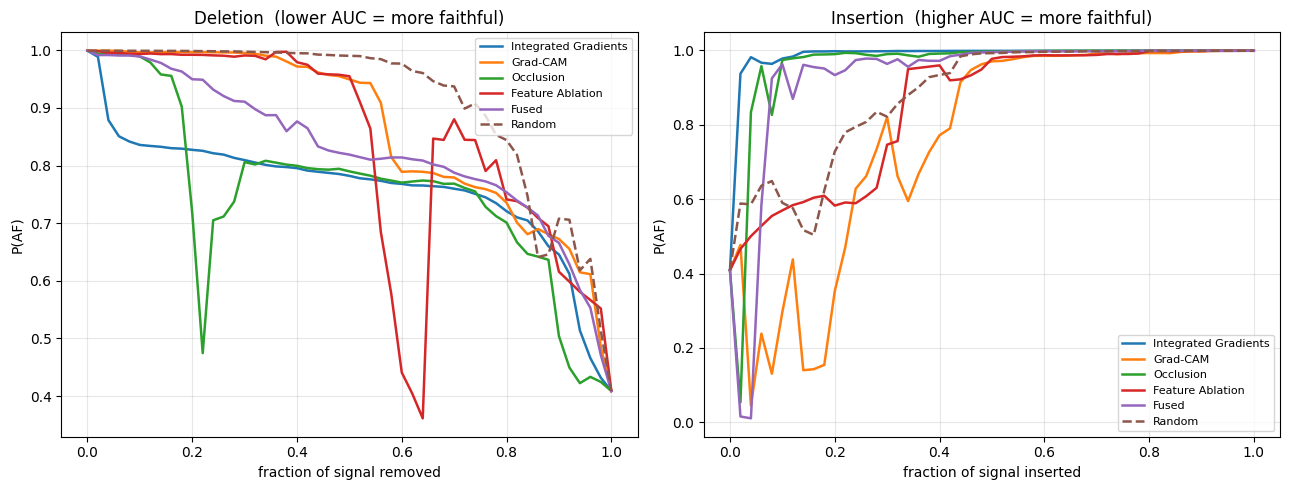

method                  deletion_AUC(↓)  insertion_AUC(↑)
Integrated Gradients             0.7619            0.9892
Grad-CAM                         0.8655            0.7643
Occlusion                        0.7565            0.9625
Feature Ablation                 0.8396            0.8509
Fused                            0.8276            0.9296
Random                           0.9142            0.8817

Mean faithfulness over 30 cases:
method                  deletion_AUC(↓)  insertion_AUC(↑)
Integrated Gradients             0.7119            0.8907
Grad-CAM                         0.7604            0.7150
Occlusion                        0.5696            0.8678
Fused                            0.7209            0.8250
Random                           0.7216            0.7247
Fitted temperature T = 1.962
Val ECE: before=0.0189  after=0.0124


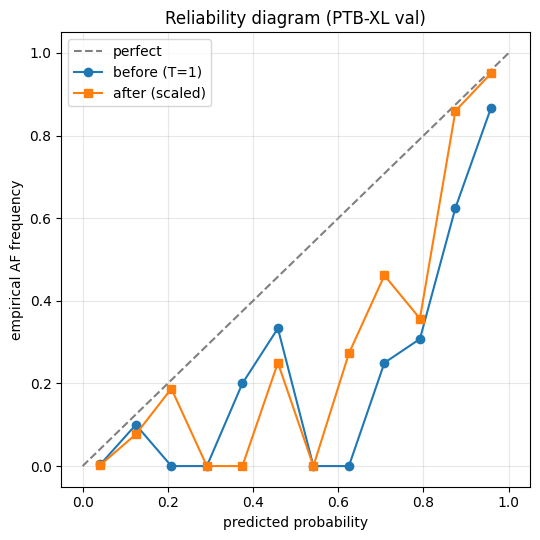


Val-tuned threshold (calibrated): 0.156
Chapman ECE: before=0.1013  after=0.0748
  uncalibrated @0.5        acc=0.8816 bal_acc=0.9053 AUC=0.9610
  calibrated   @0.5        acc=0.8816 bal_acc=0.9053 AUC=0.9610
  calibrated   @val-thr    acc=0.8579 bal_acc=0.9034 AUC=0.9610


In [ ]:
"""
============================================================================
ADD-ON 2 for af_cnn_bilstm_train_test.py  (+ af_xai_explain.py)
  A) FAITHFULNESS — deletion / insertion curves (RISE-style)
     Validates that the attributions actually drive the prediction.
  B) CALIBRATION — temperature scaling fit on PTB-XL validation,
     applied to Chapman. Gives defensible accuracy at a sensible threshold.
----------------------------------------------------------------------------
Requires in memory:
  model, DEVICE, FS, PTBXL_LEADS, PTBXLAfDataset, val_loader, test_df
  compute_xai, safe_norm                (from af_xai_explain.py)
  ch_probs, ch_ys                       (from the Chapman evaluation)
============================================================================
"""
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from sklearn.metrics import (log_loss, roc_auc_score, roc_curve,
                             accuracy_score, balanced_accuracy_score)


# ============================================================================
# A) FAITHFULNESS: deletion / insertion
# ============================================================================
@torch.no_grad()
def _prob(model, x):
    return float(torch.sigmoid(model(x.to(DEVICE))).item())

@torch.no_grad()
def deletion_insertion(model, x, importance, steps=50, baseline=None):
    """Return (fraction, deletion_probs, insertion_probs).
    Deletion: remove most-important time points first  -> faithful = fast drop.
    Insertion: add most-important time points first     -> faithful = fast rise."""
    model.eval()
    x = x.to(DEVICE)
    if baseline is None:
        baseline = torch.zeros_like(x)
    T = x.shape[-1]
    order = np.argsort(-np.asarray(importance, dtype=float))   # important first
    chunks = np.array_split(order, steps)

    xd = x.clone(); xi = baseline.clone()
    frac = [0.0]; dp = [_prob(model, xd)]; ip = [_prob(model, xi)]
    removed = 0
    for ch in chunks:
        xd[..., ch] = baseline[..., ch]      # delete (zero out) top region
        xi[..., ch] = x[..., ch]             # insert original top region
        removed += len(ch)
        frac.append(removed / T)
        dp.append(_prob(model, xd))
        ip.append(_prob(model, xi))
    return np.array(frac), np.array(dp), np.array(ip)

def _auc(frac, probs):
    return float(np.trapz(probs, frac))

def plot_faithfulness(model, x, arrays, steps=50, seed=0):
    """Single example: deletion + insertion for each method vs a random control."""
    fab_t = np.abs(arrays["fab"]).mean(0)
    ig_t  = np.abs(arrays["ig"]).mean(0)
    fused = (safe_norm(ig_t) + safe_norm(arrays["cam"]) +
             safe_norm(arrays["occ"]) + safe_norm(fab_t)) / 4.0
    methods = {"Integrated Gradients": ig_t, "Grad-CAM": arrays["cam"],
               "Occlusion": arrays["occ"], "Feature Ablation": fab_t,
               "Fused": fused}
    rng = np.random.RandomState(seed)
    methods["Random"] = rng.rand(len(ig_t))

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    rows = []
    for name, imp in methods.items():
        frac, dp, ip = deletion_insertion(model, x, imp, steps=steps)
        ls = "--" if name == "Random" else "-"
        ax[0].plot(frac, dp, ls, lw=1.8, label=name)
        ax[1].plot(frac, ip, ls, lw=1.8, label=name)
        rows.append((name, _auc(frac, dp), _auc(frac, ip)))
    ax[0].set_title("Deletion  (lower AUC = more faithful)")
    ax[0].set_xlabel("fraction of signal removed"); ax[0].set_ylabel("P(AF)")
    ax[1].set_title("Insertion  (higher AUC = more faithful)")
    ax[1].set_xlabel("fraction of signal inserted"); ax[1].set_ylabel("P(AF)")
    for a in ax: a.grid(alpha=.3); a.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    print(f"{'method':22s} {'deletion_AUC(↓)':>16s} {'insertion_AUC(↑)':>17s}")
    for name, da, ia in rows:
        print(f"{name:22s} {da:16.4f} {ia:17.4f}")
    return rows

def mean_faithfulness(model, dataset, n=30, steps=50, kind="positive",
                      include_fab=False, threshold=0.5, seed=0):
    """Average deletion/insertion AUC over n cases. include_fab=False is much
    faster (skips the costly per-lead ablation). kind: 'positive' uses true-AF."""
    rng = np.random.RandomState(seed)
    keys = ["Integrated Gradients", "Grad-CAM", "Occlusion", "Fused", "Random"]
    if include_fab:
        keys.insert(3, "Feature Ablation")
    agg = {k: {"del": [], "ins": []} for k in keys}

    used = 0
    for i in range(len(dataset)):
        if used >= n:
            break
        x, y = dataset[i]
        if kind == "positive" and int(y.item()) != 1:
            continue
        xb = x.unsqueeze(0)
        A = compute_xai(model, xb) if include_fab else None
        ig = (integrated_gradients(model, xb) if A is None else A["ig"])
        cam = (gradcam(model, xb) if A is None else A["cam"])
        occ = (occlusion(model, xb) if A is None else A["occ"])
        ig_t = np.abs(ig).mean(0)
        comps = [safe_norm(ig_t), safe_norm(cam), safe_norm(occ)]
        imp = {"Integrated Gradients": ig_t, "Grad-CAM": cam, "Occlusion": occ}
        if include_fab:
            fab_t = np.abs(A["fab"]).mean(0); imp["Feature Ablation"] = fab_t
            comps.append(safe_norm(fab_t))
        imp["Fused"] = sum(comps) / len(comps)
        imp["Random"] = rng.rand(len(ig_t))
        for k in keys:
            frac, dp, ip = deletion_insertion(model, xb, imp[k], steps=steps)
            agg[k]["del"].append(_auc(frac, dp))
            agg[k]["ins"].append(_auc(frac, ip))
        used += 1

    print(f"\nMean faithfulness over {used} cases:")
    print(f"{'method':22s} {'deletion_AUC(↓)':>16s} {'insertion_AUC(↑)':>17s}")
    for k in keys:
        print(f"{k:22s} {np.mean(agg[k]['del']):16.4f} {np.mean(agg[k]['ins']):17.4f}")
    return agg


# ============================================================================
# B) CALIBRATION: temperature scaling
# ============================================================================
@torch.no_grad()
def collect_logits(model, loader):
    model.eval(); L, Y = [], []
    for x, y in loader:
        L.append(model(x.to(DEVICE)).cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(L), np.concatenate(Y).astype(int)

def fit_temperature(logits, labels):
    def nll(T):
        p = 1.0 / (1.0 + np.exp(-logits / T))
        return log_loss(labels, np.clip(p, 1e-7, 1 - 1e-7))
    res = minimize_scalar(nll, bounds=(0.05, 10.0), method="bounded")
    return float(res.x)

def ece(probs, labels, n_bins=15):
    edges = np.linspace(0, 1, n_bins + 1)
    e = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (probs > lo) & (probs <= hi)
        if m.sum() == 0:
            continue
        conf = probs[m].mean(); acc = labels[m].mean()
        e += (m.mean()) * abs(acc - conf)
    return float(e)

def reliability_diagram(probs_before, probs_after, labels, n_bins=12, name=""):
    edges = np.linspace(0, 1, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    def bin_acc(p):
        out = []
        for lo, hi in zip(edges[:-1], edges[1:]):
            m = (p > lo) & (p <= hi)
            out.append(labels[m].mean() if m.sum() else np.nan)
        return np.array(out)
    plt.figure(figsize=(5.5, 5.5))
    plt.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
    plt.plot(centers, bin_acc(probs_before), "o-", label="before (T=1)")
    plt.plot(centers, bin_acc(probs_after),  "s-", label="after (scaled)")
    plt.xlabel("predicted probability"); plt.ylabel("empirical AF frequency")
    plt.title(f"Reliability diagram {name}"); plt.legend(); plt.grid(alpha=.3)
    plt.tight_layout(); plt.show()

def calibrate_and_report(model, val_loader, ch_probs, ch_ys):
    # 1) fit T on PTB-XL validation
    val_logits, val_y = collect_logits(model, val_loader)
    T = fit_temperature(val_logits, val_y)
    print(f"Fitted temperature T = {T:.3f}")

    val_p_before = 1.0 / (1.0 + np.exp(-val_logits))
    val_p_after  = 1.0 / (1.0 + np.exp(-val_logits / T))
    print(f"Val ECE: before={ece(val_p_before, val_y):.4f}  "
          f"after={ece(val_p_after, val_y):.4f}")
    reliability_diagram(val_p_before, val_p_after, val_y, name="(PTB-XL val)")

    # 2) apply T to Chapman (recover logits from probs, divide, re-sigmoid)
    ch_logits = np.log(np.clip(ch_probs, 1e-7, 1 - 1e-7) /
                       (1 - np.clip(ch_probs, 1e-7, 1 - 1e-7)))
    ch_cal = 1.0 / (1.0 + np.exp(-ch_logits / T))

    # 3) threshold fixed on val (Youden) — applied unchanged to Chapman
    fpr, tpr, thr = roc_curve(val_y, val_p_after)
    t_star = float(thr[np.argmax(tpr - fpr)])
    print(f"\nVal-tuned threshold (calibrated): {t_star:.3f}")

    print(f"Chapman ECE: before={ece(ch_probs, ch_ys):.4f}  after={ece(ch_cal, ch_ys):.4f}")
    for tag, p, t in [("uncalibrated @0.5", ch_probs, 0.5),
                      ("calibrated   @0.5", ch_cal,   0.5),
                      ("calibrated   @val-thr", ch_cal, t_star)]:
        pred = (p >= t).astype(int)
        print(f"  {tag:24s} acc={accuracy_score(ch_ys, pred):.4f} "
              f"bal_acc={balanced_accuracy_score(ch_ys, pred):.4f} "
              f"AUC={roc_auc_score(ch_ys, p):.4f}")
    return T, ch_cal, t_star


# ---- example usage ----
# # faithfulness on the same confident TP you explained:
test_ds = PTBXLAfDataset(test_df, train=False)
x_case, y_true, p, idx = get_case_example(test_ds, model, kind="TP")
A = compute_xai(model, x_case)
plot_faithfulness(model, x_case, A, steps=50)

# # aggregate (fast: skips feature ablation):
mean_faithfulness(model, test_ds, n=30, include_fab=False)

# # calibration (needs ch_probs, ch_ys from Chapman eval):
T, ch_cal, t_star = calibrate_and_report(model, val_loader, ch_probs, ch_ys)

In [ ]:
"""
============================================================================
MULTI-HEAD ECG MODEL — CNN + BiLSTM  (shared encoder, two heads)
  Head 1: binary atrial fibrillation (AFIB)
  Head 2: 5-class diagnostic superclass (NORM, MI, STTC, CD, HYP)
Train on PTB-XL -> internal test -> external AF test on Chapman-Shaoxing.

Why this works where the old multi-head collapsed to P(AF)=0.507:
  (1) checkpoint selection uses BOTH af_auc AND mc_f1_macro (old: MC only)
  (2) AF loss weight LAMBDA_AF = 0.5, not 0.10 (old starved the AF head)
  (3) pos_weight on AF + class weights on MC (old: no imbalance handling)
  (4) single joint training phase, select-best, early stop on combined score
============================================================================
"""
import os, ast, glob, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import butter, filtfilt, resample_poly
from math import gcd
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score, accuracy_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt

# ============================== CONFIG ======================================
PTBXL_DIR    = "/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
PTBXL_CSV    = os.path.join(PTBXL_DIR, "ptbxl_database.csv")
SCP_CSV      = os.path.join(PTBXL_DIR, "scp_statements.csv")
CHAPMAN_DIR  = "/kaggle/input/datasets/erarayamorenzomuten/chapmanshaoxing-12lead-ecg-database"
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

FS, SIG_LEN, HP_CUTOFF = 500, 5000, 0.5
BATCH_SIZE, EPOCHS, PATIENCE = 32, 35, 8
LR, WEIGHT_DECAY, NUM_WORKERS, SEED = 1e-3, 1e-4, 2, 42
LAMBDA_AF = 0.5                       # AF vs MC loss balance (0.5 = equal)
BEST_PATH = "ecg_multitask_best.pt"
SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
PTBXL_LEADS = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]
AF_SNOMED = {"164889003"}

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda": torch.cuda.manual_seed_all(SEED)

# ====================== SIGNAL I/O + PREPROCESSING ==========================
def read_ptbxl_record(base):
    with open(base + ".hea") as f:
        lines = [l.strip() for l in f if l.strip()]
    first = lines[0].split()
    nsig, fs, n = int(first[1]), int(float(first[2])), int(first[3])
    sig_lines = lines[1:1+nsig]
    dat = os.path.join(os.path.dirname(base + ".hea"), sig_lines[0].split()[0])
    names = [l.split()[-1] for l in sig_lines]
    raw = np.fromfile(dat, dtype="<i2", count=nsig*n)
    if raw.size != nsig*n:
        n = raw.size // nsig; raw = raw[:nsig*n]
    return raw.reshape(n, nsig).T.astype(np.float32), fs, names

def read_record_any(base):
    try:
        import wfdb
        r = wfdb.rdrecord(base)
        return r.p_signal.T.astype(np.float32), int(r.fs), list(r.sig_name)
    except Exception:
        return read_ptbxl_record(base)

def _canon(n): return str(n).upper().replace("LEAD","").replace(" ","").strip()

def reorder_leads(sig, names, target=PTBXL_LEADS):
    m = {_canon(nm): i for i, nm in enumerate(names)}
    miss = [l for l in target if l not in m]
    if miss: raise ValueError(f"missing leads {miss}; has {sorted(m)}")
    return sig[[m[l] for l in target], :]

_b, _a = butter(3, HP_CUTOFF/(FS/2.0), btype="highpass")
def preprocess_signal(sig, fs, names):
    sig = reorder_leads(sig, names).astype(np.float32)
    if int(fs) != int(FS):
        g = gcd(int(fs), int(FS)); sig = resample_poly(sig, FS//g, fs//g, axis=1).astype(np.float32)
    sig = filtfilt(_b, _a, sig, axis=1).astype(np.float32)
    if sig.shape[1] < SIG_LEN:
        sig = np.pad(sig, ((0,0),(0,SIG_LEN-sig.shape[1])), mode="constant")
    else:
        sig = sig[:, :SIG_LEN]
    mu, sd = sig.mean(1, keepdims=True), sig.std(1, keepdims=True)
    return ((sig-mu)/(sd+1e-6)).astype(np.float32)

def light_augment(x):
    if random.random() < 0.5: x = x*random.uniform(0.9,1.1)
    if random.random() < 0.5: x = x + np.random.randn(*x.shape).astype(np.float32)*0.01
    if random.random() < 0.4: x = np.roll(x, random.randint(-200,200), axis=1)
    return x

# =================== PTB-XL METADATA, LABELS, SPLIT =========================
def build_labels():
    df = pd.read_csv(PTBXL_CSV)
    df["scp"] = df["scp_codes"].apply(ast.literal_eval)
    agg = pd.read_csv(SCP_CSV, index_col=0)
    agg = agg[agg["diagnostic"] == 1]
    code2super = agg["diagnostic_class"].to_dict()
    idx = {c: i for i, c in enumerate(SUPERCLASSES)}
    def to_super(scp):
        best, best_lk = None, -1.0
        for code, lk in scp.items():
            sc = code2super.get(code)
            if sc in idx and lk >= best_lk:
                best, best_lk = sc, lk
        return idx[best] if best is not None else idx["NORM"]  # fallback NORM
    df["y_super"] = df["scp"].apply(to_super)
    df["y_af"] = df["scp"].apply(lambda d: int("AFIB" in d))
    df["path"] = df["filename_hr"].apply(lambda p: os.path.join(PTBXL_DIR, p))
    tr = df[df.strat_fold <= 8].reset_index(drop=True)
    va = df[df.strat_fold == 9].reset_index(drop=True)
    te = df[df.strat_fold == 10].reset_index(drop=True)
    for nm, d in [("train",tr),("val",va),("test",te)]:
        print(f"{nm}: n={len(d)} AF+={d.y_af.sum()} ({100*d.y_af.mean():.1f}%) "
              f"| super dist={np.bincount(d.y_super, minlength=5).tolist()}")
    return tr, va, te

class ECGDataset(Dataset):
    def __init__(self, df, train=False): self.df, self.train = df, train
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        sig, fs, names = read_ptbxl_record(r["path"])
        x = preprocess_signal(sig, fs, names)
        if self.train: x = light_augment(x)
        return (torch.from_numpy(x.copy()),
                torch.tensor(float(r["y_af"])),
                torch.tensor(int(r["y_super"])))

# ============================ MODEL =========================================
class ConvBlock(nn.Module):
    def __init__(self, ic, oc, k, s, p, drop=0.15):
        super().__init__()
        self.conv = nn.Conv1d(ic, oc, k, s, p, bias=False)
        self.bn, self.act, self.drop = nn.BatchNorm1d(oc), nn.GELU(), nn.Dropout(drop)
    def forward(self, x): return self.drop(self.act(self.bn(self.conv(x))))

class ECGMultiTaskNet(nn.Module):
    def __init__(self, in_leads=12, num_classes=5, lstm_hidden=128, lstm_layers=2, dropout=0.4):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(in_leads,64,9,2,4), ConvBlock(64,64,7,1,3), nn.MaxPool1d(2),
            ConvBlock(64,128,7,2,3), ConvBlock(128,128,5,1,2), nn.MaxPool1d(2),
            ConvBlock(128,192,5,2,2), ConvBlock(192,192,3,1,1))
        self.lstm = nn.LSTM(192, lstm_hidden, lstm_layers, batch_first=True,
                            dropout=dropout if lstm_layers>1 else 0.0, bidirectional=True)
        self.shared_drop = nn.Dropout(dropout)
        self.af_head = nn.Sequential(nn.Linear(2*lstm_hidden,128), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(128,1))
        self.mc_head = nn.Sequential(nn.Linear(2*lstm_hidden,128), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(128,num_classes))
    def forward(self, x):
        x = self.cnn(x).transpose(1,2)
        out, _ = self.lstm(x)
        feat = self.shared_drop(out.mean(dim=1))
        return self.af_head(feat).squeeze(-1), self.mc_head(feat)

# ===================== TRAIN / EVAL =========================================
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    af_p, af_y, mc_logits, mc_y = [], [], [], []
    for x, ya, ym in loader:
        a, m = model(x.to(DEVICE))
        af_p.append(torch.sigmoid(a).cpu().numpy()); af_y.append(ya.numpy())
        mc_logits.append(m.cpu().numpy()); mc_y.append(ym.numpy())
    af_p, af_y = np.concatenate(af_p), np.concatenate(af_y).astype(int)
    mc_pred = np.concatenate(mc_logits).argmax(1); mc_y = np.concatenate(mc_y)
    return {"af_auc": roc_auc_score(af_y, af_p) if len(np.unique(af_y))>1 else float("nan"),
            "af_prob": af_p, "af_y": af_y,
            "mc_acc": accuracy_score(mc_y, mc_pred),
            "mc_f1_macro": f1_score(mc_y, mc_pred, average="macro"),
            "mc_pred": mc_pred, "mc_y": mc_y}

def train(model, train_loader, val_loader, pos_weight, mc_weight):
    model.to(DEVICE)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
    ce  = nn.CrossEntropyLoss(weight=mc_weight.to(DEVICE))
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)
    use_amp = (DEVICE == "cuda"); scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best, bad = -1.0, 0
    for ep in range(1, EPOCHS+1):
        model.train(); run = 0.0
        for x, ya, ym in train_loader:
            x, ya, ym = x.to(DEVICE), ya.to(DEVICE).float(), ym.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                a, m = model(x)
                loss = LAMBDA_AF*bce(a, ya) + (1-LAMBDA_AF)*ce(m, ym)
            scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            run += loss.item()*x.size(0)
        v = evaluate(model, val_loader)
        score = 0.5*(0 if np.isnan(v["af_auc"]) else v["af_auc"]) + 0.5*v["mc_f1_macro"]
        sch.step(score)
        print(f"[{ep:02d}] loss={run/len(train_loader.dataset):.4f} | "
              f"AF_AUC={v['af_auc']:.4f} af_prob_std={v['af_prob'].std():.4f} | "
              f"MC_acc={v['mc_acc']:.4f} MC_F1={v['mc_f1_macro']:.4f} | score={score:.4f}")
        if score > best + 1e-4:
            best, bad = score, 0; torch.save(model.state_dict(), BEST_PATH)
            print(f"   saved best (score={best:.4f})")
        else:
            bad += 1
            if bad >= PATIENCE: print("early stopping"); break
    model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
    return model

# ===================== CHAPMAN EXTERNAL (AF head) ===========================
def afib_from_header(hea):
    with open(hea) as f:
        for ln in f:
            if ln.lower().replace(" ","").startswith("#dx"):
                c = ln.split(":",1)[1].strip().replace(" ","").split(",")
                return int(any(x in AF_SNOMED for x in c))
    return None

def build_chapman():
    recs, labs = [], []
    for hea in sorted(glob.glob(os.path.join(CHAPMAN_DIR, "**", "*.hea"), recursive=True)):
        l = afib_from_header(hea)
        if l is not None: recs.append(hea[:-4]); labs.append(l)
    print(f"Chapman: {len(recs)} recs, {sum(labs)} AF+" if recs else "Chapman: none")
    return recs, np.array(labs, dtype=int)

@torch.no_grad()
def eval_chapman(model, recs, labs, thr=0.5, batch=32):
    model.eval(); probs, buf = [], []
    def flush(b):
        if not b: return []
        xb = torch.from_numpy(np.stack(b)).float().to(DEVICE)
        a, _ = model(xb); return torch.sigmoid(a).view(-1).cpu().numpy().tolist()
    for k, rb in enumerate(recs):
        s, fs, nm = read_record_any(rb); buf.append(preprocess_signal(s, fs, nm))
        if len(buf) == batch: probs += flush(buf); buf = []
    probs += flush(buf)
    probs, y = np.asarray(probs), np.asarray(labs)
    auc = roc_auc_score(y, probs)
    print(f"\nChapman AF (external): AUC={auc:.4f}")
    print(classification_report(y, (probs>=thr).astype(int),
          target_names=["non-AF","AF"], digits=3, zero_division=0))
    return probs, y

# ============================== MAIN ========================================
if __name__ == "__main__":
    print("DEVICE:", DEVICE)
    tr, va, te = build_labels()

    # imbalance compensation
    n_pos = max(1, int(tr.y_af.sum())); n_neg = len(tr) - n_pos
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)
    mc_counts = np.bincount(tr.y_super, minlength=5).astype(np.float64)
    mc_weight = torch.tensor((mc_counts.sum() / (5 * np.clip(mc_counts,1,None))),
                             dtype=torch.float32)
    print(f"AF pos_weight={pos_weight.item():.1f} | MC weights={np.round(mc_weight.numpy(),2)}")

    pin = (DEVICE == "cuda")
    train_loader = DataLoader(ECGDataset(tr, True), BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=pin, drop_last=True)
    val_loader   = DataLoader(ECGDataset(va), BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=pin)
    test_loader  = DataLoader(ECGDataset(te), BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=pin)

    model = ECGMultiTaskNet().to(DEVICE)
    model = train(model, train_loader, val_loader, pos_weight, mc_weight)

    # threshold from validation (Youden) for the AF head
    v = evaluate(model, val_loader)
    fpr, tpr, thr = roc_curve(v["af_y"], v["af_prob"]); t_star = float(thr[np.argmax(tpr-fpr)])
    print(f"\nVal AF threshold (Youden) = {t_star:.3f}")

    # internal test — both heads
    t = evaluate(model, test_loader)
    print("\n===== PTB-XL TEST =====")
    print(f"AF AUC = {t['af_auc']:.4f}")
    print(classification_report(t["af_y"], (t["af_prob"]>=t_star).astype(int),
          target_names=["non-AF","AF"], digits=3, zero_division=0))
    print(f"MC accuracy = {t['mc_acc']:.4f} | MC macro-F1 = {t['mc_f1_macro']:.4f}")
    print(classification_report(t["mc_y"], t["mc_pred"],
          target_names=SUPERCLASSES, digits=3, zero_division=0))

    # external AF test
    recs, labs = build_chapman()
    if len(recs):
        eval_chapman(model, recs, labs, thr=t_star)

DEVICE: cuda
train: n=17441 AF+=1211 (6.9%) | super dist=[7610, 2198, 3407, 3374, 852]
val: n=2193 AF+=151 (6.9%) | super dist=[958, 258, 440, 430, 107]
test: n=2203 AF+=152 (6.9%) | super dist=[958, 277, 423, 433, 112]
AF pos_weight=13.4 | MC weights=[0.46 1.59 1.02 1.03 4.09]


/tmp/ipykernel_57/2028557679.py:184: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  use_amp = (DEVICE == "cuda"); scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_57/2028557679.py:192: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[01] loss=1.0461 | AF_AUC=0.9815 af_prob_std=0.2974 | MC_acc=0.5490 MC_F1=0.3323 | score=0.6569
   saved best (score=0.6569)


/tmp/ipykernel_57/2028557679.py:192: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[02] loss=0.8030 | AF_AUC=0.9836 af_prob_std=0.2774 | MC_acc=0.6170 MC_F1=0.4476 | score=0.7156
   saved best (score=0.7156)


...

[18] loss=0.4549 | AF_AUC=0.9803 af_prob_std=0.2543 | MC_acc=0.5746 MC_F1=0.5320 | score=0.7562


/tmp/ipykernel_57/2028557679.py:192: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[19] loss=0.4484 | AF_AUC=0.9811 af_prob_std=0.2582 | MC_acc=0.6416 MC_F1=0.5646 | score=0.7729


/tmp/ipykernel_57/2028557679.py:192: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[20] loss=0.4404 | AF_AUC=0.9816 af_prob_std=0.2659 | MC_acc=0.5777 MC_F1=0.5425 | score=0.7621
early stopping

Val AF threshold (Youden) = 0.224

===== PTB-XL TEST =====
AF AUC = 0.9732
              precision    recall  f1-score   support

      non-AF      0.994     0.976     0.985      2051
          AF      0.739     0.914     0.818       152

    accuracy                          0.972      2203
   macro avg      0.866     0.945     0.901      2203
weighted avg      0.976     0.972     0.973      2203

MC accuracy = 0.6437 | MC macro-F1 = 0.5622
              precision    recall  f1-score   support

        NORM      0.865     0.677     0.760       958
          MI      0.440     0.675     0.533       277
        STTC      0.696     0.600     0.645       423
          CD      0.721     0.686     0.703       433
         HYP      0.124     0.277     0.171       112

    accuracy                          0.644      2203
   macro avg      0.569     0.583     0.562      2203
weighted

In [ ]:
"""
============================================================================
MULTI-HEAD ECG MODEL — CNN + BiLSTM  (multi-label MC head, fixed)
  Head 1: binary atrial fibrillation (AFIB)              -> BCE
  Head 2: 5 diagnostic superclasses (NORM/MI/STTC/CD/HYP) -> MULTI-LABEL BCE
Reports macro-AUC + per-class AUC for MC (the standard PTB-XL metric),
not single-label accuracy. Train PTB-XL -> test -> external AF on Chapman.
============================================================================
"""
import os, ast, glob, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import butter, filtfilt, resample_poly
from math import gcd
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# ============================== CONFIG ======================================
PTBXL_DIR  = "/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
PTBXL_CSV  = os.path.join(PTBXL_DIR, "ptbxl_database.csv")
SCP_CSV    = os.path.join(PTBXL_DIR, "scp_statements.csv")
CHAPMAN_DIR= "/kaggle/input/datasets/erarayamorenzomuten/chapmanshaoxing-12lead-ecg-database/WFDB_ChapmanShaoxing"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

FS, SIG_LEN, HP_CUTOFF = 500, 5000, 0.5
BATCH_SIZE, EPOCHS, PATIENCE = 32, 35, 8
LR, WEIGHT_DECAY, NUM_WORKERS, SEED = 1e-3, 1e-4, 2, 42
LAMBDA_AF = 0.5
BEST_PATH = "ecg_multitask_ml_best.pt"
SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
PTBXL_LEADS = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]
AF_SNOMED = {"164889003"}

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda": torch.cuda.manual_seed_all(SEED)

# ====================== SIGNAL I/O + PREPROCESSING ==========================
def read_ptbxl_record(base):
    with open(base + ".hea") as f:
        lines = [l.strip() for l in f if l.strip()]
    first = lines[0].split()
    nsig, fs, n = int(first[1]), int(float(first[2])), int(first[3])
    sl = lines[1:1+nsig]
    dat = os.path.join(os.path.dirname(base + ".hea"), sl[0].split()[0])
    names = [l.split()[-1] for l in sl]
    raw = np.fromfile(dat, dtype="<i2", count=nsig*n)
    if raw.size != nsig*n: n = raw.size // nsig; raw = raw[:nsig*n]
    return raw.reshape(n, nsig).T.astype(np.float32), fs, names

def read_record_any(base):
    try:
        import wfdb
        r = wfdb.rdrecord(base)
        return r.p_signal.T.astype(np.float32), int(r.fs), list(r.sig_name)
    except Exception:
        return read_ptbxl_record(base)

def _canon(n): return str(n).upper().replace("LEAD","").replace(" ","").strip()
def reorder_leads(sig, names, target=PTBXL_LEADS):
    m = {_canon(nm): i for i, nm in enumerate(names)}
    miss = [l for l in target if l not in m]
    if miss: raise ValueError(f"missing leads {miss}; has {sorted(m)}")
    return sig[[m[l] for l in target], :]

_b, _a = butter(3, HP_CUTOFF/(FS/2.0), btype="highpass")
def preprocess_signal(sig, fs, names):
    sig = reorder_leads(sig, names).astype(np.float32)
    if int(fs) != int(FS):
        g = gcd(int(fs), int(FS)); sig = resample_poly(sig, FS//g, fs//g, axis=1).astype(np.float32)
    sig = filtfilt(_b, _a, sig, axis=1).astype(np.float32)
    if sig.shape[1] < SIG_LEN:
        sig = np.pad(sig, ((0,0),(0,SIG_LEN-sig.shape[1])), mode="constant")
    else:
        sig = sig[:, :SIG_LEN]
    mu, sd = sig.mean(1, keepdims=True), sig.std(1, keepdims=True)
    return ((sig-mu)/(sd+1e-6)).astype(np.float32)

def light_augment(x):
    if random.random() < 0.5: x = x*random.uniform(0.9,1.1)
    if random.random() < 0.5: x = x + np.random.randn(*x.shape).astype(np.float32)*0.01
    if random.random() < 0.4: x = np.roll(x, random.randint(-200,200), axis=1)
    return x

# =================== LABELS (MULTI-LABEL superclass) ========================
def build_labels():
    df = pd.read_csv(PTBXL_CSV)
    df["scp"] = df["scp_codes"].apply(ast.literal_eval)
    agg = pd.read_csv(SCP_CSV, index_col=0)
    agg = agg[agg["diagnostic"] == 1]
    code2super = agg["diagnostic_class"].to_dict()
    idx = {c: i for i, c in enumerate(SUPERCLASSES)}
    def multihot(scp):
        v = np.zeros(len(SUPERCLASSES), dtype=np.float32)
        for code in scp:
            sc = code2super.get(code)
            if sc in idx: v[idx[sc]] = 1.0
        return v
    df["y_mc"] = df["scp"].apply(multihot)                 # (5,) 0/1 vector
    df["y_af"] = df["scp"].apply(lambda d: int("AFIB" in d))
    df["path"] = df["filename_hr"].apply(lambda p: os.path.join(PTBXL_DIR, p))
    tr = df[df.strat_fold <= 8].reset_index(drop=True)
    va = df[df.strat_fold == 9].reset_index(drop=True)
    te = df[df.strat_fold == 10].reset_index(drop=True)
    for nm, d in [("train",tr),("val",va),("test",te)]:
        mc = np.stack(d.y_mc.values)
        print(f"{nm}: n={len(d)} AF+={d.y_af.sum()} ({100*d.y_af.mean():.1f}%) "
              f"| superclass positives={mc.sum(0).astype(int).tolist()} (multi-label)")
    return tr, va, te

class ECGDataset(Dataset):
    def __init__(self, df, train=False): self.df, self.train = df, train
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        sig, fs, names = read_ptbxl_record(r["path"])
        x = preprocess_signal(sig, fs, names)
        if self.train: x = light_augment(x)
        return (torch.from_numpy(x.copy()),
                torch.tensor(float(r["y_af"])),
                torch.tensor(r["y_mc"], dtype=torch.float32))   # (5,)

# ============================ MODEL =========================================
class ConvBlock(nn.Module):
    def __init__(self, ic, oc, k, s, p, drop=0.15):
        super().__init__()
        self.conv = nn.Conv1d(ic, oc, k, s, p, bias=False)
        self.bn, self.act, self.drop = nn.BatchNorm1d(oc), nn.GELU(), nn.Dropout(drop)
    def forward(self, x): return self.drop(self.act(self.bn(self.conv(x))))

class ECGMultiTaskNet(nn.Module):
    def __init__(self, in_leads=12, num_classes=5, lstm_hidden=128, lstm_layers=2, dropout=0.4):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(in_leads,64,9,2,4), ConvBlock(64,64,7,1,3), nn.MaxPool1d(2),
            ConvBlock(64,128,7,2,3), ConvBlock(128,128,5,1,2), nn.MaxPool1d(2),
            ConvBlock(128,192,5,2,2), ConvBlock(192,192,3,1,1))
        self.lstm = nn.LSTM(192, lstm_hidden, lstm_layers, batch_first=True,
                            dropout=dropout if lstm_layers>1 else 0.0, bidirectional=True)
        self.shared_drop = nn.Dropout(dropout)
        self.af_head = nn.Sequential(nn.Linear(2*lstm_hidden,128), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(128,1))
        self.mc_head = nn.Sequential(nn.Linear(2*lstm_hidden,128), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(128,num_classes))
    def forward(self, x):
        x = self.cnn(x).transpose(1,2)
        out, _ = self.lstm(x)
        feat = self.shared_drop(out.mean(dim=1))
        return self.af_head(feat).squeeze(-1), self.mc_head(feat)   # (B,), (B,5)

# ===================== TRAIN / EVAL =========================================
def macro_auc(y_true, y_prob):
    """y_true,y_prob: (N,5). Per-class AUC (skip degenerate classes) + macro."""
    aucs = []
    for c in range(y_true.shape[1]):
        yc = y_true[:, c]
        aucs.append(roc_auc_score(yc, y_prob[:, c]) if len(np.unique(yc)) > 1 else np.nan)
    return float(np.nanmean(aucs)), aucs

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    af_p, af_y, mc_p, mc_y = [], [], [], []
    for x, ya, ym in loader:
        a, m = model(x.to(DEVICE))
        af_p.append(torch.sigmoid(a).cpu().numpy()); af_y.append(ya.numpy())
        mc_p.append(torch.sigmoid(m).cpu().numpy()); mc_y.append(ym.numpy())
    af_p, af_y = np.concatenate(af_p), np.concatenate(af_y).astype(int)
    mc_p, mc_y = np.concatenate(mc_p), np.concatenate(mc_y).astype(int)
    mauc, per = macro_auc(mc_y, mc_p)
    return {"af_auc": roc_auc_score(af_y, af_p) if len(np.unique(af_y))>1 else float("nan"),
            "af_prob": af_p, "af_y": af_y,
            "mc_macro_auc": mauc, "mc_per_auc": per, "mc_prob": mc_p, "mc_y": mc_y}

def train(model, train_loader, val_loader, af_pos_weight, mc_pos_weight):
    model.to(DEVICE)
    bce_af = nn.BCEWithLogitsLoss(pos_weight=af_pos_weight.to(DEVICE))
    bce_mc = nn.BCEWithLogitsLoss(pos_weight=mc_pos_weight.to(DEVICE))   # per-class (5,)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)
    use_amp = (DEVICE == "cuda"); scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best, bad = -1.0, 0
    for ep in range(1, EPOCHS+1):
        model.train(); run = 0.0
        for x, ya, ym in train_loader:
            x, ya, ym = x.to(DEVICE), ya.to(DEVICE).float(), ym.to(DEVICE).float()
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                a, m = model(x)
                loss = LAMBDA_AF*bce_af(a, ya) + (1-LAMBDA_AF)*bce_mc(m, ym)
            scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            run += loss.item()*x.size(0)
        v = evaluate(model, val_loader)
        score = 0.5*(0 if np.isnan(v["af_auc"]) else v["af_auc"]) + 0.5*v["mc_macro_auc"]
        sch.step(score)
        print(f"[{ep:02d}] loss={run/len(train_loader.dataset):.4f} | "
              f"AF_AUC={v['af_auc']:.4f} af_std={v['af_prob'].std():.3f} | "
              f"MC_macroAUC={v['mc_macro_auc']:.4f} | score={score:.4f}")
        if score > best + 1e-4:
            best, bad = score, 0; torch.save(model.state_dict(), BEST_PATH)
            print(f"   saved best (score={best:.4f})")
        else:
            bad += 1
            if bad >= PATIENCE: print("early stopping"); break
    model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
    return model

# ===================== CHAPMAN EXTERNAL (AF head) ===========================
def afib_from_header(hea):
    with open(hea) as f:
        for ln in f:
            if ln.lower().replace(" ","").startswith("#dx"):
                c = ln.split(":",1)[1].strip().replace(" ","").split(",")
                return int(any(x in AF_SNOMED for x in c))
    return None

def build_chapman():
    recs, labs = [], []
    for hea in sorted(glob.glob(os.path.join(CHAPMAN_DIR, "**", "*.hea"), recursive=True)):
        l = afib_from_header(hea)
        if l is not None: recs.append(hea[:-4]); labs.append(l)
    print(f"Chapman: {len(recs)} recs, {sum(labs)} AF+" if recs else "Chapman: none")
    return recs, np.array(labs, dtype=int)

@torch.no_grad()
def eval_chapman(model, recs, labs, thr=0.5, batch=32):
    model.eval(); probs, buf = [], []
    def flush(b):
        if not b: return []
        xb = torch.from_numpy(np.stack(b)).float().to(DEVICE)
        a, _ = model(xb); return torch.sigmoid(a).view(-1).cpu().numpy().tolist()
    for rb in recs:
        s, fs, nm = read_record_any(rb); buf.append(preprocess_signal(s, fs, nm))
        if len(buf) == batch: probs += flush(buf); buf = []
    probs += flush(buf)
    probs, y = np.asarray(probs), np.asarray(labs)
    print(f"\nChapman AF (external): AUC={roc_auc_score(y, probs):.4f}")
    print(classification_report(y, (probs>=thr).astype(int),
          target_names=["non-AF","AF"], digits=3, zero_division=0))
    return probs, y

# ============================== MAIN ========================================
if __name__ == "__main__":
    print("DEVICE:", DEVICE)
    tr, va, te = build_labels()

    # AF imbalance
    n_pos = max(1, int(tr.y_af.sum())); n_neg = len(tr) - n_pos
    af_pos_weight = torch.tensor([n_neg/n_pos], dtype=torch.float32)
    # MC per-class imbalance (multi-label)
    mc_mat = np.stack(tr.y_mc.values); pos = mc_mat.sum(0); neg = len(mc_mat) - pos
    mc_pos_weight = torch.tensor(neg/np.clip(pos, 1, None), dtype=torch.float32)
    print(f"AF pos_weight={af_pos_weight.item():.1f} | "
          f"MC pos_weight={np.round(mc_pos_weight.numpy(),2)}")

    pin = (DEVICE == "cuda")
    train_loader = DataLoader(ECGDataset(tr, True), BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=pin, drop_last=True)
    val_loader   = DataLoader(ECGDataset(va), BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=pin)
    test_loader  = DataLoader(ECGDataset(te), BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=pin)

    model = ECGMultiTaskNet().to(DEVICE)
    model = train(model, train_loader, val_loader, af_pos_weight, mc_pos_weight)

    # AF threshold from validation
    v = evaluate(model, val_loader)
    fpr, tpr, thr = roc_curve(v["af_y"], v["af_prob"]); t_star = float(thr[np.argmax(tpr-fpr)])
    print(f"\nVal AF threshold (Youden) = {t_star:.3f}")

    # ---- internal test ----
    t = evaluate(model, test_loader)
    print("\n===== PTB-XL TEST =====")
    print(f"AF AUC = {t['af_auc']:.4f}")
    print(classification_report(t["af_y"], (t["af_prob"]>=t_star).astype(int),
          target_names=["non-AF","AF"], digits=3, zero_division=0))
    print(f"\nMC superclass — MACRO-AUC = {t['mc_macro_auc']:.4f}")
    for c, name in enumerate(SUPERCLASSES):
        print(f"  {name:5s} AUC = {t['mc_per_auc'][c]:.4f}")
    print("\nMC multi-label report @0.5:")
    print(classification_report(t["mc_y"], (t["mc_prob"]>=0.5).astype(int),
          target_names=SUPERCLASSES, digits=3, zero_division=0))

    # ---- external AF ----
    recs, labs = build_chapman()
    if len(recs):
        eval_chapman(model, recs, labs, thr=t_star)

DEVICE: cuda
train: n=17441 AF+=1211 (6.9%) | superclass positives=[7607, 4389, 4193, 3912, 2121] (multi-label)
val: n=2193 AF+=151 (6.9%) | superclass positives=[957, 544, 534, 497, 271] (multi-label)
test: n=2203 AF+=152 (6.9%) | superclass positives=[964, 553, 523, 498, 263] (multi-label)
AF pos_weight=13.4 | MC pos_weight=[1.29 2.97 3.16 3.46 7.22]


/tmp/ipykernel_57/930252459.py:182: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  use_amp = (DEVICE == "cuda"); scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/tmp/ipykernel_57/930252459.py:190: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Plea

[01] loss=0.7567 | AF_AUC=0.9709 af_std=0.289 | MC_macroAUC=0.8354 | score=0.9032
   saved best (score=0.9032)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/tmp/ipykernel_57/930252459.py:190: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks..

[02] loss=0.4943 | AF_AUC=0.9842 af_std=0.284 | MC_macroAUC=0.8580 | score=0.9211
   saved best (score=0.9211)


...

[26] loss=0.2523 | AF_AUC=0.9778 af_std=0.254 | MC_macroAUC=0.9130 | score=0.9454
early stopping


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



Val AF threshold (Youden) = 0.085


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



===== PTB-XL TEST =====
AF AUC = 0.9719
              precision    recall  f1-score   support

      non-AF      0.994     0.962     0.978      2051
          AF      0.645     0.921     0.759       152

    accuracy                          0.960      2203
   macro avg      0.820     0.942     0.868      2203
weighted avg      0.970     0.960     0.963      2203


MC superclass — MACRO-AUC = 0.9083
  NORM  AUC = 0.9403
  MI    AUC = 0.9194
  STTC  AUC = 0.9279
  CD    AUC = 0.9265
  HYP   AUC = 0.8275

MC multi-label report @0.5:
              precision    recall  f1-score   support

        NORM      0.788     0.919     0.849       964
          MI      0.646     0.835     0.729       553
        STTC      0.588     0.889     0.708       523
          CD      0.730     0.791     0.759       498
         HYP      0.299     0.745     0.427       263

   micro avg      0.628     0.858     0.725      2801
   macro avg      0.610     0.836     0.694      2801
weighted avg      0.666     